# Datos, EDA y línea base logística

Este capítulo es el notebook de las entregas anteriores (EDA en tres fases, embudo de selección de la
Fase 3.5 y regresión logística de la Fase 4), que ya incorpora las correcciones solicitadas. Se mantiene
íntegro como sección **Data** del libro y como línea base de referencia.

Se añade una única sección al final (**17. Traspaso al Entregable 3**) que guarda en `datos/` exactamente
las particiones con las que se ajustó la logística. Los capítulos 02 a 09 leen de ahí.

**Ejecución.** Para la entrega, este notebook se corre completo en un kernel limpio (*Restart & Run All*).
Si solo se necesitan los datos para empezar el estudio, basta ejecutar hasta la sección 4 (partición) y
luego la sección 17: el traspaso resultante es idéntico. Los datos de Kaggle (`home-credit-default-risk`) se localizan
automáticamente o con la variable de entorno `HOME_CREDIT_DIR`.

# Introduccion




Home Credit es una entidad financiera especializada en el otorgamiento de créditos a población con historial crediticio limitado o inexistente, un segmento habitualmente excluido del sistema bancario tradicional por la ausencia de información que permita evaluar su solvencia. El problema que aborda este trabajo consiste en estimar la probabilidad de incumplimiento de pago de un solicitante a partir de la información disponible al momento de la solicitud.

Formalmente se trata de un problema de clasificación binaria supervisada, donde la variable objetivo TARGET toma el valor 1 cuando el cliente presentó dificultades de pago y 0 en caso contrario. Dado que la clase positiva representa aproximadamente el 8% de las observaciones, la evaluación se realiza mediante el área bajo la curva ROC (AUC-ROC), métrica robusta ante el desbalance de clases y adecuada cuando el interés reside en ordenar a los solicitantes por nivel de riesgo antes que en asignarlos a una clase.

La particularidad metodológica del problema radica en que la información no se encuentra contenida en una única tabla, sino distribuida en siete archivos que reproducen el esquema relacional de la base de datos operativa de la entidad.

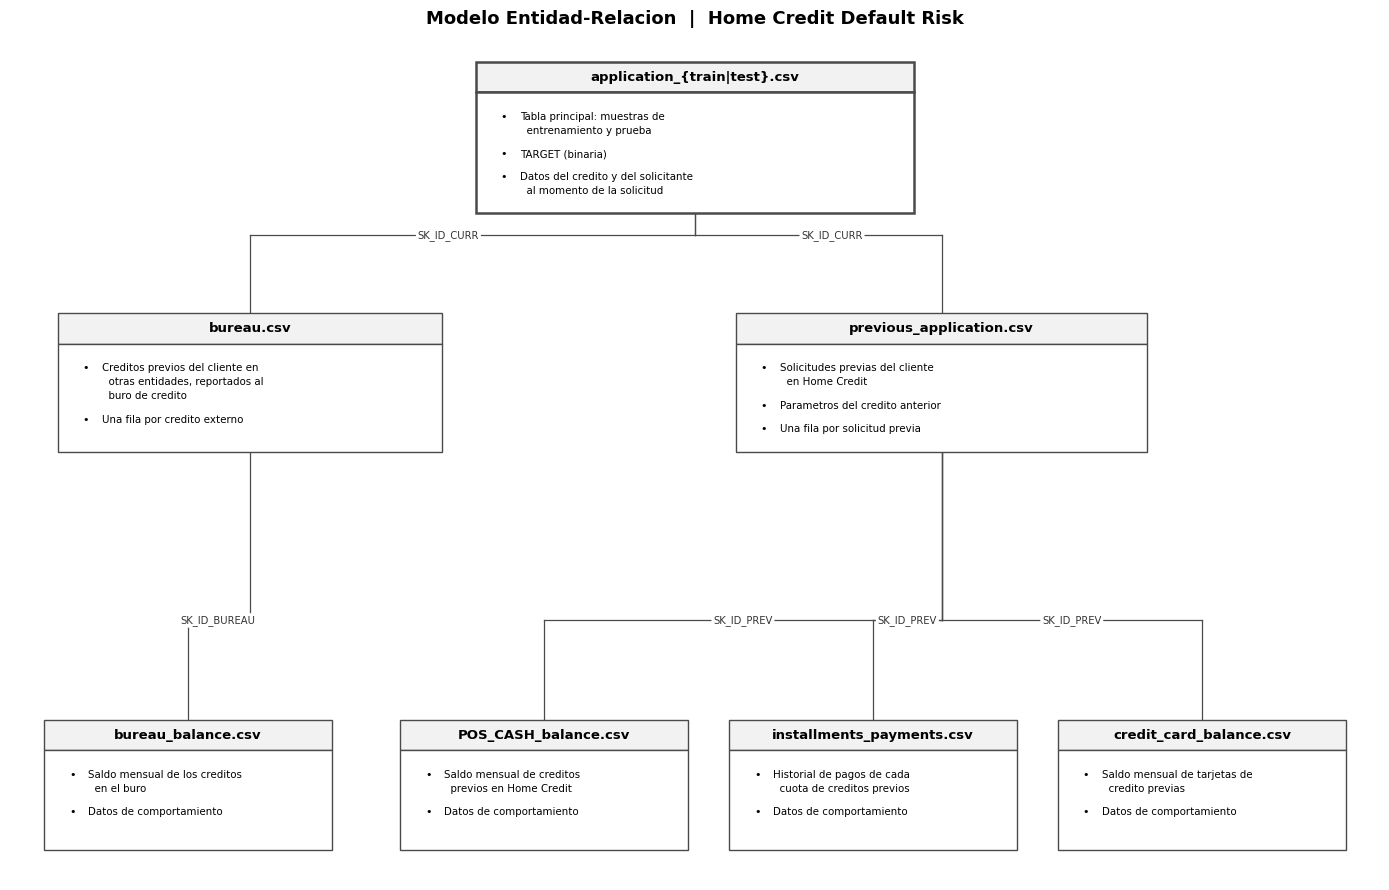

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(14, 9))

# clave: (x_centro, y_centro, ancho, alto, titulo, vinetas)
TABLAS = {
    'app':  (0.500, 0.888, 0.32, 0.175, 'application_{train|test}.csv',
             ['Tabla principal: muestras de\n  entrenamiento y prueba',
              'TARGET (binaria)',
              'Datos del credito y del solicitante\n  al momento de la solicitud']),
    'bur':  (0.175, 0.605, 0.28, 0.16, 'bureau.csv',
             ['Creditos previos del cliente en\n  otras entidades, reportados al\n  buro de credito',
              'Una fila por credito externo']),
    'prev': (0.680, 0.605, 0.30, 0.16, 'previous_application.csv',
             ['Solicitudes previas del cliente\n  en Home Credit',
              'Parametros del credito anterior',
              'Una fila por solicitud previa']),
    'bb':   (0.130, 0.140, 0.21, 0.15, 'bureau_balance.csv',
             ['Saldo mensual de los creditos\n  en el buro',
              'Datos de comportamiento']),
    'pos':  (0.390, 0.140, 0.21, 0.15, 'POS_CASH_balance.csv',
             ['Saldo mensual de creditos\n  previos en Home Credit',
              'Datos de comportamiento']),
    'ins':  (0.630, 0.140, 0.21, 0.15, 'installments_payments.csv',
             ['Historial de pagos de cada\n  cuota de creditos previos',
              'Datos de comportamiento']),
    'cc':   (0.870, 0.140, 0.21, 0.15, 'credit_card_balance.csv',
             ['Saldo mensual de tarjetas de\n  credito previas',
              'Datos de comportamiento']),
}

LINEA = '#4a4a4a'


def caja(clave, borde=1.0):
    x, y, w, h, titulo, vinetas = TABLAS[clave]
    ax.add_patch(mpatches.Rectangle((x - w/2, y + h/2 - 0.035), w, 0.035,
                                    facecolor='#f2f2f2', edgecolor=LINEA,
                                    linewidth=borde, zorder=2))
    ax.add_patch(mpatches.Rectangle((x - w/2, y - h/2), w, h - 0.035,
                                    facecolor='white', edgecolor=LINEA,
                                    linewidth=borde, zorder=2))
    ax.text(x, y + h/2 - 0.0175, titulo, fontsize=9.5, fontweight='bold',
            ha='center', va='center', zorder=3)

    cursor = y + h/2 - 0.058
    for v in vinetas:
        ax.text(x - w/2 + 0.018, cursor, '\u2022', fontsize=8,
                ha='left', va='top', zorder=3)
        ax.text(x - w/2 + 0.032, cursor, v, fontsize=7.4,
                ha='left', va='top', linespacing=1.45, zorder=3)
        cursor -= 0.0165 * (v.count('\n') + 1) + 0.010


def conector(desde, hacia, llave, y_bus, etiqueta_x):
    """Ruta ortogonal: baja del padre, corre horizontal, sube al hijo."""
    x1, y1, _, h1, _, _ = TABLAS[desde]
    x2, y2, _, h2, _, _ = TABLAS[hacia]
    ax.plot([x1, x1], [y1 - h1/2, y_bus], color=LINEA, lw=0.9, zorder=1)
    ax.plot([x1, x2], [y_bus, y_bus], color=LINEA, lw=0.9, zorder=1)
    ax.plot([x2, x2], [y_bus, y2 + h2/2], color=LINEA, lw=0.9, zorder=1)
    ax.text(etiqueta_x, y_bus, llave, fontsize=7.2, ha='center', va='center',
            color='#333333', zorder=4,
            bbox=dict(boxstyle='round,pad=0.18', fc='white', ec='none'))


conector('app', 'bur',  'SK_ID_CURR',   0.775, 0.320)
conector('app', 'prev', 'SK_ID_CURR',   0.775, 0.600)
conector('bur', 'bb',   'SK_ID_BUREAU', 0.330, 0.152)
conector('prev', 'pos', 'SK_ID_PREV',   0.330, 0.535)
conector('prev', 'ins', 'SK_ID_PREV',   0.330, 0.655)
conector('prev', 'cc',  'SK_ID_PREV',   0.330, 0.775)

for k in TABLAS:
    caja(k, borde=1.8 if k == 'app' else 1.0)

ax.set_xlim(0.0, 1.0)
ax.set_ylim(0.03, 1.0)
ax.axis('off')
ax.set_title('Modelo Entidad-Relacion  |  Home Credit Default Risk',
             fontsize=13, fontweight='bold', pad=12)

plt.tight_layout()
plt.savefig('modelo_entidad_relacion.png', dpi=170, bbox_inches='tight')
plt.show()

El conjunto de datos reproduce el esquema relacional de la base operativa de la entidad, organizado en siete tablas vinculadas mediante tres llaves: SK_ID_CURR, que identifica la solicitud actual; SK_ID_BUREAU, que identifica cada crédito registrado ante otras entidades; y SK_ID_PREV, que identifica cada solicitud previa ante Home Credit.

La tabla application ocupa la posición central del esquema y constituye la unidad de análisis, pues contiene un registro por solicitante y es la única que incorpora la variable objetivo. De ella se desprenden dos ramas de información histórica. La primera, conformada por bureau y bureau_balance, documenta el comportamiento crediticio del solicitante ante otras instituciones financieras. La segunda, integrada por previous_application y sus tres tablas derivadas, registra las solicitudes previas ante la propia entidad y el comportamiento de pago mensual asociado a cada una.

Todas las relaciones presentan cardinalidad uno a muchos con participación opcional en el extremo dependiente: un solicitante puede tener múltiples créditos externos registrados, o carecer por completo de ellos. Esta configuración es característica de un esquema normalizado, en el cual la información de naturaleza repetitiva se almacena en tablas independientes para evitar redundancia y grupos repetitivos.

# Carga de los Datos 

# Fase 1 del EDA

In [2]:
import os, glob
import numpy as np
import pandas as pd

pd.set_option('display.max_columns', 200)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

# --- localizacion del conjunto, sin rutas fijas de ninguna maquina ---------------
ARCHIVOS_HC = ['application_train.csv', 'application_test.csv', 'bureau.csv',
               'bureau_balance.csv', 'previous_application.csv',
               'installments_payments.csv', 'POS_CASH_balance.csv',
               'credit_card_balance.csv']


def _completitud(d):
    """Cuantos archivos del conjunto hay en `d`, contando solo ficheros legibles.

    Usa isfile y no exists: en este proyecto llego a existir un DIRECTORIO llamado
    `application_train.csv` que contenia dentro el csv, y `exists` lo daba por bueno
    hasta que `read_csv` fallaba con PermissionError al intentar abrir una carpeta.
    """
    if not d or not os.path.isdir(d):
        return 0
    return sum(os.path.isfile(os.path.join(d, a)) for a in ARCHIVOS_HC)



def _corta(p):
    """Ruta para mostrar sin datos de la maquina: solo las dos ultimas carpetas."""
    partes = [x for x in os.path.normpath(str(p)).split(os.sep) if x]
    return os.path.join('...', *partes[-2:])


def resolver_ruta(minimo=1, verboso=True):
    """Devuelve el directorio con mas archivos del conjunto, o None si no hay ninguno.

    Si HOME_CREDIT_DIR esta definida y apunta a una carpeta con el conjunto, se
    devuelve sin mas. En su defecto busca una RUTA ya definida en el entorno, el
    directorio de trabajo y hasta dos niveles por debajo de las ubicaciones
    habituales. Entre esos candidatos gana el mas completo, de modo que una carpeta
    con un solo csv suelto no desplaza a la que trae el conjunto entero.
    """
    bases = [os.getcwd(), os.path.expanduser('~'),
             os.path.join(os.path.expanduser('~'), 'Desktop'),
             os.path.join(os.path.expanduser('~'), 'OneDrive', 'Escritorio'),
             os.path.join(os.path.expanduser('~'), 'OneDrive', 'Desktop'),
             os.path.join(os.path.expanduser('~'), 'Documents'),
             os.path.join(os.path.expanduser('~'), 'Downloads')]

    # Una ruta indicada a mano manda sobre la busqueda. Antes HOME_CREDIT_DIR
    # entraba como un candidato mas y la puntuacion podia descartarla en favor de
    # otra copia igual de completa solo por tener la ruta mas corta, de modo que
    # definir la variable no servia para desempatar entre dos copias del conjunto.
    forzada = os.environ.get('HOME_CREDIT_DIR')
    if forzada and _completitud(forzada) >= minimo:
        forzada = os.path.abspath(forzada)
        if verboso:
            print(f'Conjunto tomado de HOME_CREDIT_DIR: {_corta(forzada)}')
            print(f'  archivos encontrados: {_completitud(forzada)} de {len(ARCHIVOS_HC)}')
        return forzada

    candidatos = [globals().get('RUTA')]
    for b in bases:
        for patron in ('', '*', os.path.join('*', '*')):
            candidatos += [os.path.dirname(p) for p in
                           glob.glob(os.path.join(b, patron, 'application_train.csv'))]
        candidatos.append(b)

    vistos, puntuados = set(), []
    for c in candidatos:
        c = os.path.abspath(c) if c else None
        if not c or c in vistos:
            continue
        vistos.add(c)
        n = _completitud(c)
        if n >= minimo:
            puntuados.append((n, c))

    if not puntuados:
        return None
    puntuados.sort(key=lambda t: (-t[0], len(t[1])))
    mejor = puntuados[0][1]
    if verboso:
        print(f'Conjunto localizado en: {_corta(mejor)}')
        print(f'  archivos encontrados: {puntuados[0][0]} de {len(ARCHIVOS_HC)}')
        for n, c in puntuados[1:4]:
            print(f'  (descartado, {n} archivos) {_corta(c)}')
    return mejor


RUTA = resolver_ruta()
if RUTA is None:
    raise FileNotFoundError(
        'No se encontro el conjunto. Descarguelo de Kaggle (home-credit-default-risk) '
        'y deje los .csv en una carpeta, o defina la variable de entorno '
        'HOME_CREDIT_DIR con su ruta.')

df = pd.read_csv(os.path.join(RUTA, 'application_train.csv'))


print('train:', df.shape)  



Conjunto localizado en: ...\PROYECTOS\Home-Credit
  archivos encontrados: 8 de 8


train: (307511, 122)


# Explracion Inicial 


## Naturaleza de los datos 

In [3]:
import pandas as pd

# `df` y `RUTA` vienen de la celda anterior; RUTA es la CARPETA del conjunto.



DEF = {
    'SK_ID_CURR': 'Identificador unico de la solicitud',
    'TARGET': 'Variable objetivo: 1 si tuvo dificultades de pago, 0 si no',
    'NAME_CONTRACT_TYPE': 'Tipo de credito: efectivo o revolvente',
    'CODE_GENDER': 'Genero del solicitante',
    'FLAG_OWN_CAR': 'Posee automovil',
    'FLAG_OWN_REALTY': 'Posee vivienda o terreno',
    'CNT_CHILDREN': 'Numero de hijos',
    'AMT_INCOME_TOTAL': 'Ingreso anual total',
    'AMT_CREDIT': 'Monto del credito solicitado',
    'AMT_ANNUITY': 'Cuota anual del credito',
    'AMT_GOODS_PRICE': 'Precio del bien financiado',
    'NAME_TYPE_SUITE': 'Acompanante en el tramite',
    'NAME_INCOME_TYPE': 'Fuente principal de ingresos',
    'NAME_EDUCATION_TYPE': 'Maximo nivel educativo',
    'NAME_FAMILY_STATUS': 'Estado civil',
    'NAME_HOUSING_TYPE': 'Tipo de vivienda que habita',
    'REGION_POPULATION_RELATIVE': 'Poblacion relativa de la region',
    'DAYS_BIRTH': 'Dias desde el nacimiento (negativos)',
    'DAYS_EMPLOYED': 'Dias desde el inicio del empleo (negativos)',
    'DAYS_REGISTRATION': 'Dias desde el ultimo cambio de registro',
    'DAYS_ID_PUBLISH': 'Dias desde la expedicion del documento',
    'OWN_CAR_AGE': 'Antiguedad del automovil en anos',
    'FLAG_MOBIL': 'Reporto telefono movil',
    'FLAG_EMP_PHONE': 'Reporto telefono laboral',
    'FLAG_WORK_PHONE': 'Reporto telefono de oficina',
    'FLAG_CONT_MOBILE': 'El telefono movil estaba disponible',
    'FLAG_PHONE': 'Reporto telefono fijo',
    'FLAG_EMAIL': 'Reporto correo electronico',
    'OCCUPATION_TYPE': 'Ocupacion del solicitante',
    'CNT_FAM_MEMBERS': 'Miembros del nucleo familiar',
    'REGION_RATING_CLIENT': 'Calificacion de la region (1 a 3)',
    'REGION_RATING_CLIENT_W_CITY': 'Calificacion de la region con ciudad (1 a 3)',
    'WEEKDAY_APPR_PROCESS_START': 'Dia de la semana de la solicitud',
    'HOUR_APPR_PROCESS_START': 'Hora de la solicitud',
    'REG_REGION_NOT_LIVE_REGION': 'Region de registro distinta a la de residencia',
    'REG_REGION_NOT_WORK_REGION': 'Region de registro distinta a la de trabajo',
    'LIVE_REGION_NOT_WORK_REGION': 'Region de residencia distinta a la de trabajo',
    'REG_CITY_NOT_LIVE_CITY': 'Ciudad de registro distinta a la de residencia',
    'REG_CITY_NOT_WORK_CITY': 'Ciudad de registro distinta a la de trabajo',
    'LIVE_CITY_NOT_WORK_CITY': 'Ciudad de residencia distinta a la de trabajo',
    'ORGANIZATION_TYPE': 'Tipo de organizacion donde labora',
    'EXT_SOURCE_1': 'Puntaje crediticio externo 1 (normalizado)',
    'EXT_SOURCE_2': 'Puntaje crediticio externo 2 (normalizado)',
    'EXT_SOURCE_3': 'Puntaje crediticio externo 3 (normalizado)',
    'FONDKAPREMONT_MODE': 'Regimen del fondo de mantenimiento',
    'HOUSETYPE_MODE': 'Tipo de edificacion',
    'TOTALAREA_MODE': 'Area total normalizada del inmueble',
    'WALLSMATERIAL_MODE': 'Material de los muros',
    'EMERGENCYSTATE_MODE': 'Inmueble en estado de emergencia',
    'OBS_30_CNT_SOCIAL_CIRCLE': 'Personas del entorno con mora a 30 dias',
    'DEF_30_CNT_SOCIAL_CIRCLE': 'Personas del entorno en incumplimiento a 30 dias',
    'OBS_60_CNT_SOCIAL_CIRCLE': 'Personas del entorno con mora a 60 dias',
    'DEF_60_CNT_SOCIAL_CIRCLE': 'Personas del entorno en incumplimiento a 60 dias',
    'DAYS_LAST_PHONE_CHANGE': 'Dias desde el ultimo cambio de telefono',
    'AMT_REQ_CREDIT_BUREAU_HOUR': 'Consultas al buro en la ultima hora',
    'AMT_REQ_CREDIT_BUREAU_DAY': 'Consultas al buro en el ultimo dia',
    'AMT_REQ_CREDIT_BUREAU_WEEK': 'Consultas al buro en la ultima semana',
    'AMT_REQ_CREDIT_BUREAU_MON': 'Consultas al buro en el ultimo mes',
    'AMT_REQ_CREDIT_BUREAU_QRT': 'Consultas al buro en el ultimo trimestre',
    'AMT_REQ_CREDIT_BUREAU_YEAR': 'Consultas al buro en el ultimo ano',
}

VIVIENDA = {
    'APARTMENTS': 'Tamano normalizado del apartamento',
    'BASEMENTAREA': 'Area normalizada del sotano',
    'YEARS_BEGINEXPLUATATION': 'Ano normalizado de inicio de habitabilidad',
    'YEARS_BUILD': 'Ano normalizado de construccion',
    'COMMONAREA': 'Area normalizada de zonas comunes',
    'ELEVATORS': 'Numero normalizado de ascensores',
    'ENTRANCES': 'Numero normalizado de entradas',
    'FLOORSMAX': 'Numero normalizado de pisos maximo',
    'FLOORSMIN': 'Numero normalizado de pisos minimo',
    'LANDAREA': 'Area normalizada del lote',
    'LIVINGAPARTMENTS': 'Numero normalizado de apartamentos habitables',
    'LIVINGAREA': 'Area habitable normalizada',
    'NONLIVINGAPARTMENTS': 'Numero normalizado de apartamentos no habitables',
    'NONLIVINGAREA': 'Area no habitable normalizada',
}

for base, texto in VIVIENDA.items():
    for suf, nom in [('AVG', 'promedio'), ('MODE', 'moda'), ('MEDI', 'mediana')]:
        DEF[f'{base}_{suf}'] = f'{texto} ({nom})'

for i in range(2, 22):
    DEF[f'FLAG_DOCUMENT_{i}'] = f'Aporto el documento numero {i}'


ORDINALES = {'NAME_EDUCATION_TYPE', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY'}
INTERVALO = {'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH',
             'DAYS_LAST_PHONE_CHANGE', 'HOUR_APPR_PROCESS_START'}


def clasificar(s, nombre):
    n = s.nunique(dropna=True)

    if nombre == 'SK_ID_CURR':
        return 'Identificador', 'Nominal'

    if not pd.api.types.is_numeric_dtype(s):
        if nombre in ORDINALES:
            return 'Categorica ordinal', 'Ordinal'
        if nombre == 'WEEKDAY_APPR_PROCESS_START':
            return 'Temporal', 'Nominal'
        return ('Categorica binaria' if n == 2 else 'Categorica nominal'), 'Nominal'

    if n == 2 and set(s.dropna().unique()) <= {0, 1}:
        return 'Categorica binaria', 'Nominal'
    if nombre in ORDINALES:
        return 'Categorica ordinal', 'Ordinal'
    if nombre in INTERVALO:
        return 'Temporal', 'Intervalo'
    if pd.api.types.is_integer_dtype(s) or n < 30:
        return 'Numerica discreta', 'Razon'
    return 'Numerica continua', 'Razon'


filas = []
for col in df.columns:
    tipo, escala = clasificar(df[col], col)
    filas.append({
        'Variable': col,
        'Tipo': tipo,
        'Definicion': DEF.get(col, 'Sin descripcion'),
        'Escala_de_Medicion': escala,
        
    })

tabla = pd.DataFrame(filas)
tabla.to_csv('tabla_variables.csv', index=False, encoding='utf-8')
print(tabla.to_string(index=False))

                    Variable               Tipo                                                  Definicion Escala_de_Medicion
                  SK_ID_CURR      Identificador                         Identificador unico de la solicitud            Nominal
                      TARGET Categorica binaria  Variable objetivo: 1 si tuvo dificultades de pago, 0 si no            Nominal
          NAME_CONTRACT_TYPE Categorica binaria                      Tipo de credito: efectivo o revolvente            Nominal
                 CODE_GENDER Categorica nominal                                      Genero del solicitante            Nominal
                FLAG_OWN_CAR Categorica binaria                                             Posee automovil            Nominal
             FLAG_OWN_REALTY Categorica binaria                                    Posee vivienda o terreno            Nominal
                CNT_CHILDREN  Numerica discreta                                             Numero de hijos    

In [4]:
df.info()
df.shape
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,"202,500.00","406,597.50","24,700.50","351,000.00",Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.02,-9461,-637,"-3,648.00",-2120,NaN,1,1,0,1,1,0,Laborers,1.00,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.08,0.26,0.14,0.02,0.04,0.97,0.62,0.01,0.00,0.07,0.08,0.12,0.04,0.02,0.02,0.00,0.00,0.03,0.04,0.97,0.63,0.01,0.00,0.07,0.08,0.12,0.04,0.02,0.02,0.00,0.00,0.03,0.04,0.97,0.62,0.01,0.00,0.07,0.08,0.12,0.04,0.02,0.02,0.00,0.00,reg oper account,block of flats,0.01,"Stone, brick",No,2.00,2.00,2.00,2.00,"-1,134.00",0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00,0.00,0.00,0.00,0.00,1.00
1,100003,0,Cash loans,F,N,N,0,"270,000.00","1,293,502.50","35,698.50","1,129,500.00",Family,State servant,Higher education,Married,House / apartment,0.00,-16765,-1188,"-1,186.00",-291,NaN,1,1,0,1,1,0,Core staff,2.00,1,1,MONDAY,11,0,0,0,0,0,0,School,0.31,0.62,NaN,0.10,0.05,0.99,0.80,0.06,0.08,0.03,0.29,0.33,0.01,0.08,0.05,0.00,0.01,0.09,0.05,0.99,0.80,0.05,0.08,0.03,0.29,0.33,0.01,0.08,0.06,0.00,0.00,0.10,0.05,0.99,0.80,0.06,0.08,0.03,0.29,0.33,0.01,0.08,0.06,0.00,0.01,reg oper account,block of flats,0.07,Block,No,1.00,0.00,1.00,0.00,-828.00,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00,0.00,0.00,0.00,0.00,0.00
2,100004,0,Revolving loans,M,Y,Y,0,"67,500.00","135,000.00","6,750.00","135,000.00",Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.01,-19046,-225,"-4,260.00",-2531,26.00,1,1,1,1,1,0,Laborers,1.00,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.56,0.73,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0.00,0.00,0.00,-815.00,0,0

El conjunto application_train está compuesto por 307,511 observaciones y 122 variables, donde cada fila corresponde a una solicitud de crédito individual identificada de forma única por SK_ID_CURR. La estructura de tipos revela 106 variables numéricas —65 en punto flotante y 41 enteras— frente a 16 variables de tipo texto, lo que indica un predominio de información cuantitativa. No obstante, esta proporción sobreestima la cantidad real de variables continuas, dado que numerosos campos enteros corresponden a indicadores binarios codificados como 0 y 1 (por ejemplo, la familia FLAG_DOCUMENT_*), los cuales son categóricos en su naturaleza estadística pese a su almacenamiento numérico.

## Verificaciones previas

Antes de intervenir los datos conviene comprobar tres supuestos que el resto del análisis
da por sentados: que cada fila sea una solicitud distinta, en qué proporción aparece la
clase que se quiere predecir, y qué forma tienen las variables continuas.

In [5]:
# --- Integridad de la unidad de analisis
print(f'Filas: {len(df):,}  |  SK_ID_CURR unicos: {df["SK_ID_CURR"].nunique():,}  |  '
      f'Filas duplicadas: {df.duplicated().sum()}')

# --- Distribucion de la variable objetivo
conteo = df['TARGET'].value_counts().sort_index()
print(f'\nTARGET = 0 (cumple)   : {conteo[0]:,}')
print(f'TARGET = 1 (incumple) : {conteo[1]:,}')
print(f'Positivos: {100 * df["TARGET"].mean():.2f}%  |  Razon de clases: {conteo[0] / conteo[1]:.1f} a 1')

# --- Descriptivos de las continuas, sin repetir el mismo atributo tres veces
continuas = list(tabla.loc[tabla['Tipo'] == 'Numerica continua', 'Variable'])
sel = [c for c in continuas
       if not (c.endswith(('_MODE', '_MEDI')) and c.rsplit('_', 1)[0] + '_AVG' in continuas)]

desc = df[sel].describe().T[['mean', '50%', 'std', 'min', 'max']]
desc['asimetria'] = df[sel].skew()
print(f'\n{len(continuas)} variables continuas -> {len(sel)} tras excluir moda y mediana '
      f'del bloque de vivienda\n')
print(desc.to_string(float_format=lambda v: f'{v:,.2f}'))

# --- Valores extremos en las variables monetarias
mon = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE']
ext = df[mon].agg(['median', 'max']).T
ext['max_sobre_mediana'] = ext['max'] / ext['median']
ext['asimetria'] = df[mon].skew()
print('\n', ext.to_string(float_format=lambda v: f'{v:,.1f}'))

Filas: 307,511  |  SK_ID_CURR unicos: 307,511  |  Filas duplicadas: 0

TARGET = 0 (cumple)   : 282,686
TARGET = 1 (incumple) : 24,825
Positivos: 8.07%  |  Razon de clases: 11.4 a 1



51 variables continuas -> 26 tras excluir moda y mediana del bloque de vivienda

                                  mean        50%        std       min            max  asimetria
AMT_INCOME_TOTAL            168,797.92 147,150.00 237,123.15 25,650.00 117,000,000.00     391.56
AMT_CREDIT                  599,026.00 513,531.00 402,490.78 45,000.00   4,050,000.00       1.23
AMT_ANNUITY                  27,108.57  24,903.00  14,493.74  1,615.50     258,025.50       1.58
AMT_GOODS_PRICE             538,396.21 450,000.00 369,446.46 40,500.00   4,050,000.00       1.35
REGION_POPULATION_RELATIVE        0.02       0.02       0.01      0.00           0.07       1.49
OWN_CAR_AGE                      12.06       9.00      11.94      0.00          91.00       2.75
EXT_SOURCE_1                      0.50       0.51       0.21      0.01           0.96      -0.07
EXT_SOURCE_2                      0.51       0.57       0.19      0.00           0.85      -0.79
EXT_SOURCE_3                      0.51       

**Cada fila es una solicitud distinta.** Hay 307,511 registros y 307,511 valores distintos
de SK_ID_CURR, sin filas repetidas. El supuesto sobre el que descansa toda la lectura de
los datos queda comprobado.

**El desbalance es de 11.4 a 1.** Solo el 8.07% de las solicitudes terminó en dificultades
de pago. Con esa proporción, un modelo que responda siempre "cumple" acierta el 91.93% de
las veces sin haber aprendido nada. Por eso la evaluación se hace con AUC-ROC y no con el
porcentaje de aciertos: lo que interesa medir es la capacidad de ordenar a los solicitantes
por riesgo, no la de acertar la clase mayoritaria.

**Los ingresos tienen valores extremos severos.** AMT_INCOME_TOTAL alcanza 117,000,000
frente a una mediana de 147,150, es decir, un máximo 795 veces mayor que el valor central,
con una asimetría de 391.6. Las otras tres variables monetarias son mucho más regulares:
ninguna supera un máximo veinte veces su mediana. Este contraste es el que justifica
imputar con la mediana y no con la media, decisión que se toma más adelante. La media de
una variable así queda arrastrada por unos pocos registros y dejaría de representar al
solicitante típico.

Sobre la tabla de descriptivos: de las 51 variables clasificadas como continuas, 40
pertenecen al bloque de vivienda, donde un mismo atributo aparece medido en promedio, moda
y mediana. Describirlas todas sería repetir cada descripción tres veces, de modo que la
tabla conserva un solo estadístico por atributo y se reduce a 26 filas.

# Datos Faltantes 

In [6]:
import pandas as pd, numpy as np
from scipy.stats import chi2_contingency

def tabla_faltantes(df):
    t = pd.concat([df.isnull().sum(), 100*df.isnull().mean()], axis=1)
    t.columns = ['Faltantes', 'Pct']
    return t[t.Faltantes > 0].sort_values('Pct', ascending=False).round(2)

print(tabla_faltantes(df).head(30))

# Valor centinela: 365243 días ≈ 1000 años en el futuro
anom = df['DAYS_EMPLOYED'] == 365243
print(f'{anom.sum():,} registros ({100*anom.mean():.2f}%) | '
      f'mora: {100*df.loc[anom,"TARGET"].mean():.2f}% vs '
      f'{100*df.loc[~anom,"TARGET"].mean():.2f}%')

# Las dos columnas se escriben de una vez y se compacta el marco. Insertarlas
# por separado deja `df` fragmentado y pandas avisa en cada celda posterior que
# lo recorra, llenando de PerformanceWarning una salida que hay que poder leer.
df = df.copy()          # compacta antes de escribir: evita PerformanceWarning
df = df.assign(
    DAYS_EMPLOYED_ANOM=anom.astype(int),
    DAYS_EMPLOYED=df['DAYS_EMPLOYED'].replace(365243, np.nan),
)

                          Faltantes   Pct
COMMONAREA_MEDI              214865 69.87
COMMONAREA_MODE              214865 69.87
COMMONAREA_AVG               214865 69.87
NONLIVINGAPARTMENTS_MODE     213514 69.43
NONLIVINGAPARTMENTS_MEDI     213514 69.43
NONLIVINGAPARTMENTS_AVG      213514 69.43
FONDKAPREMONT_MODE           210295 68.39
LIVINGAPARTMENTS_AVG         210199 68.35
LIVINGAPARTMENTS_MEDI        210199 68.35
LIVINGAPARTMENTS_MODE        210199 68.35
FLOORSMIN_MEDI               208642 67.85
FLOORSMIN_MODE               208642 67.85
FLOORSMIN_AVG                208642 67.85
YEARS_BUILD_MODE             204488 66.50
YEARS_BUILD_MEDI             204488 66.50
YEARS_BUILD_AVG              204488 66.50
OWN_CAR_AGE                  202929 65.99
LANDAREA_AVG                 182590 59.38
LANDAREA_MEDI                182590 59.38
LANDAREA_MODE                182590 59.38
BASEMENTAREA_MODE            179943 58.52
BASEMENTAREA_MEDI            179943 58.52
BASEMENTAREA_AVG             17994

De las 122 variables, 68 presentan faltantes (55.7%). Su distribución no es uniforme: las primeras veintitrés posiciones corresponden al bloque de características de vivienda, con ausencias entre 47% y 70%, agrupamiento que constituye el primer indicio de un mecanismo no aleatorio. Adicionalmente, la variable DAYS_EMPLOYED codifica la ausencia mediante el valor 365243 en 55,374 registros (18.01%), no detectable por conteo convencional de nulos. Dado que dicho subgrupo presenta una tasa de incumplimiento de 5.40% frente a 8.66% en el resto, se genera una variable indicadora antes de convertir el valor a nulo, preservando la señal antes de eliminar el dato inconsistente.

In [7]:
filas = []
for c in df.columns[df.isnull().any()]:
    falta = df[c].isnull()
    chi2, p, _, _ = chi2_contingency(pd.crosstab(falta, df['TARGET']))
    m_si, m_no = 100*df.loc[falta,'TARGET'].mean(), 100*df.loc[~falta,'TARGET'].mean()
    filas.append({'Variable': c, 'Pct_nulos': round(100*falta.mean(), 2),
                  'Mora_falta': round(m_si, 2), 'Mora_no_falta': round(m_no, 2),
                  'Brecha_pp': round(m_si-m_no, 2), 'p_valor': p})

diag = pd.DataFrame(filas)
diag['Informativa'] = np.where((diag.p_valor < 0.05) & (diag.Brecha_pp.abs() >= 0.5), 'Si', 'No')
print(diag.sort_values('Brecha_pp', key=abs, ascending=False).head(15).to_string(index=False))
print(diag.Informativa.value_counts().to_string())

# Ausencia estructural
print(pd.crosstab(df['FLAG_OWN_CAR'], df['OWN_CAR_AGE'].isnull()))

                  Variable  Pct_nulos  Mora_falta  Mora_no_falta  Brecha_pp  p_valor Informativa
               AMT_ANNUITY       0.00        0.00           8.07      -8.07     0.62          No
           CNT_FAM_MEMBERS       0.00        0.00           8.07      -8.07     1.00          No
    DAYS_LAST_PHONE_CHANGE       0.00        0.00           8.07      -8.07     1.00          No
  OBS_60_CNT_SOCIAL_CIRCLE       0.33        3.53           8.09      -4.56     0.00          Si
  OBS_30_CNT_SOCIAL_CIRCLE       0.33        3.53           8.09      -4.56     0.00          Si
  DEF_60_CNT_SOCIAL_CIRCLE       0.33        3.53           8.09      -4.56     0.00          Si
  DEF_30_CNT_SOCIAL_CIRCLE       0.33        3.53           8.09      -4.56     0.00          Si
             DAYS_EMPLOYED      18.01        5.40           8.66      -3.26     0.00          Si
           NAME_TYPE_SUITE       0.42        5.42           8.08      -2.67     0.00          Si
 AMT_REQ_CREDIT_BUREAU_DAY    

La prueba chi-cuadrado arroja asociación significativa entre el patrón de ausencia y la variable objetivo en 63 de las 68 variables evaluadas; los cinco casos restantes poseen menos de doce registros faltantes, tamaño insuficiente para detectar asociación. Las magnitudes resultan sustantivas frente a una tasa base de 8.07%: el bloque de vivienda registra 9.23% de incumplimiento entre observaciones sin dato frente a 6.99% entre las que lo poseen, incremento de 32% en riesgo relativo; OCCUPATION_TYPE presenta el patrón inverso con 6.51% frente a 8.79%; y las consultas al buró alcanzan 10.34% frente a 7.72%. Dado que con 307,511 observaciones la significancia se alcanza ante diferencias reducidas, el criterio de clasificación incorpora un umbral mínimo de 0.5 puntos porcentuales, privilegiando la relevancia sustantiva sobre la formal.

Estos resultados sustentan un mecanismo MNAR (Rubin, 1976), bajo el cual la probabilidad de no observación depende del valor no registrado, y toda imputación basada en las variables observadas introduce sesgo sistemático por carecer estas de la información requerida para la reconstrucción.

La tabla de contingencia evidencia además un caso distinto: la totalidad de los 202,929 faltantes de OWN_CAR_AGE corresponde a solicitantes que declaran no poseer automóvil, sin excepciones. Se trata de ausencia estructural, donde el valor no se encuentra perdido sino que carece de existencia, y cuya imputación resultaría conceptualmente inválida.

In [8]:
# Etapa 1 — preservar la señal de la ausencia
#
# Las seis indicadoras se crean de una vez con `concat`. Insertarlas una a una
# sobre un marco de ~250 columnas lo deja fragmentado, y pandas emite entonces un
# PerformanceWarning en cada operacion posterior: decenas de avisos que tapan la
# salida que en realidad hay que leer.
_indicadoras = {
    'SIN_DATOS_VIVIENDA': df['COMMONAREA_AVG'].isnull().astype(int),
    'SIN_REGISTRO_BURO': df['AMT_REQ_CREDIT_BUREAU_YEAR'].isnull().astype(int),
    'SIN_AUTOMOVIL': df['OWN_CAR_AGE'].isnull().astype(int),
}
for c in ['EXT_SOURCE_1', 'EXT_SOURCE_3', 'OCCUPATION_TYPE']:
    _indicadoras[f'{c}_AUSENTE'] = df[c].isnull().astype(int)
df = pd.concat([df, pd.DataFrame(_indicadoras, index=df.index)], axis=1).copy()

# Etapa 2 — imputación diferenciada
cat = df.select_dtypes(exclude='number').columns
df[cat] = df[cat].fillna('Desconocido')

cero = [c for c in df.columns if c.startswith('AMT_REQ_CREDIT_BUREAU')] + \
       ['OBS_30_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE',
        'OBS_60_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE']
df[cero] = df[cero].fillna(0)

num = df.select_dtypes('number').columns
df[num] = df[num].fillna(df[num].median())

print(f'Faltantes remanentes: {df.isnull().sum().sum()}')

Faltantes remanentes: 0


La primera etapa genera siete variables indicadoras que codifican la condición de no observación en aquellas variables cuyo patrón demostró asociación con el objetivo. Este procedimiento, denominado método del indicador de ausencia, incorpora la información contenida en el hecho de no observar como atributo adicional en lugar de perderla durante la sustitución. En el bloque de vivienda basta un único indicador, dado que sus 47 variables corresponden a catorce atributos medidos en tres estadísticos y sus patrones de ausencia coinciden: la carencia afecta al bloque completo y no a variables aisladas.

La segunda etapa imputa según la naturaleza de cada variable. Las cualitativas reciben la categoría 'Desconocido', puesto que los procedimientos de codificación descartan los nulos de manera silenciosa. Las consultas al buró y el círculo social se imputan con cero, valor de interpretación sustantiva inequívoca en ambos casos. Las restantes numéricas se imputan mediante la mediana, preferida sobre la media por su robustez ante los valores extremos documentados en variables como AMT_INCOME_TOTAL. El conjunto resultante carece de valores faltantes, condición necesaria para procedimientos de modelado que no admiten datos incompletos.

In [9]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

pipeline = Pipeline([
    ('imputador', SimpleImputer(strategy='median', add_indicator=True)),
    ('escalador', StandardScaler()),
])

Calcular la mediana sobre la totalidad del conjunto constituye filtración de información, dado que el estadístico incorpora observaciones destinadas a la evaluación del modelo. Aunque el efecto resulta despreciable en variables con menos del 1% de faltantes, el procedimiento correcto ajusta el imputador exclusivamente sobre los datos de entrenamiento de cada partición. La implementación mediante pipeline garantiza esta condición por construcción, y el parámetro add_indicator reproduce automáticamente la generación de indicadores descrita anteriormente.

## Tipos de columnas

La estrategia de preparación depende del tipo de cada variable y, en las cualitativas,
del número de categorías que admite. Se examina la composición del conjunto tras el
tratamiento de faltantes de la fase anterior.

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt


def densidad(serie, ax, etiqueta, color, n=25000):
    """KDE sobre submuestra: el estimador converge muy por debajo de los 307k puntos."""
    s = serie.sample(n, random_state=0) if len(serie) > n else serie
    sns.kdeplot(s, ax=ax, label=etiqueta, color=color, fill=True, alpha=.25)


print(df.dtypes.value_counts().to_string(), '\n')

obj = df.select_dtypes(include=['object', 'string'])
print(f'{obj.shape[1]} variables categoricas | {obj.nunique().sum()} categorias en total\n')
print(obj.nunique().sort_values(ascending=False).to_string())

float64    66
int64      47
object     16 



16 variables categoricas | 146 categorias en total



ORGANIZATION_TYPE             58
OCCUPATION_TYPE               19
NAME_INCOME_TYPE               8
NAME_TYPE_SUITE                8
WALLSMATERIAL_MODE             8
WEEKDAY_APPR_PROCESS_START     7
NAME_FAMILY_STATUS             6
NAME_HOUSING_TYPE              6
NAME_EDUCATION_TYPE            5
FONDKAPREMONT_MODE             5
HOUSETYPE_MODE                 4
CODE_GENDER                    3
EMERGENCYSTATE_MODE            3
FLAG_OWN_CAR                   2
FLAG_OWN_REALTY                2
NAME_CONTRACT_TYPE             2


Las 129 columnas actuales corresponden a las 122 originales más las siete indicadoras de
ausencia construidas en la fase anterior. Las dieciséis variables cualitativas concentran
146 categorías, con una distribución marcadamente asimétrica: ORGANIZATION_TYPE aporta 58
niveles y OCCUPATION_TYPE 19, mientras que las catorce restantes no superan ocho. Seis de
ellas incorporan además el nivel 'Desconocido' introducido durante la imputación, que
mantiene la condición de no observación como categoría explícita.

Esta asimetría es determinante: una variable de 58 niveles genera, bajo codificación
indicadora, 58 columnas nuevas, de modo que la cardinalidad gobierna el crecimiento
dimensional del conjunto.

## Codificación de variables categóricas

Los algoritmos de aprendizaje operan sobre representaciones numéricas, por lo que las
variables cualitativas requieren codificación previa. Se aplica el criterio estándar:
codificación por etiqueta cuando la variable posee dos niveles y codificación indicadora
(*one-hot*) cuando posee más de dos.

In [11]:
import gc
from sklearn.preprocessing import LabelEncoder

df_cod = df.copy()
# select_dtypes('object') esta deprecado: hoy arrastra las columnas de dtype `str`
# solo por compatibilidad, y cuando esa compatibilidad desaparezca devolvera una
# seleccion vacia y `binarias` quedara vacia sin avisar. Se nombran los dos dtypes.
cualitativas = list(df_cod.select_dtypes(include=['object', 'string']).columns)
binarias = [c for c in cualitativas if df_cod[c].nunique() == 2]
for c in binarias:
    df_cod[c] = LabelEncoder().fit_transform(df_cod[c])

# dtype='int8' y no int: las indicadoras solo guardan 0 o 1, y en int64 gastan
# ocho bytes por celda. Sobre 307,511 filas son 176 MB contra 22 MB, y era la
# asignacion que abortaba la celda con MemoryError.
df_cod = pd.get_dummies(df_cod, dtype='int8')
gc.collect()

print('Por etiqueta   :', binarias)
# se contaba con `obj`, definido en otra celda: la celda no se sostenia sola
print('Por indicadoras:', len(cualitativas) - len(binarias), 'variables')
print(f'Dimension      : {df.shape[1]} -> {df_cod.shape[1]} columnas')

Por etiqueta   : ['NAME_CONTRACT_TYPE', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY']
Por indicadoras: 13 variables
Dimension      : 129 -> 256 columnas


La codificación por etiqueta asigna un entero a cada nivel sin crear columnas, pero impone
un orden arbitrario que el modelo puede interpretar como magnitud. Con dos niveles el
problema desaparece, pues cualquier asignación es equivalente a un indicador 0/1; con más
de dos el orden resulta espurio y se prefiere la codificación indicadora, que representa
cada nivel en una columna propia sin imponer relación ordinal alguna. El costo es
dimensional: el conjunto pasa de 129 a 256 columnas, casi el doble.

Una precisión operativa: al aplicar este procedimiento por separado sobre entrenamiento y
prueba, las categorías presentes en una partición y ausentes en la otra producen conjuntos
con columnas distintas. La práctica correcta consiste en alinear ambas tablas conservando
únicamente las columnas comunes, o en ajustar el codificador sobre el entrenamiento y
aplicarlo a la prueba. Aquí solo se dispone de application_train, por lo que la
consideración queda registrada para la etapa de modelado.

## Anomalías en las variables temporales

Las variables DAYS_* registran días transcurridos hasta la solicitud, expresados como
valores negativos. Conviene verificar que sus rangos sean plausibles una vez corregido el
centinela 365243 detectado en la fase anterior.

       Edad (anos)  Antiguedad (anos)
count    307,511.0          252,137.0
mean          43.9                6.5
std           12.0                6.4
min           20.5               -0.0
25%           34.0                2.1
50%           43.2                4.5
75%           53.9                8.7
max           69.1               49.1


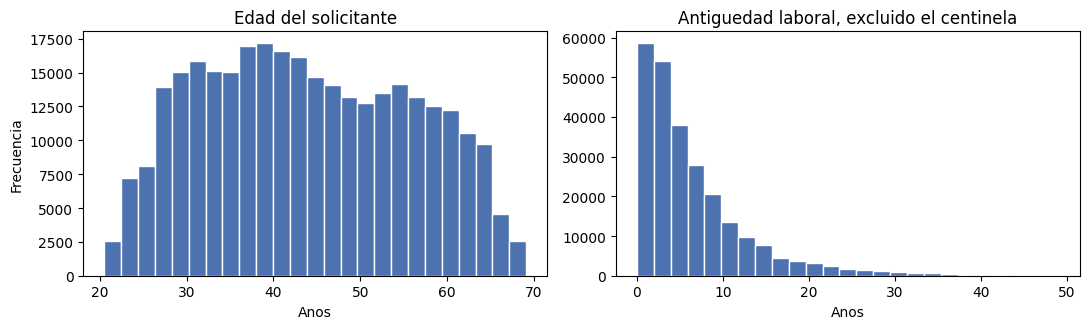

In [12]:
edad = -df['DAYS_BIRTH'] / 365
antig = -df.loc[df['DAYS_EMPLOYED_ANOM'] == 0, 'DAYS_EMPLOYED'] / 365

print(pd.concat([edad.describe(), antig.describe()], axis=1,
                keys=['Edad (anos)', 'Antiguedad (anos)']).to_string(float_format=lambda v: f'{v:,.1f}'))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].hist(edad, bins=25, color='#4c72b0', edgecolor='white')
ax[0].set(title='Edad del solicitante', xlabel='Anos', ylabel='Frecuencia')
ax[1].hist(antig, bins=25, color='#4c72b0', edgecolor='white')
ax[1].set(title='Antiguedad laboral, excluido el centinela', xlabel='Anos')
plt.tight_layout()
plt.show()

La edad recorre el intervalo de 20.5 a 69.1 años con media 43.9, rango íntegramente
plausible y sin valores extremos en ninguno de los dos extremos. La antigüedad laboral,
una vez excluido el centinela, se distribuye entre 0 y 49.1 años con mediana de 4.5, forma
fuertemente asimétrica a la derecha característica de esta clase de variable. Corregida la
única anomalía documentada, las restantes variables temporales no presentan valores
incompatibles con su definición.

## Correlaciones con la variable objetivo

El coeficiente de Pearson entre cada variable y TARGET ofrece una primera aproximación a
la estructura de asociación. Su lectura convencional califica de muy débil el intervalo
0.00–0.19, débil el 0.20–0.39 y moderado el 0.40–0.59.

In [13]:
r = df_cod.corr(numeric_only=True)['TARGET'].drop('TARGET').sort_values()
fmt = lambda v: f'{v:+.3f}'

print('MAS NEGATIVAS\n', r.head(10).to_string(float_format=fmt))
print('\nMAS POSITIVAS\n', r.tail(10).to_string(float_format=fmt))
print(f'\n|r| > 0.05 en {(r.abs() > 0.05).sum()} de {len(r)} variables')

MAS NEGATIVAS
 EXT_SOURCE_2                           -0.160
EXT_SOURCE_3                           -0.156
EXT_SOURCE_1                           -0.099
NAME_EDUCATION_TYPE_Higher education   -0.057
CODE_GENDER_F                          -0.055
NAME_INCOME_TYPE_Pensioner             -0.046
DAYS_EMPLOYED_ANOM                     -0.046
ORGANIZATION_TYPE_XNA                  -0.046
EMERGENCYSTATE_MODE_No                 -0.042
HOUSETYPE_MODE_block of flats          -0.041

MAS POSITIVAS
 NAME_EDUCATION_TYPE_Secondary / secondary special   +0.050
REG_CITY_NOT_WORK_CITY                              +0.051
DAYS_ID_PUBLISH                                     +0.051
CODE_GENDER_M                                       +0.055
DAYS_LAST_PHONE_CHANGE                              +0.055
NAME_INCOME_TYPE_Working                            +0.057
REGION_RATING_CLIENT                                +0.059
REGION_RATING_CLIENT_W_CITY                         +0.061
DAYS_EMPLOYED                        

Ninguna variable supera 0.16 en valor absoluto y solo catorce de 255 exceden 0.05: no
existe un predictor individual dominante y la capacidad discriminante deberá construirse
por combinación de señales débiles, situación habitual en riesgo crediticio.

Las asociaciones negativas más intensas corresponden a las tres calificaciones externas
EXT_SOURCE, seguidas de la educación superior y del género femenino. Entre las positivas
destaca DAYS_BIRTH con +0.078; dado que la variable se expresa en días negativos, el signo
positivo indica que los solicitantes de menor edad —cuyo valor es menos negativo, es decir
mayor— incumplen con mayor frecuencia. Aparecen también la calificación de la región, la
condición de trabajador activo y las discrepancias entre ciudad de registro y de
residencia. Debe recordarse que el coeficiente solo captura asociación lineal y que una
correlación nula no descarta dependencia de otra forma funcional.

## Efecto de la edad sobre el cumplimiento

La edad es la variable no derivada con mayor correlación positiva. Se examina su
distribución condicionada a TARGET y la tasa de incumplimiento por tramos quinquenales.

r(edad, TARGET) = -0.078


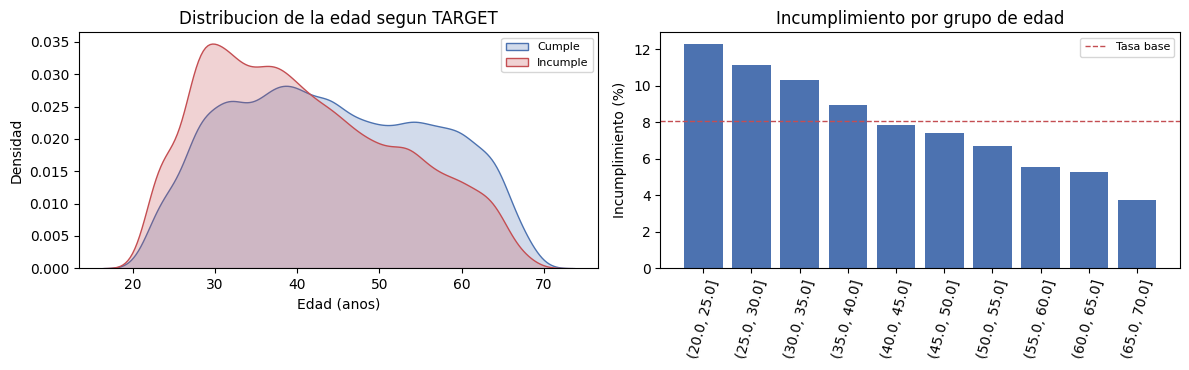

DAYS_BIRTH
(20.0, 25.0]   12.30
(25.0, 30.0]   11.14
(30.0, 35.0]   10.28
(35.0, 40.0]    8.94
(40.0, 45.0]    7.85
(45.0, 50.0]    7.42
(50.0, 55.0]    6.70
(55.0, 60.0]    5.53
(60.0, 65.0]    5.27
(65.0, 70.0]    3.73


In [14]:
grupos = pd.cut(edad, bins=np.linspace(20, 70, 11))
tasa = 100 * df.groupby(grupos, observed=True)['TARGET'].mean()
print(f'r(edad, TARGET) = {edad.corr(df["TARGET"]):+.3f}')

fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
for t, lab, c in [(0, 'Cumple', '#4c72b0'), (1, 'Incumple', '#c44e52')]:
    densidad(edad[df['TARGET'] == t], ax[0], lab, c)
ax[0].set(title='Distribucion de la edad segun TARGET', xlabel='Edad (anos)', ylabel='Densidad')
ax[0].legend(fontsize=8)

ax[1].bar(tasa.index.astype(str), tasa.values, color='#4c72b0')
ax[1].axhline(100 * df['TARGET'].mean(), ls='--', lw=1, color='#c44e52', label='Tasa base')
ax[1].set(title='Incumplimiento por grupo de edad', ylabel='Incumplimiento (%)')
ax[1].tick_params(axis='x', rotation=75)
ax[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

print(tasa.to_string(float_format=lambda v: f'{v:.2f}'))

La densidad de los incumplidores se desplaza de forma sistemática hacia el extremo joven de
la distribución. Agrupada en tramos de cinco años, la relación resulta monótona sin una
sola inversión: la tasa desciende desde 12.30% en el grupo de 20 a 25 años hasta 3.73% en
el de 65 a 70, frente a una tasa base de 8.07%. El solicitante más joven presenta así un
riesgo más de tres veces superior al del más longevo.

El contraste entre esta regularidad y un coeficiente de apenas −0.078 ilustra la limitación
señalada: la relación es fuerte y ordenada en términos de tasa condicional, pero el
coeficiente de Pearson la subestima porque la mide sobre una variable binaria de clase
minoritaria. Una variable con correlación lineal débil puede resultar informativa para el
modelo.

## Fuentes externas de calificación

Las variables EXT_SOURCE_1, EXT_SOURCE_2 y EXT_SOURCE_3 son puntajes normalizados
provenientes de terceros y encabezan el orden de correlación negativa. Dado que la primera
y la tercera fueron imputadas en 56.4% y 19.8% de los registros, se contrastan sus
correlaciones sobre valores efectivamente observados frente a las obtenidas tras la
imputación.

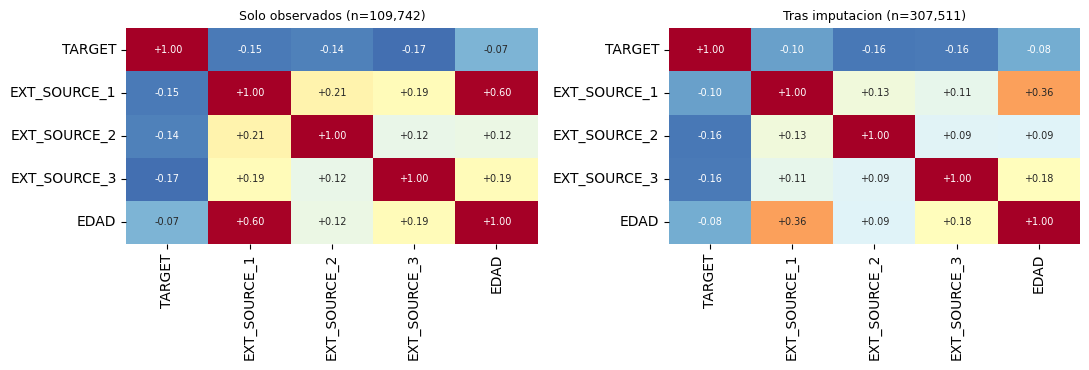

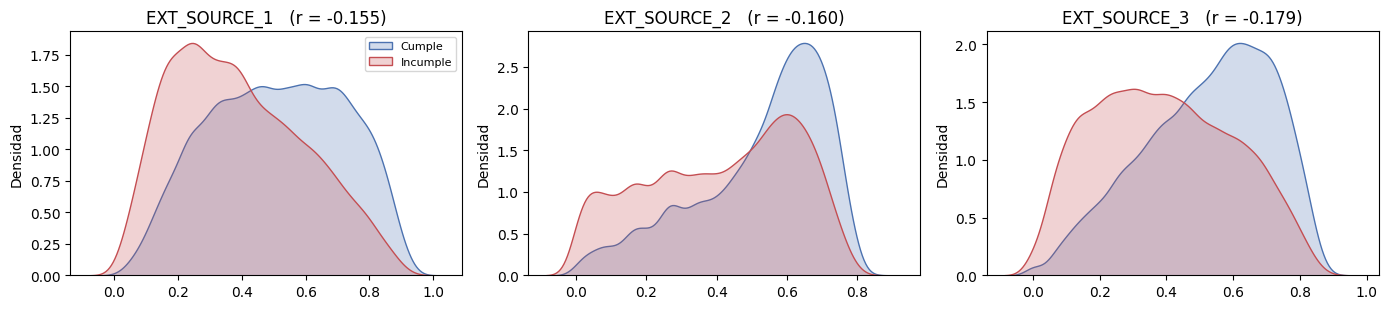

In [15]:
ext = df[['TARGET', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].assign(EDAD=edad)
observado = (df['EXT_SOURCE_1_AUSENTE'] == 0) & (df['EXT_SOURCE_3_AUSENTE'] == 0)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
for a, (m, t) in zip(ax, [(ext[observado], f'Solo observados (n={observado.sum():,})'),
                          (ext, f'Tras imputacion (n={len(ext):,})')]):
    sns.heatmap(m.corr(), cmap='RdYlBu_r', vmin=-.25, vmax=.6, annot=True, fmt='+.2f',
                annot_kws={'size': 7}, cbar=False, ax=a)
    a.set_title(t, fontsize=9)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 3, figsize=(14, 3.2))
for a, s in zip(ax, ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']):
    ind = f'{s}_AUSENTE'
    d = df[df[ind] == 0] if ind in df.columns else df
    for t, lab, c in [(0, 'Cumple', '#4c72b0'), (1, 'Incumple', '#c44e52')]:
        densidad(d.loc[d['TARGET'] == t, s], a, lab, c)
    a.set(title=f'{s}   (r = {d[s].corr(d["TARGET"]):+.3f})', xlabel='', ylabel='Densidad')
ax[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

Sobre los 109,742 registros con las tres fuentes observadas, las correlaciones con TARGET
son −0.155, −0.145 y −0.173: mayor puntaje externo se asocia a menor probabilidad de
incumplimiento, resultado coherente con la naturaleza de un puntaje crediticio. Las
densidades condicionales confirman el desplazamiento, más marcado en EXT_SOURCE_3.

La comparación entre ambas matrices cuantifica el costo de la imputación por mediana:
la correlación de EXT_SOURCE_1 con TARGET cae de −0.155 a −0.099 y su asociación con la
edad de 0.596 a 0.362, pues el 56.4% de valores sustituidos por una constante carece de
varianza y diluye la relación. Es la manifestación empírica del sesgo anticipado en la
fase anterior bajo el supuesto MNAR, y justifica que los indicadores de ausencia acompañen
a las variables imputadas durante el modelado.

La correlación de 0.596 entre EXT_SOURCE_1 y la edad sugiere además que este puntaje
incorpora la edad entre sus insumos; las tres fuentes, en cambio, presentan correlaciones
entre sí no superiores a 0.21, de modo que aportan información en buena medida
complementaria.

## Gráfico de pares

El gráfico de pares reúne en una sola matriz las distribuciones marginales y las
relaciones bivariadas de las tres fuentes externas y la edad, discriminadas por TARGET.

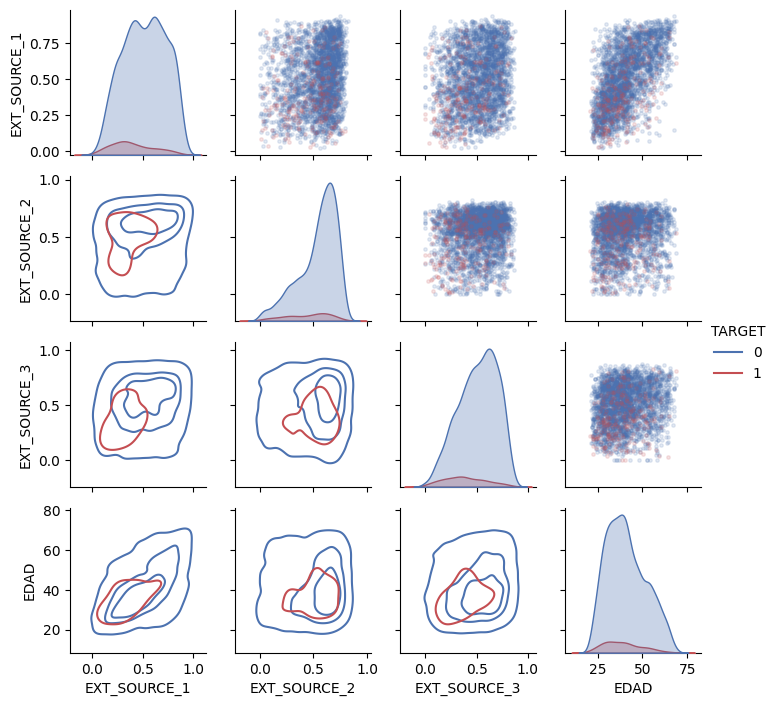

In [16]:
# sin la cota, `sample` aborta con "Cannot take a larger sample than population"
# en cuanto los casos observados son menos de 3,000 (submuestras, otra particion)
muestra = ext[observado].sample(min(3000, int(observado.sum())), random_state=0)

g = sns.PairGrid(muestra, hue='TARGET', height=1.8, diag_sharey=False,
                 vars=['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'EDAD'],
                 palette={0: '#4c72b0', 1: '#c44e52'})
g.map_upper(plt.scatter, alpha=.15, s=6)
g.map_diag(sns.kdeplot, fill=True, alpha=.3)
g.map_lower(sns.kdeplot, levels=4)
g.add_legend(title='TARGET')
plt.show()

La diagonal reproduce el desplazamiento de las densidades ya descrito. Fuera de ella, el
único patrón bivariado nítido es la relación lineal positiva entre EXT_SOURCE_1 y la edad,
consistente con el coeficiente de 0.596. Los restantes paneles muestran nubes difusas sin
frontera aparente entre ambas clases, lo que confirma que la separación no es alcanzable
mediante pares de variables y exige la combinación conjunta de un número mayor de
predictores.

La ingeniería de características construye variables nuevas a partir de las existentes con
el fin de exponer relaciones que el modelo no puede inferir directamente. Se aplican dos
procedimientos: la expansión polinomial, de carácter automático, y la construcción de
razones financieras fundada en conocimiento del dominio.

## Características polinomiales

Se generan potencias e interacciones hasta grado tres sobre las cuatro variables de mayor
asociación con el objetivo: las tres fuentes externas y la edad. El interés reside en los
términos de interacción, que capturan efectos conjuntos invisibles al examinar cada
variable por separado.

In [17]:
from sklearn.preprocessing import PolynomialFeatures

base = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH']
pf = PolynomialFeatures(degree=3, include_bias=False)
poly = pd.DataFrame(pf.fit_transform(df[base].abs()),
                    columns=pf.get_feature_names_out(base), index=df.index)
poly['TARGET'] = df['TARGET']

rp = poly.corr()['TARGET'].drop('TARGET').sort_values()
print(f'{poly.shape[1] - 1} terminos generados a partir de {len(base)} variables\n')
print(rp.head(8).to_string(float_format=lambda v: f'{v:+.3f}'))
print(f'\nMaximo |r|: original {df[base].abs().corrwith(df["TARGET"]).abs().max():.3f}'
      f'  ->  polinomial {rp.abs().max():.3f}')

34 terminos generados a partir de 4 variables

EXT_SOURCE_2 EXT_SOURCE_3                -0.194
EXT_SOURCE_1 EXT_SOURCE_2 EXT_SOURCE_3   -0.190
EXT_SOURCE_2 EXT_SOURCE_3 DAYS_BIRTH     -0.181
EXT_SOURCE_2^2 EXT_SOURCE_3              -0.176
EXT_SOURCE_2 EXT_SOURCE_3^2              -0.172
EXT_SOURCE_1 EXT_SOURCE_2                -0.167
EXT_SOURCE_1 EXT_SOURCE_3                -0.164
EXT_SOURCE_2                             -0.160

Maximo |r|: original 0.160  ->  polinomial 0.194


Los cuatro predictores originales generan 34 términos. El producto
EXT_SOURCE_2 × EXT_SOURCE_3 alcanza −0.194, superando en veintiún por ciento la mejor
correlación individual (−0.160), y los ocho términos más asociados son todos productos de
al menos dos fuentes externas. Que las interacciones dominen sobre las potencias indica que
la señal proviene de la combinación de puntajes y no de transformaciones no lineales de
uno solo: un solicitante penalizado simultáneamente por dos fuentes independientes concentra
un riesgo superior al que sugiere cada puntaje aislado.

La ganancia debe interpretarse con cautela. La expansión multiplica por ocho el número de
variables e introduce colinealidad severa —cada término es función determinista de sus
factores—, y las correlaciones se calculan sobre el mismo conjunto que originó las
variables, por lo que la mejora podría no sostenerse fuera de la muestra. Su utilidad real
solo puede establecerse comparando el desempeño del modelo con y sin ellas.

## Características de conocimiento del dominio

El segundo procedimiento construye razones que expresan relaciones económicas conocidas en
la evaluación de crédito, magnitudes relativas que ninguna variable original contiene de
forma explícita:

- **CREDIT_INCOME_PERCENT**: monto del crédito sobre el ingreso anual, esto es, el nivel de
  endeudamiento asumido.
- **ANNUITY_INCOME_PERCENT**: cuota sobre ingreso, o carga financiera periódica.
- **CREDIT_TERM**: cuota sobre monto, cuyo inverso aproxima el plazo del crédito.
- **DAYS_EMPLOYED_PERCENT**: antigüedad laboral sobre edad, indicador de estabilidad
  ocupacional.

      CREDIT_INCOME_PERCENT  ANNUITY_INCOME_PERCENT  CREDIT_TERM  DAYS_EMPLOYED_PERCENT
mean                  3.958                   0.181        0.054                  0.142
50%                   3.265                   0.163        0.050                  0.091
std                   2.690                   0.095        0.022                  0.125
max                  84.737                   1.876        0.158                  0.729


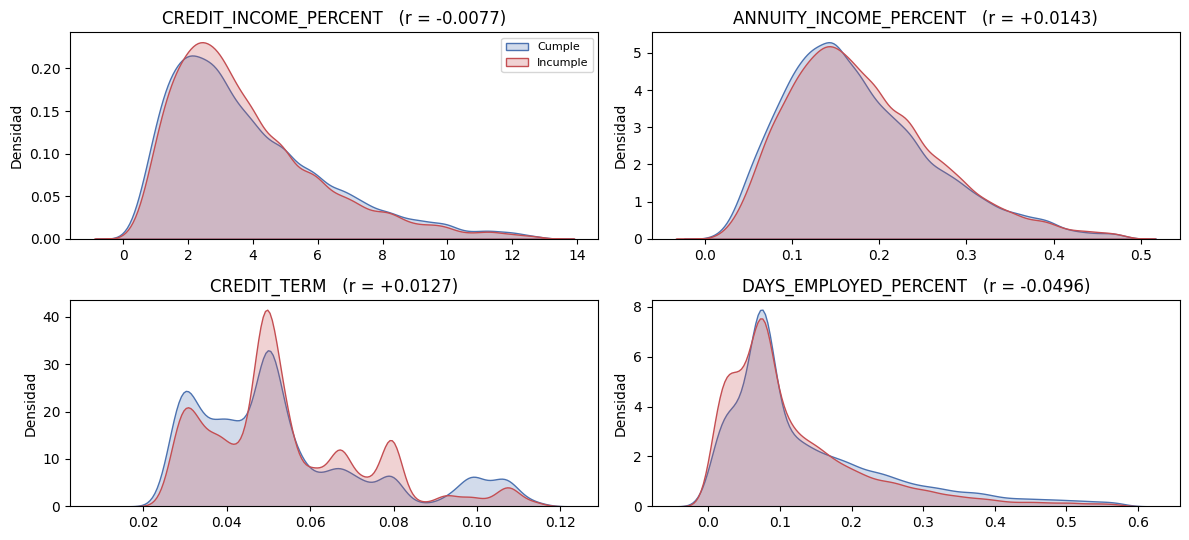

In [18]:
df = df.copy()          # compacta antes de anadir las razones de dominio
df = df.assign(
    CREDIT_INCOME_PERCENT=df['AMT_CREDIT'] / df['AMT_INCOME_TOTAL'],
    ANNUITY_INCOME_PERCENT=df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL'],
    CREDIT_TERM=df['AMT_ANNUITY'] / df['AMT_CREDIT'],
    DAYS_EMPLOYED_PERCENT=df['DAYS_EMPLOYED'] / df['DAYS_BIRTH'],
)
dominio = ['CREDIT_INCOME_PERCENT', 'ANNUITY_INCOME_PERCENT',
           'CREDIT_TERM', 'DAYS_EMPLOYED_PERCENT']

print(df[dominio].describe().loc[['mean', '50%', 'std', 'max']]
      .to_string(float_format=lambda v: f'{v:,.3f}'))

fig, ax = plt.subplots(2, 2, figsize=(12, 5.5))
for a, f in zip(ax.ravel(), dominio):
    lim = df[f].quantile(.99)
    for t, lab, c in [(0, 'Cumple', '#4c72b0'), (1, 'Incumple', '#c44e52')]:
        densidad(df.loc[(df['TARGET'] == t) & (df[f] <= lim), f], a, lab, c)
    a.set(title=f'{f}   (r = {df[f].corr(df["TARGET"]):+.4f})', xlabel='', ylabel='Densidad')
ax[0, 0].legend(fontsize=8)
plt.tight_layout()
plt.show()

Las magnitudes resultan económicamente coherentes: el crédito mediano equivale a 3.3 veces
el ingreso anual, la cuota absorbe cerca del 16% del ingreso y el inverso de CREDIT_TERM
sitúa el plazo mediano en unos veinte meses. La distribución de CREDIT_INCOME_PERCENT
presenta un máximo de 84.7, reflejo de los valores extremos de ingreso ya documentados,
razón por la cual las densidades se representan truncadas en el percentil 99.

Las correlaciones son muy reducidas: −0.008, +0.014, +0.013 y −0.050 respectivamente. Solo
DAYS_EMPLOYED_PERCENT alcanza el orden de magnitud de los predictores del bloque principal,
y su signo negativo indica que una mayor proporción de vida laboral acumulada se asocia a
menor riesgo. Las densidades de las tres razones financieras resultan casi indistinguibles
entre clases, con una diferencia apenas perceptible en ANNUITY_INCOME_PERCENT.

El resultado no invalida el procedimiento. Estas razones fueron construidas por su
plausibilidad económica, no por su asociación observada, y su aporte puede materializarse
en interacción con otras variables aunque su efecto marginal sea nulo. La decisión de
conservarlas corresponde a la etapa de modelado, mediante comparación explícita del
desempeño con y sin ellas.

# Fase 2 del EDA — Las seis tablas de historial

La fase anterior agotó lo que `application_train` puede decir por sí sola. Las seis tablas
restantes carecen de la variable `TARGET`, de modo que la pregunta que las organiza no es
cuál de sus variables anticipa el incumplimiento —cosa que en ellas no puede establecerse—
sino de qué manera deben resumirse para incorporarse al análisis.

El obstáculo es de granularidad. `application` registra una fila por solicitante, mientras
que las tablas de historial registran una fila por crédito externo, por solicitud previa,
por mes de observación o por cuota pagada. Un solicitante con veintisiete créditos
reportados ocupa veintisiete filas en `bureau` y una sola en `application`; cualquier unión
directa entre ambas lo duplicaría tantas veces como registros históricos posea, y la unidad
de análisis dejaría de ser la persona. Reducir esas veintisiete filas a una constituye el
trabajo central de esta fase, y decidir con qué estadísticos hacerlo exige conocer antes
qué representa cada fila, cuántas corresponden a cada cliente, a qué fracción de la cartera
alcanzan y con qué profundidad temporal.

Cada tabla se examina bajo las mismas cinco preguntas:

1. ¿Qué representa una fila y mediante qué llave se vincula con `application`?
2. ¿Cuántas filas corresponden a cada cliente? Mediana, percentil 95 y máximo.
3. ¿Qué cobertura tiene? Porcentaje de solicitantes que aparecen en ella.
4. ¿Cuál es su columna de tiempo y hasta dónde se extiende hacia atrás?
5. ¿Qué columnas contienen información aprovechable y cuáles son identificadores,
   constantes o códigos administrativos?

A ellas se añaden dos o tres gráficas propias de cada tabla, seleccionadas por su
pertinencia para la decisión de agregación y no por completitud descriptiva. El resultado
se consolida en un cuadro comparativo y en una frase por tabla que fija qué debe resumirse
de ella, insumo con el que el Nivel 3 construye las variables definitivas.

## Configuración y lectura

Las seis tablas suman del orden de 58 millones de filas y cerca de 2.5 GB en formato
delimitado, volumen que vuelve costosa la lectura repetida durante el trabajo exploratorio.
Se adoptan tres medidas: los enteros se reducen al tipo de menor tamaño compatible con su
rango, el texto de baja cardinalidad se convierte al tipo categórico —representación que
almacena cada nivel una sola vez— y cada tabla se memoriza en formato columnar tras la
primera lectura, de modo que las siguientes ejecuciones prescindan del análisis del
delimitado. Las tablas se procesan además de forma secuencial, liberando la memoria de cada
una antes de cargar la siguiente, pues su conjunto excede la memoria disponible en un
equipo corriente.

Solo se conserva la columna de identificación de `application_train`: el objetivo no
interviene en este nivel, y su uso sobre las tablas de historial constituiría precisamente
el error que el plan de trabajo advierte.

In [19]:
import os, gc, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

# --- localizacion del conjunto, sin rutas fijas de ninguna maquina ---------------
ARCHIVOS_HC = ['application_train.csv', 'application_test.csv', 'bureau.csv',
               'bureau_balance.csv', 'previous_application.csv',
               'installments_payments.csv', 'POS_CASH_balance.csv',
               'credit_card_balance.csv']


def _completitud(d):
    """Cuantos archivos del conjunto hay en `d`, contando solo ficheros legibles.

    Usa isfile y no exists: en este proyecto llego a existir un DIRECTORIO llamado
    `application_train.csv` que contenia dentro el csv, y `exists` lo daba por bueno
    hasta que `read_csv` fallaba con PermissionError al intentar abrir una carpeta.
    """
    if not d or not os.path.isdir(d):
        return 0
    return sum(os.path.isfile(os.path.join(d, a)) for a in ARCHIVOS_HC)



def _corta(p):
    """Ruta para mostrar sin datos de la maquina: solo las dos ultimas carpetas."""
    partes = [x for x in os.path.normpath(str(p)).split(os.sep) if x]
    return os.path.join('...', *partes[-2:])


def resolver_ruta(minimo=1, verboso=True):
    """Devuelve el directorio con mas archivos del conjunto, o None si no hay ninguno.

    Si HOME_CREDIT_DIR esta definida y apunta a una carpeta con el conjunto, se
    devuelve sin mas. En su defecto busca una RUTA ya definida en el entorno, el
    directorio de trabajo y hasta dos niveles por debajo de las ubicaciones
    habituales. Entre esos candidatos gana el mas completo, de modo que una carpeta
    con un solo csv suelto no desplaza a la que trae el conjunto entero.
    """
    bases = [os.getcwd(), os.path.expanduser('~'),
             os.path.join(os.path.expanduser('~'), 'Desktop'),
             os.path.join(os.path.expanduser('~'), 'OneDrive', 'Escritorio'),
             os.path.join(os.path.expanduser('~'), 'OneDrive', 'Desktop'),
             os.path.join(os.path.expanduser('~'), 'Documents'),
             os.path.join(os.path.expanduser('~'), 'Downloads')]

    # Una ruta indicada a mano manda sobre la busqueda. Antes HOME_CREDIT_DIR
    # entraba como un candidato mas y la puntuacion podia descartarla en favor de
    # otra copia igual de completa solo por tener la ruta mas corta, de modo que
    # definir la variable no servia para desempatar entre dos copias del conjunto.
    forzada = os.environ.get('HOME_CREDIT_DIR')
    if forzada and _completitud(forzada) >= minimo:
        forzada = os.path.abspath(forzada)
        if verboso:
            print(f'Conjunto tomado de HOME_CREDIT_DIR: {_corta(forzada)}')
            print(f'  archivos encontrados: {_completitud(forzada)} de {len(ARCHIVOS_HC)}')
        return forzada

    candidatos = [globals().get('RUTA')]
    for b in bases:
        for patron in ('', '*', os.path.join('*', '*')):
            candidatos += [os.path.dirname(p) for p in
                           glob.glob(os.path.join(b, patron, 'application_train.csv'))]
        candidatos.append(b)

    vistos, puntuados = set(), []
    for c in candidatos:
        c = os.path.abspath(c) if c else None
        if not c or c in vistos:
            continue
        vistos.add(c)
        n = _completitud(c)
        if n >= minimo:
            puntuados.append((n, c))

    if not puntuados:
        return None
    puntuados.sort(key=lambda t: (-t[0], len(t[1])))
    mejor = puntuados[0][1]
    if verboso:
        print(f'Conjunto localizado en: {_corta(mejor)}')
        print(f'  archivos encontrados: {puntuados[0][0]} de {len(ARCHIVOS_HC)}')
        for n, c in puntuados[1:4]:
            print(f'  (descartado, {n} archivos) {_corta(c)}')
    return mejor


RUTA = resolver_ruta()
if RUTA is None:
    raise FileNotFoundError(
        'No se encontro el conjunto. Descarguelo de Kaggle (home-credit-default-risk) '
        'y deje los .csv en una carpeta, o defina la variable de entorno '
        'HOME_CREDIT_DIR con su ruta.')
AZUL, ROJO, GRIS = '#4c72b0', '#c44e52', '#8c8c8c'

CACHE = os.path.join(RUTA, 'cache')
os.makedirs(CACHE, exist_ok=True)


def comprimir(df):
    """Reduce el tipo de enteros y convierte texto de baja cardinalidad a categoria."""
    for c in df.select_dtypes('integer').columns:
        df[c] = pd.to_numeric(df[c], downcast='integer')
    for c in df.select_dtypes(include=['object', 'string']).columns:
        if df[c].nunique(dropna=False) < 0.5 * len(df):
            df[c] = df[c].astype('category')
    return df


def cargar(nombre, columnas=None):
    """Lee un .csv del conjunto y lo memoriza en parquet para las lecturas siguientes."""
    pq = os.path.join(CACHE, f'{nombre}.parquet')
    if os.path.exists(pq):
        df = pd.read_parquet(pq, columns=columnas)
    else:
        csv = os.path.join(RUTA, f'{nombre}.csv')
        if not os.path.isfile(csv):
            raise FileNotFoundError(
                f'Falta {nombre}.csv en {RUTA}. Descargue el conjunto completo de '
                'Kaggle (home-credit-default-risk), o apunte la variable de entorno '
                'HOME_CREDIT_DIR a la carpeta que lo contiene.')
        df = comprimir(pd.read_csv(csv))
        try:
            df.to_parquet(pq, index=False)
        except Exception:
            pass
        if columnas is not None:
            df = df[columnas]
    mb = df.memory_usage(deep=True).sum() / 1024 ** 2
    print(f'{nombre}: {df.shape[0]:,} filas x {df.shape[1]} columnas | {mb:,.0f} MB en memoria')
    return df


CLIENTES = set(cargar('application_train', ['SK_ID_CURR'])['SK_ID_CURR'])
print(f'\nClientes en application_train: {len(CLIENTES):,}')

Conjunto localizado en: ...\PROYECTOS\Home-Credit
  archivos encontrados: 8 de 8
application_train: 307,511 filas x 1 columnas | 1 MB en memoria

Clientes en application_train: 307,511


## Perfilado común

Las cinco preguntas admiten una respuesta única para las seis tablas, de modo que se
resuelven mediante una función que acumula sus resultados en un registro común. La
cobertura se calcula sobre el universo de la llave correspondiente, que para cinco tablas
es el conjunto de solicitantes y para `bureau_balance` es el conjunto de créditos externos,
única forma de interpretarla correctamente en una tabla que no contiene `SK_ID_CURR`. Se
añaden una función que clasifica las columnas según su papel —identificador, tiempo,
cualitativa o cuantitativa— y una que ordena los faltantes, ambas necesarias para la quinta
pregunta.

In [20]:
PERFILES = []


def perfilar(nombre, df, llave, col_tiempo, universo, unidad='dias'):
    """Responde las cinco preguntas fijas del Nivel 2 y acumula el resultado."""
    n = df.groupby(llave, observed=True).size()
    t = df[col_tiempo]
    escala = 365.25 if unidad == 'dias' else 12
    perfil = {
        'Tabla': nombre,
        'Filas': len(df),
        'Columnas': df.shape[1],
        'Llave': llave,
        'Entidades': df[llave].nunique(),
        'Filas_med': n.median(),
        'Filas_p95': n.quantile(.95),
        'Filas_max': n.max(),
        'Cobertura_%': round(100 * df[llave].isin(universo).groupby(df[llave]).any().sum() / len(universo), 1),
        'Col_tiempo': col_tiempo,
        'Antiguedad_max_anos': round(abs(t.min()) / escala, 1),
        'Nulos_%': round(100 * sum(df[c].isnull().sum() for c in df.columns) / df.size, 1),
    }
    PERFILES.append(perfil)
    print(pd.Series(perfil).to_string())
    return perfil


def inventario(df, llave):
    """Clasifica las columnas en identificadores, tiempo, numericas y categoricas."""
    ids = [c for c in df.columns if c.startswith('SK_ID')]
    tiempo = [c for c in df.columns if c.startswith(('DAYS_', 'MONTHS_'))]
    # 'str' es obligatorio: pandas lee el texto de los csv con ese dtype, no con
    # 'object'. Sin el, toda columna de texto que `comprimir` no haya pasado a
    # 'category' se colaba en la lista de numericas.
    cat = [c for c in df.columns if c not in ids + tiempo
           and str(df[c].dtype) in ('object', 'str', 'category')]
    num = [c for c in df.columns if c not in ids + tiempo + cat]
    print(f'Identificadores ({len(ids)}): {ids}')
    print(f'Tiempo          ({len(tiempo)}): {tiempo}')
    print(f'Categoricas     ({len(cat)}): {cat}')
    print(f'Numericas       ({len(num)}): {num}')
    return {'ids': ids, 'tiempo': tiempo, 'cat': cat, 'num': num}


def faltantes(df, top=10):
    t = 100 * df.isnull().mean()
    t = t[t > 0].sort_values(ascending=False).head(top)
    return t.rename('Pct_nulos').to_frame()


def barras(serie, ax, titulo, color=AZUL):
    """Barras horizontales con la frecuencia relativa de una variable cualitativa."""
    v = 100 * serie.value_counts(normalize=True, dropna=False).sort_values()
    ax.barh(v.index.astype(str), v.values, color=color)
    for i, x in enumerate(v.values):
        ax.text(x + max(v.values) * .01, i, f'{x:.1f}%', va='center', fontsize=7)
    ax.set(title=titulo, xlabel='% de filas')
    ax.set_xlim(0, max(v.values) * 1.18)
    return v

## `bureau`

Cada fila corresponde a un crédito del solicitante ante **otra** entidad financiera,
reportado a la central de riesgo antes de la fecha de solicitud. Se vincula con
`application` por `SK_ID_CURR` y posee llave propia, `SK_ID_BUREAU`, que la conecta a su
vez con el historial mensual. Es la única tabla del conjunto que describe el comportamiento
del solicitante fuera de Home Credit, y por ello resulta la más informativa para un
segmento cuya característica definitoria es la ausencia de historial interno.

In [21]:
bureau = cargar('bureau')
perfilar('bureau', bureau, 'SK_ID_CURR', 'DAYS_CREDIT', CLIENTES)
inv_bur = inventario(bureau, 'SK_ID_CURR')
print('\n', faltantes(bureau).to_string())

bureau: 1,716,428 filas x 17 columnas | 138 MB en memoria


Tabla                       bureau
Filas                      1716428
Columnas                        17
Llave                   SK_ID_CURR
Entidades                   305811
Filas_med                     4.00
Filas_p95                    14.00
Filas_max                      116
Cobertura_%                  85.70
Col_tiempo             DAYS_CREDIT
Antiguedad_max_anos           8.00
Nulos_%                      13.50
Identificadores (2): ['SK_ID_CURR', 'SK_ID_BUREAU']
Tiempo          (4): ['DAYS_CREDIT', 'DAYS_CREDIT_ENDDATE', 'DAYS_ENDDATE_FACT', 'DAYS_CREDIT_UPDATE']
Categoricas     (3): ['CREDIT_ACTIVE', 'CREDIT_CURRENCY', 'CREDIT_TYPE']
Numericas       (8): ['CREDIT_DAY_OVERDUE', 'AMT_CREDIT_MAX_OVERDUE', 'CNT_CREDIT_PROLONG', 'AMT_CREDIT_SUM', 'AMT_CREDIT_SUM_DEBT', 'AMT_CREDIT_SUM_LIMIT', 'AMT_CREDIT_SUM_OVERDUE', 'AMT_ANNUITY']



                         Pct_nulos
AMT_ANNUITY                 71.47
AMT_CREDIT_MAX_OVERDUE      65.51
DAYS_ENDDATE_FACT           36.92
AMT_CREDIT_SUM_LIMIT        34.48
AMT_CREDIT_SUM_DEBT         15.01
DAYS_CREDIT_ENDDATE          6.15
AMT_CREDIT_SUM               0.00


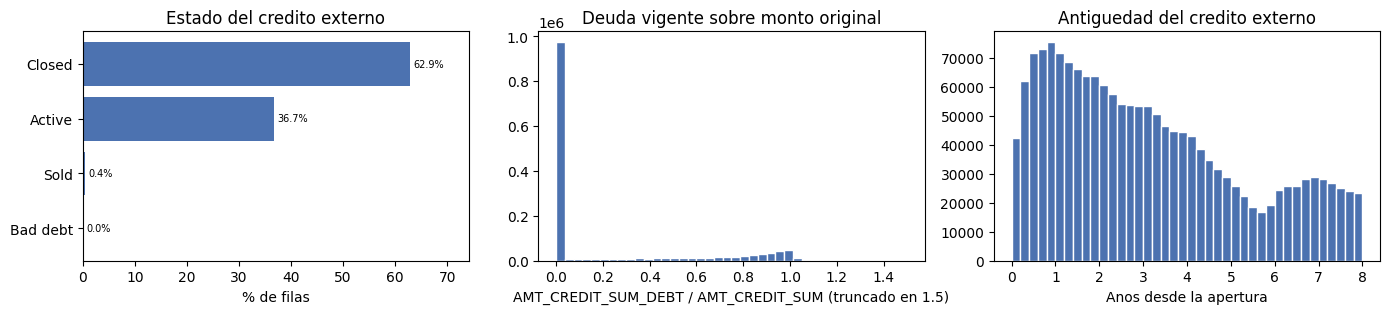

Creditos por cliente        : mediana 4
Vigentes por cliente        : mediana 2
Deuda relativa > 1          : 1.61% de los creditos
Con algun dia de mora hoy   : 0.25%


Monedas distintas de la 1   : 0.08%
DAYS_CREDIT_ENDDATE maximo  : 31,199 dias en el futuro


16691

In [22]:
bureau['DEUDA_REL'] = (bureau['AMT_CREDIT_SUM_DEBT'] / bureau['AMT_CREDIT_SUM']).replace([np.inf, -np.inf], np.nan)

fig, ax = plt.subplots(1, 3, figsize=(14, 3.4))
barras(bureau['CREDIT_ACTIVE'], ax[0], 'Estado del credito externo')
ax[1].hist(bureau['DEUDA_REL'].clip(0, 1.5).dropna(), bins=40, color=AZUL, edgecolor='white')
ax[1].set(title='Deuda vigente sobre monto original', xlabel='AMT_CREDIT_SUM_DEBT / AMT_CREDIT_SUM (truncado en 1.5)')
ax[2].hist(-bureau['DAYS_CREDIT'] / 365.25, bins=40, color=AZUL, edgecolor='white')
ax[2].set(title='Antiguedad del credito externo', xlabel='Anos desde la apertura')
plt.tight_layout(); plt.show()

act = bureau['CREDIT_ACTIVE'].astype(str).eq('Active')
print(f'Creditos por cliente        : mediana {bureau.groupby("SK_ID_CURR").size().median():.0f}')
print(f'Vigentes por cliente        : mediana {act.groupby(bureau["SK_ID_CURR"]).sum().median():.0f}')
print(f'Deuda relativa > 1          : {100 * (bureau["DEUDA_REL"] > 1).mean():.2f}% de los creditos')
print(f'Con algun dia de mora hoy   : {100 * bureau["CREDIT_DAY_OVERDUE"].gt(0).mean():.2f}%')
print(f'Monedas distintas de la 1   : {100 * bureau["CREDIT_CURRENCY"].astype(str).ne("currency 1").mean():.2f}%')
print(f'DAYS_CREDIT_ENDDATE maximo  : {bureau["DAYS_CREDIT_ENDDATE"].max():,.0f} dias en el futuro')

IDS_BURO = set(bureau['SK_ID_BUREAU'])
PUENTE = bureau[['SK_ID_BUREAU', 'SK_ID_CURR']].copy()
del bureau; gc.collect()

**Lectura.** La tabla contiene 1,716,428 créditos externos repartidos entre 305,811
personas —cifra que excede el tamaño de `application_train` porque comprende también a los
solicitantes de `test`—, con una mediana de 4 créditos por cliente, 14 en el percentil 95 y
un máximo de 116. La cobertura sobre el conjunto de entrenamiento alcanza 85.7%, de modo
que 14.3% de los solicitantes carece por completo de registro en la central de riesgo. Esa
ausencia no es un vacío técnico sino un rasgo del segmento que atiende la entidad, y debe
conservarse como indicador antes que imputarse.

La distribución de `CREDIT_ACTIVE` muestra que 62.9% de los créditos figura como cerrado y
36.7% como vigente, mientras que `Sold` y `Bad debt` reúnen 0.4% de los registros y no
admiten tratamiento separado por su tamaño. La mediana de créditos vigentes por cliente es
2. La razón entre deuda pendiente y monto originalmente concedido se concentra de forma
acusada en cero —cerca de dos tercios de los créditos con dato están amortizados,
proporción coherente con la de contratos cerrados— y presenta una segunda acumulación entre
0.6 y 1.0 que corresponde a los vigentes; solo 1.61% la excede, casos atribuibles a
capitalización de intereses o a mora acumulada.

Tres observaciones condicionan el tratamiento posterior. `AMT_ANNUITY` y
`AMT_CREDIT_MAX_OVERDUE` presentan 71.5% y 65.5% de faltantes, proporción que desaconseja
promediarlas sin acompañarlas de un indicador de ausencia, mientras que la de
`DAYS_ENDDATE_FACT`, 36.9%, es estructural: corresponde a los créditos aún abiertos y
coincide en magnitud con la proporción de vigentes. La mora vigente al corte es
prácticamente inexistente —0.25% de los créditos con algún día de atraso y 0.08% en moneda
distinta de la principal, variable esta última que puede descartarse por constante—, de
manera que la señal de incumplimiento externo no reside en `CREDIT_DAY_OVERDUE` sino en el
historial mensual de `bureau_balance`. Y `DAYS_CREDIT_ENDDATE` alcanza 31,199 días, unos
ochenta y cinco años en el futuro, cifra incompatible con la definición de la variable y
análoga al centinela documentado en `DAYS_EMPLOYED` durante la fase anterior.

**Qué resumir de esta tabla.** El número de créditos externos y cuántos permanecen
vigentes, mediante el conteo y la proporción de `CREDIT_ACTIVE`; la deuda pendiente
agregada y su proporción sobre el monto concedido; la antigüedad del crédito más reciente y
del más antiguo, mediante el máximo y el mínimo de `DAYS_CREDIT`; y el máximo de
`AMT_CREDIT_MAX_OVERDUE` acompañado de su indicador de ausencia, dado que la mora vigente
al corte no discrimina.

## `bureau_balance`

Cada fila corresponde a un mes de observación de un crédito externo, no a un cliente:
la tabla se articula por `SK_ID_BUREAU` y no contiene `SK_ID_CURR`. De ahí que su
incorporación exija dos pasos —resumir primero por crédito, unir el resultado a `bureau` y
resumir después por solicitante—, y que su cobertura deba medirse en dos planos: qué
fracción de los créditos externos posee historial mensual y qué fracción de solicitantes
resulta alcanzada a través de ese encadenamiento.

`STATUS` codifica el estado del crédito en cada mes: `C` indica cerrado, `X` desconocido,
`0` al corriente, y los valores `1` a `5` niveles crecientes de mora, donde `5` corresponde
a la incobrabilidad. La escala es ordinal, condición que conviene preservar en la
agregación.

In [23]:
bb = cargar('bureau_balance')
perfilar('bureau_balance', bb, 'SK_ID_BUREAU', 'MONTHS_BALANCE', IDS_BURO, unidad='meses')

# El conteo por cliente se resuelve sobre el puente (1.7 M filas) y no sobre bb (27 M)
n_buro = bb.groupby('SK_ID_BUREAU', observed=True).size()
p = PUENTE.assign(N=PUENTE['SK_ID_BUREAU'].map(n_buro))
n_cli = p.groupby('SK_ID_CURR')['N'].sum()

print(f'\nCreditos de bureau con historial mensual: {100 * bb["SK_ID_BUREAU"].nunique() / len(IDS_BURO):.1f}%')
print(f'Clientes alcanzados via el puente        : {100 * p.loc[p["N"].notna(), "SK_ID_CURR"].nunique() / len(CLIENTES):.1f}%')
print(f'Filas por cliente (mediana / p95 / max)  : {n_cli.median():.0f} / {n_cli.quantile(.95):.0f} / {n_cli.max():.0f}')

bureau_balance: 27,299,925 filas x 3 columnas | 156 MB en memoria


Tabla                  bureau_balance
Filas                        27299925
Columnas                            3
Llave                    SK_ID_BUREAU
Entidades                      817395
Filas_med                       26.00
Filas_p95                       90.00
Filas_max                          97
Cobertura_%                     45.10
Col_tiempo             MONTHS_BALANCE
Antiguedad_max_anos              8.00
Nulos_%                          0.00



Creditos de bureau con historial mensual: 47.6%
Clientes alcanzados via el puente        : 43.8%
Filas por cliente (mediana / p95 / max)  : 0 / 390 / 2791


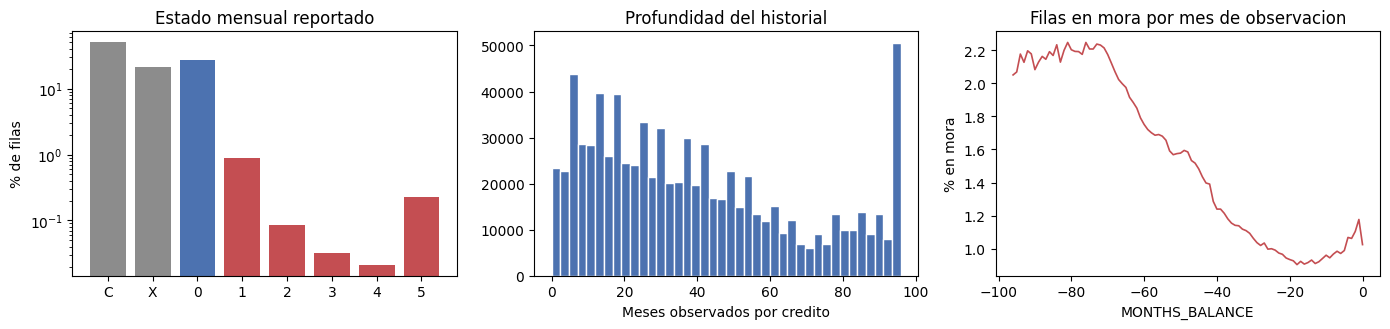

Filas en mora (STATUS 1-5)     : 1.26%


Creditos con algun mes en mora : 12.63%


Status X (desconocido)         : 21.28%


15190

In [24]:
orden = ['C', 'X', '0', '1', '2', '3', '4', '5']
fig, ax = plt.subplots(1, 3, figsize=(14, 3.4))

v = 100 * bb['STATUS'].value_counts(normalize=True).reindex(orden)
ax[0].bar(orden, v.values, color=[GRIS, GRIS, AZUL] + [ROJO] * 5)
ax[0].set(title='Estado mensual reportado', ylabel='% de filas', yscale='log')

prof = bb.groupby('SK_ID_BUREAU', observed=True)['MONTHS_BALANCE'].min().abs()
ax[1].hist(prof, bins=40, color=AZUL, edgecolor='white')
ax[1].set(title='Profundidad del historial', xlabel='Meses observados por credito')

mora = bb['STATUS'].astype(str).isin(list('12345'))
serie = 100 * mora.groupby(bb['MONTHS_BALANCE']).mean()
ax[2].plot(serie.index, serie.values, color=ROJO, lw=1.2)
ax[2].set(title='Filas en mora por mes de observacion', xlabel='MONTHS_BALANCE', ylabel='% en mora')
plt.tight_layout(); plt.show()

print(f'Filas en mora (STATUS 1-5)     : {100 * mora.mean():.2f}%')
print(f'Creditos con algun mes en mora : {100 * mora.groupby(bb["SK_ID_BUREAU"]).any().mean():.2f}%')
print(f'Status X (desconocido)         : {100 * bb["STATUS"].astype(str).eq("X").mean():.2f}%')

del bb, p; gc.collect()

**Lectura.** Con 27.3 millones de filas es la tabla más voluminosa del conjunto pese a
tener solo tres columnas. Su cobertura revela la restricción más seria del proyecto: apenas
45.1% de los créditos registrados en `bureau` posee historial mensual asociado, y el
encadenamiento hasta el solicitante reduce el alcance a 43.8% de la cartera, la mitad de lo
que cubre `bureau`. La mediana de filas por cliente es cero —más de la mitad de los
solicitantes con créditos externos no tiene un solo mes de historial— frente a 390 en el
percentil 95 y 2,791 en el máximo. La asimetría es extrema y obliga a acompañar toda
variable derivada de esta tabla con un indicador de disponibilidad.

Un segundo hecho merece registro. La tabla contiene 817,395 créditos distintos, unos 43,000
más de los que efectivamente casan con `bureau`: cerca de 5% de sus registros son huérfanos
y el encadenamiento en dos pasos los descarta de manera silenciosa. Conviene verificar esa
pérdida al ejecutar la unión en lugar de suponerla nula.

La profundidad mediana es de 26 meses por crédito, con un máximo de 97 y una acumulación
pronunciada en ese extremo, señal de truncamiento administrativo antes que de un límite
natural del producto.

La distribución de `STATUS` está dominada por los estados `C` y `0`, que reúnen 77.5% de
las observaciones. Los niveles de mora `1` a `5` representan en conjunto 1.26%, proporción
reducida que sin embargo se concentra en 12.63% de los créditos: la señal existe, es escasa
y está agrupada. Dentro de la escala, el nivel `5` resulta más frecuente que los niveles
`2` a `4`, comportamiento esperable en una variable absorbente —declarado incobrable, el
crédito conserva ese estado mes tras mes— y que aconseja resumirla por el máximo alcanzado
antes que por el promedio. El estado `X` alcanza 21.28% y merece atención: no significa
ausencia de mora sino ausencia de reporte, y confundirlo con `0` durante la agregación
introduciría un sesgo optimista sobre una quinta parte de las observaciones.

La serie del porcentaje de filas en mora según `MONTHS_BALANCE` desciende de manera
sostenida desde 2.2% en los meses más antiguos hasta 0.9% alrededor del mes −20, con un
repunte leve en los últimos meses observados. La lectura correcta no es que el
comportamiento de pago mejorara, sino que la composición del panel cambia con la
profundidad: solo los créditos de vida larga alcanzan a observarse ocho años atrás, y un
crédito en mora permanece reportado más tiempo que uno que se cierra sin incidencias. Sea
cual fuere la causa, un promedio sin ponderar sobre la ventana completa mezcla un período
con el doble de mora que el reciente, lo que respalda contrastar la agregación total contra
la restringida a los últimos doce meses en el Nivel 3.

**Qué resumir de esta tabla.** En el primer paso, por crédito: la proporción de meses en
cada estado, el peor estado alcanzado y el número de meses observados. En el segundo, por
cliente: el promedio y el máximo de esas proporciones sobre el conjunto de sus créditos,
más un indicador de disponibilidad de historial mensual.

## `previous_application`

Cada fila corresponde a una solicitud anterior del cliente ante la propia Home Credit,
identificada por `SK_ID_PREV`, con los parámetros del crédito pedido y el desenlace de la
decisión. Es la única tabla de historial que documenta solicitudes **rechazadas**: las tres
restantes de esta rama registran el comportamiento de pago y, por construcción, solo
contienen contratos que llegaron a existir. El rechazo previo constituye por sí mismo una
evaluación de riesgo emitida por la entidad, y su registro es el rastro que dejó.

In [25]:
prev = cargar('previous_application')
perfilar('previous_application', prev, 'SK_ID_CURR', 'DAYS_DECISION', CLIENTES)
inv_prev = inventario(prev, 'SK_ID_CURR')
print('\n', faltantes(prev).to_string())

previous_application: 1,670,214 filas x 37 columnas | 242 MB en memoria


Tabla                  previous_application
Filas                               1670214
Columnas                                 37
Llave                            SK_ID_CURR
Entidades                            338857
Filas_med                              4.00
Filas_p95                             13.00
Filas_max                                77
Cobertura_%                           94.60
Col_tiempo                    DAYS_DECISION
Antiguedad_max_anos                    8.00
Nulos_%                               18.00
Identificadores (2): ['SK_ID_PREV', 'SK_ID_CURR']
Tiempo          (6): ['DAYS_DECISION', 'DAYS_FIRST_DRAWING', 'DAYS_FIRST_DUE', 'DAYS_LAST_DUE_1ST_VERSION', 'DAYS_LAST_DUE', 'DAYS_TERMINATION']
Categoricas     (16): ['NAME_CONTRACT_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'FLAG_LAST_APPL_PER_CONTRACT', 'NAME_CASH_LOAN_PURPOSE', 'NAME_CONTRACT_STATUS', 'NAME_PAYMENT_TYPE', 'CODE_REJECT_REASON', 'NAME_TYPE_SUITE', 'NAME_CLIENT_TYPE', 'NAME_GOODS_CATEGORY', 'NAME_PORTFOLIO'

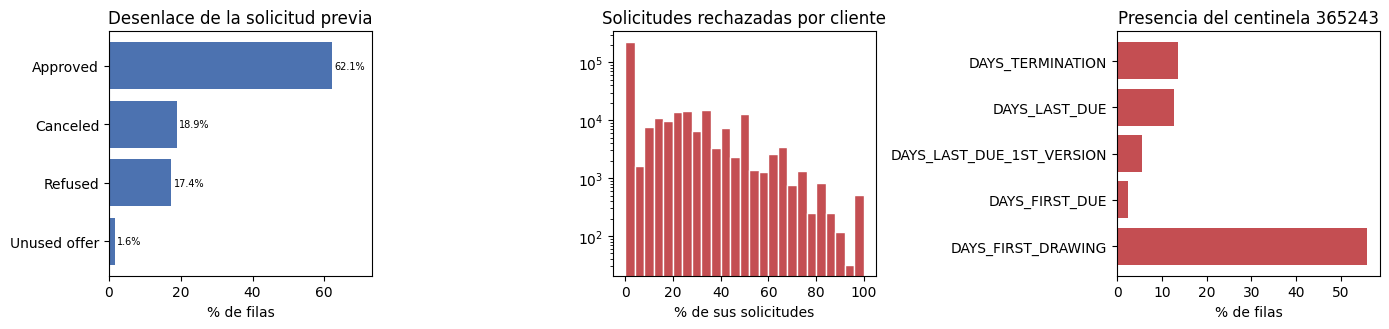

Solicitudes por cliente (mediana): 4
Clientes con al menos un rechazo : 34.9%

Centinela 365243 por columna (%):
 DAYS_FIRST_DRAWING          55.90
DAYS_FIRST_DUE               2.40
DAYS_LAST_DUE_1ST_VERSION    5.60
DAYS_LAST_DUE               12.60
DAYS_TERMINATION            13.50



Codigos XNA/XAP por columna (%):
 NAME_CASH_LOAN_PURPOSE   95.80
CODE_REJECT_REASON       81.30
NAME_PRODUCT_TYPE        63.70
NAME_GOODS_CATEGORY      56.90
NAME_SELLER_INDUSTRY     51.20
NAME_PAYMENT_TYPE        37.60
NAME_YIELD_GROUP         31.00
NAME_PORTFOLIO           22.30
NAME_CLIENT_TYPE          0.10
NAME_CONTRACT_TYPE        0.00


18738

In [26]:
COL_DIAS = ['DAYS_FIRST_DRAWING', 'DAYS_FIRST_DUE', 'DAYS_LAST_DUE_1ST_VERSION',
            'DAYS_LAST_DUE', 'DAYS_TERMINATION']
centinela = 100 * prev[COL_DIAS].eq(365243).mean()

fig, ax = plt.subplots(1, 3, figsize=(14, 3.4))
barras(prev['NAME_CONTRACT_STATUS'], ax[0], 'Desenlace de la solicitud previa')

rech = prev['NAME_CONTRACT_STATUS'].astype(str).eq('Refused')
pct = 100 * rech.groupby(prev['SK_ID_CURR']).mean()
ax[1].hist(pct, bins=25, color=ROJO, edgecolor='white')
ax[1].set(title='Solicitudes rechazadas por cliente', xlabel='% de sus solicitudes', yscale='log')

ax[2].barh(centinela.index, centinela.values, color=ROJO)
ax[2].set(title='Presencia del centinela 365243', xlabel='% de filas')
plt.tight_layout(); plt.show()

print(f'Solicitudes por cliente (mediana): {prev.groupby("SK_ID_CURR").size().median():.0f}')
print(f'Clientes con al menos un rechazo : {100 * rech.groupby(prev["SK_ID_CURR"]).any().mean():.1f}%')
print('\nCentinela 365243 por columna (%):\n', centinela.round(1).to_string())

xna = {c: 100 * prev[c].astype(str).isin(['XNA', 'XAP']).mean()
       for c in inv_prev['cat'] if prev[c].astype(str).isin(['XNA', 'XAP']).any()}
print('\nCodigos XNA/XAP por columna (%):\n',
      pd.Series(xna).sort_values(ascending=False).round(1).to_string())

del prev; gc.collect()

**Lectura.** La cobertura alcanza 94.6% de los solicitantes, la más alta del conjunto junto
con la de las tablas de pago: casi toda la cartera había tenido contacto previo con la
entidad, con una mediana de 4 solicitudes por persona, 13 en el percentil 95 y un máximo de
77. Del total, 62.1% fue aprobado, 18.9% cancelado, 17.4% rechazado y 1.6% corresponde a
ofertas concedidas pero no utilizadas. El histograma del porcentaje de rechazos por cliente
presenta una moda pronunciada en cero —la mayoría nunca fue rechazada— y una cola que se
extiende hasta el 100%, con acumulaciones en las fracciones simples propias de quienes
registran pocas solicitudes.

La distinción entre `Refused` y `Canceled` no es menor. El rechazo procede de la entidad y
expresa su juicio sobre el riesgo; la cancelación procede del cliente o del proceso, y su
interpretación es ambigua. Ambas deben resumirse por separado.

El examen de las columnas temporales confirma la presencia del centinela 365243 detectado
en la fase anterior, ahora en cinco variables, pero con un patrón que conviene leer con
cuidado porque conviven dos mecanismos distintos de ausencia. Las cinco columnas comparten
exactamente 40.30% de nulos, proporción próxima al 37.9% de solicitudes no aprobadas: un
crédito que nunca se otorgó carece de fechas de desembolso y de terminación, y esa ausencia
es estructural. El centinela, en cambio, opera sobre las solicitudes que sí prosperaron y su
incidencia varía por columna: 55% del total en `DAYS_FIRST_DRAWING` —cerca de nueve de cada
diez registros con dato—, 13% en `DAYS_TERMINATION`, 12% en `DAYS_LAST_DUE` y menos de 6%
en las dos restantes. Su significado difiere en cada caso: el primer desembolso no aplica a
los productos que no operan por disposición, y la terminación no ha ocurrido en los
contratos aún vigentes. El tratamiento, en cambio, es común: deben convertirse a nulo antes
de cualquier promedio, pues su magnitud arrastraría el resultado varios órdenes de
magnitud.

Los códigos `XNA` y `XAP` cumplen una función equivalente en las variables cualitativas:
señalan un campo no aplicable al tipo de producto y no una categoría real. `XAP` en
`CODE_REJECT_REASON` corresponde justamente a las solicitudes que no fueron rechazadas.
Conviene señalar por último que `RATE_INTEREST_PRIMARY` y `RATE_INTEREST_PRIVILEGED` faltan
en 99.6% de los registros y carecen de utilidad práctica, y que `NAME_TYPE_SUITE` falta en
49.1%.

**Qué resumir de esta tabla.** El número de solicitudes previas y la proporción rechazada,
cancelada y aprobada; la razón entre monto solicitado y monto concedido, que mide cuánto
recortó la entidad la petición; el promedio y el máximo de `AMT_ANNUITY` y `CNT_PAYMENT`; y
la antigüedad de la decisión más reciente mediante el máximo de `DAYS_DECISION`.

## `POS_CASH_balance`

Cada fila corresponde a un mes de observación de un crédito de consumo o de efectivo ya
otorgado, vinculado a `previous_application` por `SK_ID_PREV` y a `application` por
`SK_ID_CURR`, de modo que no requiere encadenamiento. La variable de interés es `SK_DPD`,
días de atraso en el mes, acompañada de `SK_DPD_DEF`, que excluye los atrasos por debajo
del umbral de tolerancia de la entidad. La diferencia entre ambas separa el retraso
administrativo del incumplimiento efectivo.

POS_CASH_balance: 10,001,358 filas x 8 columnas | 286 MB en memoria


Tabla                  POS_CASH_balance
Filas                          10001358
Columnas                              8
Llave                        SK_ID_CURR
Entidades                        337252
Filas_med                         22.00
Filas_p95                         80.00
Filas_max                           295
Cobertura_%                       94.10
Col_tiempo               MONTHS_BALANCE
Antiguedad_max_anos                8.00
Nulos_%                            0.10

                        Pct_nulos
CNT_INSTALMENT_FUTURE       0.26
CNT_INSTALMENT              0.26


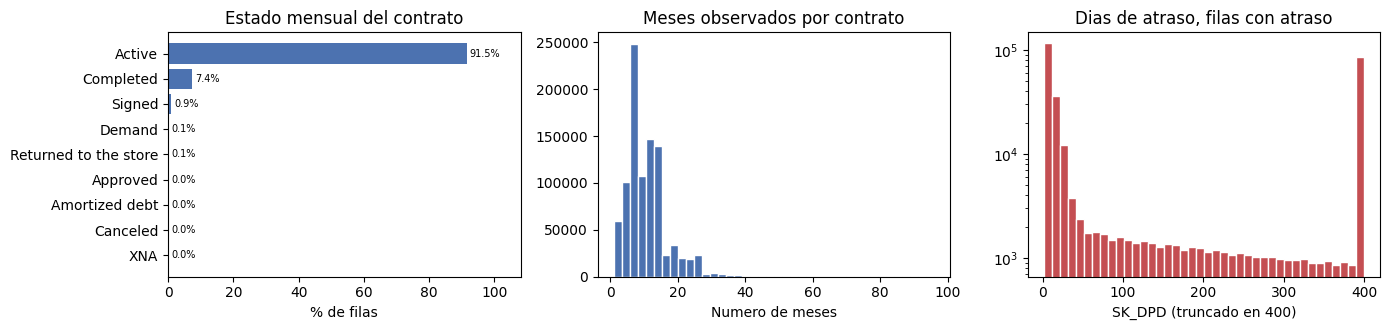

Filas con SK_DPD > 0            : 2.95%
Filas con SK_DPD_DEF > 0        : 1.14%
Clientes con algun atraso       : 18.7%


Clientes con atraso tolerado    : 13.6%
Atraso mediano cuando existe    : 19 dias


19703

In [27]:
pos = cargar('POS_CASH_balance')
perfilar('POS_CASH_balance', pos, 'SK_ID_CURR', 'MONTHS_BALANCE', CLIENTES, unidad='meses')
print('\n', faltantes(pos).to_string())

fig, ax = plt.subplots(1, 3, figsize=(14, 3.4))
barras(pos['NAME_CONTRACT_STATUS'], ax[0], 'Estado mensual del contrato')

m = pos.groupby(['SK_ID_PREV'], observed=True)['MONTHS_BALANCE'].size()
ax[1].hist(m, bins=40, color=AZUL, edgecolor='white')
ax[1].set(title='Meses observados por contrato', xlabel='Numero de meses')

d = pos.loc[pos['SK_DPD'] > 0, 'SK_DPD']
ax[2].hist(d.clip(0, 400), bins=40, color=ROJO, edgecolor='white')
ax[2].set(title='Dias de atraso, filas con atraso', xlabel='SK_DPD (truncado en 400)', yscale='log')
plt.tight_layout(); plt.show()

print(f'Filas con SK_DPD > 0            : {100 * pos["SK_DPD"].gt(0).mean():.2f}%')
print(f'Filas con SK_DPD_DEF > 0        : {100 * pos["SK_DPD_DEF"].gt(0).mean():.2f}%')
print(f'Clientes con algun atraso       : {100 * pos["SK_DPD"].gt(0).groupby(pos["SK_ID_CURR"]).any().mean():.1f}%')
print(f'Clientes con atraso tolerado    : {100 * pos["SK_DPD_DEF"].gt(0).groupby(pos["SK_ID_CURR"]).any().mean():.1f}%')
print(f'Atraso mediano cuando existe    : {d.median():.0f} dias')

del pos; gc.collect()

**Lectura.** La tabla alcanza 94.1% de los solicitantes con una mediana de 22 filas por
cliente, 80 en el percentil 95 y un máximo de 295, cifras elevadas porque acumula todos los
meses de todos sus contratos previos. Carece prácticamente de faltantes. Los estados
`Active` y `Completed` concentran 98.9% de las observaciones —91.5% y 7.4%
respectivamente— y las siete categorías restantes suman poco más de un punto, de modo que
conviene agruparlas. El número de meses por contrato se concentra entre cinco y quince, con
moda cerca de ocho, reflejo de los plazos habituales del crédito de consumo.

Los atrasos son poco frecuentes en términos de filas —2.95% con `SK_DPD` positivo— pero
afectan a 18.7% de los clientes, brecha que ilustra por qué la agregación no puede
descansar en el promedio: una media calculada sobre decenas de meses diluye un episodio
aislado de mora hasta volverlo indistinguible de cero, mientras que el máximo lo conserva.
La comparación con `SK_DPD_DEF`, positivo en 1.14% de las filas, indica que alrededor de
tres de cada cinco atrasos registrados quedan por debajo del umbral de tolerancia de la
entidad; la diferencia entre ambas variables separa el retraso administrativo del
incumplimiento efectivo, y conviene resumir las dos por separado. El atraso mediano, cuando
existe, es de 19 días, pero la distribución posee una cola muy larga y un volumen
considerable de filas supera los 400 días, magnitud que ya no describe un retraso sino un
crédito abandonado.

**Qué resumir de esta tabla.** El número de contratos y de meses observados; el máximo y el
promedio de `SK_DPD` y de `SK_DPD_DEF`; la proporción de meses con atraso; y el estado del
contrato en el último mes disponible, que informa si los créditos siguen abiertos.

## `installments_payments`

Cada fila corresponde a una cuota de un crédito previo, con la fecha y el monto exigidos
frente a la fecha y el monto efectivamente pagados. Es la tabla de comportamiento más
directa del conjunto: no describe un saldo ni un estado administrativo, sino el acto de
pagar. Sus dos variables derivadas centrales son la diferencia
`DAYS_ENTRY_PAYMENT − DAYS_INSTALMENT`, positiva cuando el pago llegó después del
vencimiento, y la razón `AMT_PAYMENT / AMT_INSTALMENT`, inferior a la unidad cuando el pago
fue parcial.

installments_payments: 13,605,401 filas x 8 columnas | 649 MB en memoria


Tabla                  installments_payments
Filas                               13605401
Columnas                                   8
Llave                             SK_ID_CURR
Entidades                             339587
Filas_med                              25.00
Filas_p95                             131.00
Filas_max                                372
Cobertura_%                            94.80
Col_tiempo                   DAYS_INSTALMENT
Antiguedad_max_anos                     8.00
Nulos_%                                 0.00

                     Pct_nulos
DAYS_ENTRY_PAYMENT       0.02
AMT_PAYMENT              0.02


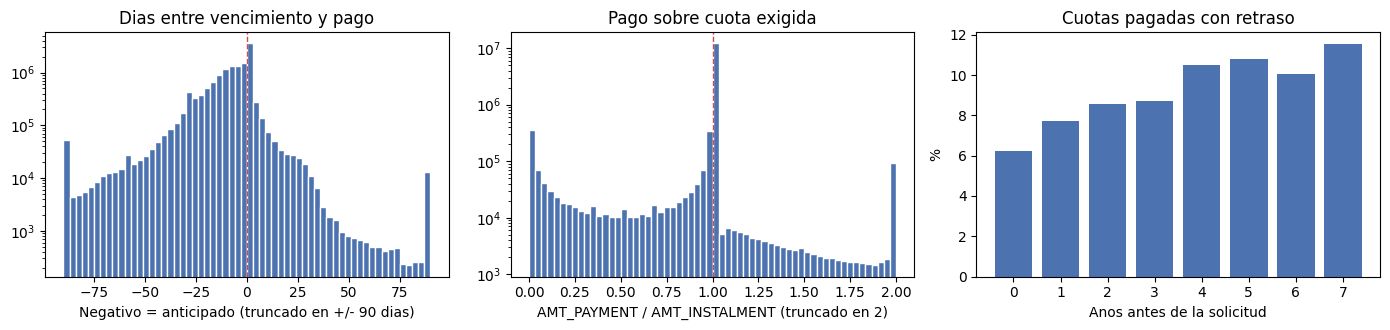

Cuotas pagadas con retraso      : 8.43%
Cuotas pagadas de forma parcial : 8.90%
Retraso mediano cuando existe   : 4 dias
Filas duplicadas por cuota      : 5.46%  (un pago puede fraccionarse)


Clientes con alguna cuota tarde : 53.0%


20965

In [28]:
ins = cargar('installments_payments')
perfilar('installments_payments', ins, 'SK_ID_CURR', 'DAYS_INSTALMENT', CLIENTES)
print('\n', faltantes(ins).to_string())

ins['RETRASO'] = ins['DAYS_ENTRY_PAYMENT'] - ins['DAYS_INSTALMENT']
ins['COBERTURA'] = ins['AMT_PAYMENT'] / ins['AMT_INSTALMENT'].replace(0, np.nan)

fig, ax = plt.subplots(1, 3, figsize=(14, 3.4))
ax[0].hist(ins['RETRASO'].clip(-90, 90).dropna(), bins=60, color=AZUL, edgecolor='white')
ax[0].axvline(0, color=ROJO, ls='--', lw=1)
ax[0].set(title='Dias entre vencimiento y pago', xlabel='Negativo = anticipado (truncado en +/- 90 dias)', yscale='log')

ax[1].hist(ins['COBERTURA'].clip(0, 2).dropna(), bins=60, color=AZUL, edgecolor='white')
ax[1].axvline(1, color=ROJO, ls='--', lw=1)
ax[1].set(title='Pago sobre cuota exigida', xlabel='AMT_PAYMENT / AMT_INSTALMENT (truncado en 2)', yscale='log')

tarde = ins['RETRASO'].gt(0)
ano = (-ins['DAYS_INSTALMENT'] // 365).clip(0, 7)
s = 100 * tarde.groupby(ano).mean()
ax[2].bar(s.index.astype(int).astype(str), s.values, color=AZUL)
ax[2].set(title='Cuotas pagadas con retraso', xlabel='Anos antes de la solicitud', ylabel='%')
plt.tight_layout(); plt.show()

dup = ins.duplicated(['SK_ID_PREV', 'NUM_INSTALMENT_NUMBER']).mean()
print(f'Cuotas pagadas con retraso      : {100 * tarde.mean():.2f}%')
print(f'Cuotas pagadas de forma parcial : {100 * ins["COBERTURA"].lt(0.999).mean():.2f}%')
print(f'Retraso mediano cuando existe   : {ins.loc[tarde, "RETRASO"].median():.0f} dias')
print(f'Filas duplicadas por cuota      : {100 * dup:.2f}%  (un pago puede fraccionarse)')
print(f'Clientes con alguna cuota tarde : {100 * tarde.groupby(ins["SK_ID_CURR"]).any().mean():.1f}%')

del ins; gc.collect()

**Lectura.** Es la tabla más costosa en memoria del conjunto —649 MB pese a tener ocho
columnas— y cubre 94.8% de los solicitantes, con una mediana de 25 cuotas por persona, 131
en el percentil 95 y un máximo de 372. Los faltantes son marginales: 0.02% en las dos
columnas de pago efectivo.

La distribución del retraso se concentra en valores negativos, con el modo inmediatamente
anterior al vencimiento: el pago anticipado es la norma. Solo 8.43% de las cuotas se pagó
con posterioridad a la fecha exigida y, cuando ocurre, la mediana del retraso es de cuatro
días; la cola derecha, sin embargo, es larga y contiene la señal de interés. La razón de
cobertura del pago se agrupa de manera extrema en la unidad —el pago exacto domina por dos
órdenes de magnitud sobre cualquier otro valor—, con 8.90% de cuotas pagadas por debajo de
lo exigido y una acumulación visible en cero que corresponde a cuotas sin pago alguno.

Pese a que solo 8.43% de las cuotas se pagó tarde, 53.0% de los clientes registra al menos
una, brecha que refuerza el argumento a favor del máximo y de las proporciones frente al
promedio simple.

Dos advertencias operativas. La primera es que una misma cuota figura en varias filas
cuando el pago se fraccionó: 5.46% de los registros duplica el par
`SK_ID_PREV`–`NUM_INSTALMENT_NUMBER`, de modo que el número de filas no equivale al número
de cuotas y las proporciones anteriores están calculadas sobre fracciones de pago. Si el
objetivo es medir cumplimiento y no actividad de pago, corresponde consolidar por cuota
antes de agregar.

La segunda es temporal. La proporción de cuotas pagadas con retraso crece de forma monótona
con la antigüedad, desde 6.2% en el año previo a la solicitud hasta 11.5% siete años antes,
casi el doble. La dirección coincide con lo observado en `bureau_balance` y admite la misma
lectura de composición, a lo que se suma aquí un efecto de selección evidente: quien llega
a solicitar un crédito nuevo tiende a haber pagado con puntualidad los meses inmediatamente
anteriores. Cualquiera que sea la explicación, el hallazgo justifica el contraste entre la
agregación completa y la restringida a los últimos doce meses que plantea el Nivel 3.

**Qué resumir de esta tabla.** El promedio y el máximo del retraso; la proporción de cuotas
pagadas con posterioridad al vencimiento; la proporción pagada de forma incompleta; y la
diferencia acumulada entre lo exigido y lo pagado, mediante la suma de
`AMT_INSTALMENT − AMT_PAYMENT`.

## `credit_card_balance`

Cada fila corresponde a un mes de observación de una tarjeta de crédito previa. La medida
característica es la utilización, razón entre el saldo y el límite vigente, indicador
habitual en la evaluación de riesgo revolvente: una tarjeta sostenidamente cerca de su tope
señala tensión de liquidez con independencia de que los pagos se realicen. Su cálculo exige
excluir los meses con límite nulo, que producirían una división indefinida.

credit_card_balance: 3,840,312 filas x 23 columnas | 513 MB en memoria


Tabla                  credit_card_balance
Filas                              3840312
Columnas                                23
Llave                           SK_ID_CURR
Entidades                           103558
Filas_med                            22.00
Filas_p95                            96.00
Filas_max                              192
Cobertura_%                          28.30
Col_tiempo                  MONTHS_BALANCE
Antiguedad_max_anos                   8.00
Nulos_%                               6.70

                             Pct_nulos
AMT_PAYMENT_CURRENT             20.00
AMT_DRAWINGS_ATM_CURRENT        19.52
AMT_DRAWINGS_OTHER_CURRENT      19.52
AMT_DRAWINGS_POS_CURRENT        19.52
CNT_DRAWINGS_ATM_CURRENT        19.52
CNT_DRAWINGS_POS_CURRENT        19.52
CNT_DRAWINGS_OTHER_CURRENT      19.52
AMT_INST_MIN_REGULARITY          7.95
CNT_INSTALMENT_MATURE_CUM        7.95


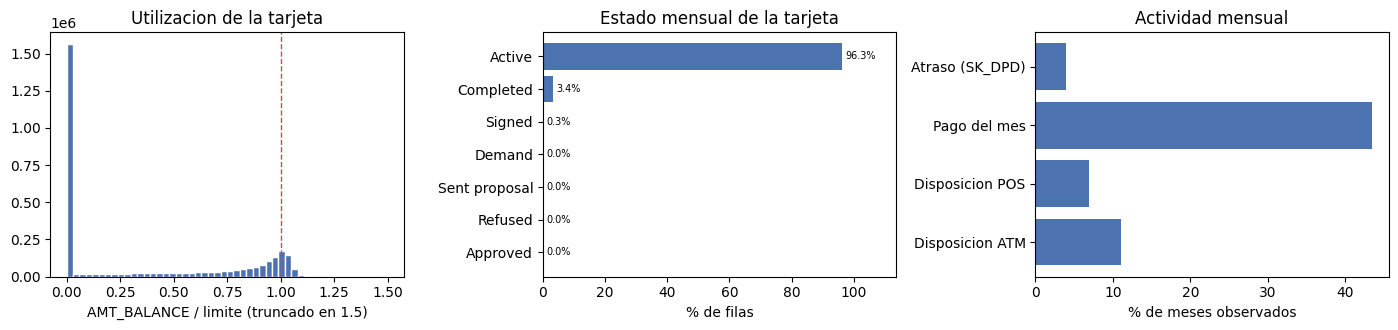

Meses con limite igual a cero   : 19.63%
Utilizacion mediana             : 0.01
Meses por encima del limite     : 8.71%
Clientes con tarjeta previa     : 103,558


29159

In [29]:
cc = cargar('credit_card_balance')
perfilar('credit_card_balance', cc, 'SK_ID_CURR', 'MONTHS_BALANCE', CLIENTES, unidad='meses')
print('\n', faltantes(cc).to_string())

lim = cc['AMT_CREDIT_LIMIT_ACTUAL'].replace(0, np.nan)
cc['UTILIZACION'] = (cc['AMT_BALANCE'] / lim).replace([np.inf, -np.inf], np.nan)

fig, ax = plt.subplots(1, 3, figsize=(14, 3.4))
ax[0].hist(cc['UTILIZACION'].clip(0, 1.5).dropna(), bins=50, color=AZUL, edgecolor='white')
ax[0].axvline(1, color=ROJO, ls='--', lw=1)
ax[0].set(title='Utilizacion de la tarjeta', xlabel='AMT_BALANCE / limite (truncado en 1.5)')

barras(cc['NAME_CONTRACT_STATUS'], ax[1], 'Estado mensual de la tarjeta')

ret = 100 * pd.Series({
    'Disposicion ATM': cc['AMT_DRAWINGS_ATM_CURRENT'].gt(0).mean(),
    'Disposicion POS': cc['AMT_DRAWINGS_POS_CURRENT'].gt(0).mean(),
    'Pago del mes': cc['AMT_PAYMENT_TOTAL_CURRENT'].gt(0).mean(),
    'Atraso (SK_DPD)': cc['SK_DPD'].gt(0).mean(),
})
ax[2].barh(ret.index, ret.values, color=AZUL)
ax[2].set(title='Actividad mensual', xlabel='% de meses observados')
plt.tight_layout(); plt.show()

print(f'Meses con limite igual a cero   : {100 * cc["AMT_CREDIT_LIMIT_ACTUAL"].eq(0).mean():.2f}%')
print(f'Utilizacion mediana             : {cc["UTILIZACION"].median():.2f}')
print(f'Meses por encima del limite     : {100 * cc["UTILIZACION"].gt(1).mean():.2f}%')
print(f'Clientes con tarjeta previa     : {cc["SK_ID_CURR"].nunique():,}')

del cc; gc.collect()

**Lectura.** Su cobertura es con diferencia la más baja del conjunto: 103,558 solicitantes
poseen tarjeta previa, esto es 28.3% de la cartera, de modo que cualquier variable derivada
de esta tabla quedará ausente en siete de cada diez clientes. Ello no la invalida, pero
condiciona su tratamiento: conviene acompañarla de un indicador de tenencia y evitar
imputaciones que confundan la ausencia de tarjeta con una utilización nula, situaciones
económicamente distintas.

La utilización no admite resumen mediante su valor central. Su mediana es 0.01, pero el
histograma es netamente bimodal: una acumulación masiva en cero —tarjetas abiertas y sin
uso— y una segunda concentración entre 0.85 y 1.05, correspondiente a tarjetas
prácticamente agotadas. Reportar la mediana equivaldría a describir solo la primera moda.
El promedio y el máximo por cliente, junto con la proporción de meses por encima del límite
—8.71%—, capturan mejor la tensión de liquidez que la variable pretende medir. A ello se
añade que 19.63% de los meses registra un límite igual a cero, casos sin interpretación
posible que deben excluirse del cálculo.

El patrón de actividad confirma la lectura de latencia: solo 43% de los meses observados
registra algún pago, 11% una disposición en cajero y 7% una en punto de venta, mientras que
96.3% de los registros figura con la tarjeta en estado `Active`. La mayor parte del panel
corresponde por tanto a tarjetas vigentes pero inertes, y las siete columnas de
disposiciones y pagos comparten cerca de 20% de faltantes, coherente con esa inactividad.
Los atrasos aparecen en torno al 4% de los meses, incidencia superior a la observada en
`POS_CASH_balance` y consistente con la naturaleza revolvente del producto.

**Qué resumir de esta tabla.** El promedio y el máximo de la utilización, excluidos los
meses con límite nulo; la proporción de meses por encima del límite; la frecuencia y el
monto de las disposiciones en cajero, más onerosas que las de punto de venta; la proporción
de meses con pago; el número de meses observados; y un indicador binario de tenencia de
tarjeta previa.

## Cuadro comparativo

El registro acumulado por la función de perfilado reúne en una sola tabla las respuestas a
las cinco preguntas, y constituye el primer entregable de esta fase.

In [30]:
resumen = pd.DataFrame(PERFILES).set_index('Tabla')
print(resumen.to_string(float_format=lambda v: f'{v:,.1f}'))

                          Filas  Columnas         Llave  Entidades  Filas_med  Filas_p95  Filas_max  Cobertura_%       Col_tiempo  Antiguedad_max_anos  Nulos_%
Tabla                                                                                                                                                          
bureau                  1716428        17    SK_ID_CURR     305811        4.0       14.0        116         85.7      DAYS_CREDIT                  8.0     13.5
bureau_balance         27299925         3  SK_ID_BUREAU     817395       26.0       90.0         97         45.1   MONTHS_BALANCE                  8.0      0.0
previous_application    1670214        37    SK_ID_CURR     338857        4.0       13.0         77         94.6    DAYS_DECISION                  8.0     18.0
POS_CASH_balance       10001358         8    SK_ID_CURR     337252       22.0       80.0        295         94.1   MONTHS_BALANCE                  8.0      0.1
installments_payments  13605401         

**Lectura.** El cuadro ordena las seis tablas según cuatro dimensiones que gobiernan su
tratamiento posterior.

La primera es la **granularidad**. Dos tablas registran una fila por contrato —`bureau` y
`previous_application`, ambas con mediana de 4 filas por cliente— y cuatro registran una
fila por período o por cuota, con medianas entre 22 y 26. Los máximos separan aún más ambos
grupos: 116 créditos externos para el cliente más documentado, frente a 295 meses en
`POS_CASH_balance` y 372 cuotas en `installments_payments`. Las segundas exigen una
reducción mucho más agresiva y son las que justifican acompañar el promedio con el máximo.

La segunda es la **cobertura**, que varía entre 28.3% y 94.8%. `installments_payments`,
`previous_application` y `POS_CASH_balance` superan el 94% de la cartera; `bureau` alcanza
85.7%; `credit_card_balance` cubre poco más de una cuarta parte, y `bureau_balance`, una
vez recorrido el encadenamiento, apenas 43.8%. La ausencia no es aleatoria: no tener
registro en la central de riesgo, no haber solicitado antes o no poseer tarjeta describen
situaciones distintas, todas informativas. Su relación con el objetivo se cuantifica en el
Nivel 3.

La tercera es la **profundidad temporal**, y arroja el resultado más nítido del cuadro: las
seis tablas se detienen exactamente en ocho años, sin una sola excepción, tanto las
ancladas en `DAYS_*` como las mensuales, que se cortan en −96. No se trata de una
coincidencia sino de una ventana de retención común a toda la extracción. La consecuencia
práctica es doble: ninguna variable puede describir comportamiento anterior a ese corte, y
un promedio calculado sobre la ventana completa pondera por igual el mes previo a la
solicitud y el de hace ocho años, supuesto que las series de `bureau_balance` e
`installments_payments` han mostrado discutible.

La cuarta es el **volumen**: 58 millones de filas y cerca de 2 GB en memoria una vez
comprimidos los tipos. `bureau_balance` aporta casi la mitad de las filas con solo tres
columnas, mientras que `installments_payments` y `credit_card_balance` dominan el consumo
de memoria por su número de columnas numéricas.

`bureau_balance` ocupa en todo caso una posición aparte: es la única cuya llave no es el
solicitante, la más voluminosa del conjunto y la de menor cobertura efectiva una vez
recorrido el encadenamiento.

## Función de agregación acordada

El plan de trabajo fija que la agregación se realice mediante una función única, compartida
por todo el grupo, y que las columnas resultantes sigan la convención
`PREFIJO_columnaoriginal_ESTADÍSTICO` con los prefijos `BURO_`, `PREV_`, `INS_`, `POS_` y
`CC_`. La función se define aquí y se entrega al Nivel 3.

Su comportamiento distingue el tipo de variable. Las cuantitativas se resumen con promedio,
máximo, mínimo y suma: el promedio describe el comportamiento típico, el máximo preserva el
episodio extremo que el promedio diluye, y la suma acumula magnitudes que solo tienen
sentido agregadas. Las cualitativas se convierten previamente en indicadoras y se resumen
con promedio —que devuelve la proporción de registros en cada categoría— y suma —que
devuelve su conteo—. Se añade siempre el número de filas agregadas, variable que resulta
informativa por sí misma: el número de créditos externos o de solicitudes previas es un
atributo del cliente, no un subproducto del cálculo.

La verificación que sigue no constituye el Nivel 3, sino la comprobación de que la función
produce una fila por cliente, respeta la convención de nombres y preserva el número de
filas de `application` al unirse con `how='left'`.

In [31]:
IDENTIFICADORES = {'SK_ID_CURR', 'SK_ID_BUREAU', 'SK_ID_PREV'}


def resumir(df, llave, prefijo, estadisticos=('mean', 'max', 'min', 'sum')):
    """Colapsa una tabla hija a una fila por llave.

    Nombre de salida: PREFIJO_columnaoriginal_ESTADISTICO.
    Las cualitativas se convierten en indicadoras y se resumen con mean (proporcion)
    y sum (conteo). Devuelve ademas PREFIJO_COUNT con el numero de filas agregadas.
    """
    d = df.drop(columns=[c for c in IDENTIFICADORES - {llave} if c in df.columns])
    # 'str': ver inventario(). pandas lee el texto de los csv con dtype 'str'.
    cat = [c for c in d.columns if str(d[c].dtype) in ('object', 'str', 'category')]
    num = [c for c in d.columns if c not in cat and c != llave]
    g = d.groupby(llave, observed=True)
    partes = []
    if num:
        a = g[num].agg(list(estadisticos))
        a.columns = [f'{prefijo}_{c}_{s.upper()}' for c, s in a.columns]
        partes.append(a)
    if cat:
        dm = pd.get_dummies(d[[llave] + cat], columns=cat, dtype=np.int8)
        b = dm.groupby(llave, observed=True).agg(['mean', 'sum'])
        b.columns = [f'{prefijo}_{c}_{s.upper()}' for c, s in b.columns]
        partes.append(b)
    out = pd.concat(partes, axis=1)
    out.insert(0, f'{prefijo}_COUNT', g.size())
    return out.reset_index()


# verificacion sobre bureau
bureau = cargar('bureau')
BURO = resumir(bureau, 'SK_ID_CURR', 'BURO')
print(f'\nbureau: {bureau.shape} -> BURO: {BURO.shape}')
print('Ejemplo de nombres:', list(BURO.columns[:4]), '...')
print('Una fila por cliente:', BURO['SK_ID_CURR'].is_unique)

# Esta comprobacion NO puede llamarse `app`. La Fase 4 decide su fuente con
# `if 'app' in globals()` y da por hecho que ese nombre es el producto de la
# Fase 3 -- application mas los SEIS resumenes. Al dejarlo aqui, quien pasara
# de la Fase 2 a la Fase 4 modelaba sobre application mas BURO y nada mas,
# mientras el propio notebook anunciaba 'application + historial agregado'.
app_ver = cargar('application_train')
antes = len(app_ver)
app_ver = app_ver.merge(BURO, on='SK_ID_CURR', how='left')
print(f'merge how=left: {antes:,} -> {len(app_ver):,} filas  ({"correcto" if antes == len(app_ver) else "REVISAR"})')
print(f'Clientes sin historial de buro: {100 * app_ver["BURO_COUNT"].isnull().mean():.1f}%')
del app_ver

# encadenamiento en dos pasos de bureau_balance
bb = cargar('bureau_balance')
BB = resumir(bb, 'SK_ID_BUREAU', 'BB')
bureau_bb = bureau[['SK_ID_CURR', 'SK_ID_BUREAU']].merge(BB, on='SK_ID_BUREAU', how='left')
BURO_BB = resumir(bureau_bb.drop(columns='SK_ID_BUREAU'), 'SK_ID_CURR', 'BURO_BB')
print(f'\nbureau_balance {bb.shape} -> por credito {BB.shape} -> por cliente {BURO_BB.shape}')

bureau: 1,716,428 filas x 17 columnas | 138 MB en memoria



bureau: (1716428, 17) -> BURO: (305811, 96)
Ejemplo de nombres: ['SK_ID_CURR', 'BURO_COUNT', 'BURO_DAYS_CREDIT_MEAN', 'BURO_DAYS_CREDIT_MAX'] ...
Una fila por cliente: True
application_train: 307,511 filas x 122 columnas | 172 MB en memoria


merge how=left: 307,511 -> 307,511 filas  (correcto)
Clientes sin historial de buro: 14.3%


bureau_balance: 27,299,925 filas x 3 columnas | 156 MB en memoria



bureau_balance (27299925, 3) -> por credito (817395, 22) -> por cliente (305811, 86)


## Entrega al Nivel 3

Esta fase deja tres resultados. El cuadro comparativo, que documenta la forma de cada
tabla. Una frase por tabla que fija qué debe resumirse de ella, recogida al cierre de cada
sección. Y la función `resumir`, común a todo el grupo.

Cuatro acuerdos rigen el trabajo siguiente:

- La unión se realiza siempre con `merge(how='left')` sobre `SK_ID_CURR`. Un `inner join`
  eliminaría a los solicitantes sin historial, que son entre el 5.2% y el 71.7% de la
  cartera según la tabla, y cuya ausencia es en sí misma informativa.
- El número de filas de `application` debe permanecer invariable tras cada unión. Si
  aumenta, la agregación no produjo una fila por cliente y debe revisarse antes de
  continuar.
- `bureau_balance` se incorpora en dos pasos, según el encadenamiento verificado en la
  celda anterior, comprobando cuántos créditos se pierden en cada uno.
- Todo procedimiento aplicado a `train` se aplica de forma idéntica a `test`, y todo
  estadístico empleado en imputación se calcula exclusivamente sobre `train`.

Tres hallazgos de esta fase condicionan directamente el Nivel 3. La ventana de ocho años es
común a las seis tablas, de modo que la comparación entre agregación total y agregación
reciente es viable con idéntico criterio en todas. La mora es un fenómeno escaso en filas
pero concentrado en clientes —1.26% de las filas de `bureau_balance` frente a 12.63% de los
créditos; 2.95% de las filas de `POS_CASH_balance` frente a 18.7% de los clientes; 8.43% de
las cuotas de `installments_payments` frente a 53.0% de los clientes—, lo que obliga a
resumir con máximos y proporciones y no solo con promedios. Y la disponibilidad misma del
historial varía tanto entre tablas que el indicador de presencia debe tratarse como
variable de pleno derecho y no como subproducto del `merge`.

# Fase 3 del EDA — El historial crediticio frente al objetivo

Las dos fases anteriores dejaron el problema partido en dos mitades que no se
tocaban. La primera agotó `application_train`, la única tabla que contiene
`TARGET`, y estableció que el incumplimiento se anticipa sobre todo por los tres
puntajes externos. La segunda describió la forma de las seis tablas de historial
y fijó qué debía resumirse de cada una, pero no pudo evaluar nada: sin `TARGET`
la pregunta por el poder predictivo no admite respuesta en ellas.

Esta fase une las dos mitades y responde la pregunta que el plan de trabajo
reserva para el final: **¿el historial crediticio aporta información que
`application` no tenía?** La pregunta no es retórica. Las seis tablas suman 58
millones de filas y su procesamiento consumió la mayor parte del esfuerzo del
proyecto; si el resultado no mejorara lo que ya ofrecían los puntajes externos,
la conclusión honesta sería decirlo con números.

El procedimiento consta de cinco pasos, en el orden que fija el Nivel 3:

1. Resumir cada tabla hija a una fila por solicitante con la función acordada en
   la Fase 2, aplicando antes el tratamiento que cada tabla exige.
2. Unir los seis resúmenes a `application` con `merge(how='left')`, verificando
   que el número de filas no cambie en ninguna unión.
3. Correlacionar las variables nuevas con `TARGET` y ordenarlas.
4. Medir la cobertura contra el objetivo: comparar la tasa de mora de quienes
   tienen historial contra la de quienes no lo tienen.
5. Contrastar la agregación sobre la ventana completa contra la restringida a los
   últimos doce meses.

Se añade un sexto paso que no figura en el plan y que resultó necesario. El
tercero, tal como está enunciado, produce un ranking engañoso: la correlación de
Pearson se calcula sobre los casos con dato, de modo que una variable presente en
28% de la cartera y otra presente en 86% arrojan coeficientes que describen
poblaciones distintas y no son comparables entre sí. Dado que las coberturas
medidas en la Fase 2 van de 28.3% a 94.8%, el sesgo no es una posibilidad
teórica. El paso añadido corrige esa distorsión antes de concluir.

## Configuración y herencia de la Fase 2

Se conservan sin cambios la función de lectura con memorización en formato
columnar y la función `resumir` acordada por el grupo, cuyo contrato fija que las
columnas nuevas se llamen `PREFIJO_columnaoriginal_ESTADÍSTICO`, que las
cuantitativas se resuman con promedio, máximo, mínimo y suma, que las
cualitativas se conviertan en indicadoras y se resuman con promedio —proporción—
y suma —conteo—, y que se añada siempre el número de filas agregadas.

Se agrega una sola función, `unir`, por una razón técnica que conviene dejar
anotada porque cuesta media hora descubrirla. La compresión de tipos reduce los
identificadores a `int32`, y el factorizador de pandas los rechaza al unir: el
`merge` aborta con `Buffer dtype mismatch, expected 'const int64_t' but got
'int'`. El fallo no proviene de que las dos llaves difieran entre sí —ocurre
igualmente cuando ambas son `int32`— sino de que sean más estrechas que `int64`,
de modo que la comprobación correcta es sobre el ancho de cada llave y no sobre su
coincidencia. La función las promueve antes de unir, en sitio y sin copiar,
porque la tabla ancha llega a 1.4 GB y duplicarla en cada una de las seis uniones
agotaría la memoria disponible.

El directorio de memorización se mantiene donde lo situó la Fase 2, en
`RUTA/cache`, junto a los delimitados de origen.

In [32]:
import os, gc, glob, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import rankdata

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 300)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

# --- localizacion del conjunto, sin rutas fijas de ninguna maquina ---------------
ARCHIVOS_HC = ['application_train.csv', 'application_test.csv', 'bureau.csv',
               'bureau_balance.csv', 'previous_application.csv',
               'installments_payments.csv', 'POS_CASH_balance.csv',
               'credit_card_balance.csv']


def _completitud(d):
    """Cuantos archivos del conjunto hay en `d`, contando solo ficheros legibles.

    Usa isfile y no exists: en este proyecto llego a existir un DIRECTORIO llamado
    `application_train.csv` que contenia dentro el csv, y `exists` lo daba por bueno
    hasta que `read_csv` fallaba con PermissionError al intentar abrir una carpeta.
    """
    if not d or not os.path.isdir(d):
        return 0
    return sum(os.path.isfile(os.path.join(d, a)) for a in ARCHIVOS_HC)



def _corta(p):
    """Ruta para mostrar sin datos de la maquina: solo las dos ultimas carpetas."""
    partes = [x for x in os.path.normpath(str(p)).split(os.sep) if x]
    return os.path.join('...', *partes[-2:])


def resolver_ruta(minimo=1, verboso=True):
    """Devuelve el directorio con mas archivos del conjunto, o None si no hay ninguno.

    Si HOME_CREDIT_DIR esta definida y apunta a una carpeta con el conjunto, se
    devuelve sin mas. En su defecto busca una RUTA ya definida en el entorno, el
    directorio de trabajo y hasta dos niveles por debajo de las ubicaciones
    habituales. Entre esos candidatos gana el mas completo, de modo que una carpeta
    con un solo csv suelto no desplaza a la que trae el conjunto entero.
    """
    bases = [os.getcwd(), os.path.expanduser('~'),
             os.path.join(os.path.expanduser('~'), 'Desktop'),
             os.path.join(os.path.expanduser('~'), 'OneDrive', 'Escritorio'),
             os.path.join(os.path.expanduser('~'), 'OneDrive', 'Desktop'),
             os.path.join(os.path.expanduser('~'), 'Documents'),
             os.path.join(os.path.expanduser('~'), 'Downloads')]

    # Una ruta indicada a mano manda sobre la busqueda. Antes HOME_CREDIT_DIR
    # entraba como un candidato mas y la puntuacion podia descartarla en favor de
    # otra copia igual de completa solo por tener la ruta mas corta, de modo que
    # definir la variable no servia para desempatar entre dos copias del conjunto.
    forzada = os.environ.get('HOME_CREDIT_DIR')
    if forzada and _completitud(forzada) >= minimo:
        forzada = os.path.abspath(forzada)
        if verboso:
            print(f'Conjunto tomado de HOME_CREDIT_DIR: {_corta(forzada)}')
            print(f'  archivos encontrados: {_completitud(forzada)} de {len(ARCHIVOS_HC)}')
        return forzada

    candidatos = [globals().get('RUTA')]
    for b in bases:
        for patron in ('', '*', os.path.join('*', '*')):
            candidatos += [os.path.dirname(p) for p in
                           glob.glob(os.path.join(b, patron, 'application_train.csv'))]
        candidatos.append(b)

    vistos, puntuados = set(), []
    for c in candidatos:
        c = os.path.abspath(c) if c else None
        if not c or c in vistos:
            continue
        vistos.add(c)
        n = _completitud(c)
        if n >= minimo:
            puntuados.append((n, c))

    if not puntuados:
        return None
    puntuados.sort(key=lambda t: (-t[0], len(t[1])))
    mejor = puntuados[0][1]
    if verboso:
        print(f'Conjunto localizado en: {_corta(mejor)}')
        print(f'  archivos encontrados: {puntuados[0][0]} de {len(ARCHIVOS_HC)}')
        for n, c in puntuados[1:4]:
            print(f'  (descartado, {n} archivos) {_corta(c)}')
    return mejor


RUTA = resolver_ruta()
if RUTA is None:
    raise FileNotFoundError(
        'No se encontro el conjunto. Descarguelo de Kaggle (home-credit-default-risk) '
        'y deje los .csv en una carpeta, o defina la variable de entorno '
        'HOME_CREDIT_DIR con su ruta.')
CACHE = os.path.join(RUTA, 'cache')
os.makedirs(CACHE, exist_ok=True)

CUATRO = lambda v: f'{v:,.4f}'   # las correlaciones exigen cuatro decimales

AZUL, ROJO, GRIS, VERDE = '#4c72b0', '#c44e52', '#8c8c8c', '#55a868'

Conjunto localizado en: ...\PROYECTOS\Home-Credit
  archivos encontrados: 8 de 8


In [33]:
def comprimir(df):
    """Reduce el tipo de enteros y convierte texto de baja cardinalidad a categoria."""
    for c in df.select_dtypes('integer').columns:
        df[c] = pd.to_numeric(df[c], downcast='integer')
    for c in df.select_dtypes(include=['object', 'string']).columns:
        if df[c].nunique(dropna=False) < 0.5 * len(df):
            df[c] = df[c].astype('category')
    return df


def cargar(nombre, columnas=None):
    """Lee un .csv del conjunto y lo memoriza en parquet para las lecturas siguientes."""
    pq = os.path.join(CACHE, f'{nombre}.parquet')
    if os.path.exists(pq):
        df = pd.read_parquet(pq, columns=columnas)
    else:
        csv = os.path.join(RUTA, f'{nombre}.csv')
        if not os.path.isfile(csv):
            raise FileNotFoundError(
                f'Falta {nombre}.csv en {RUTA}. Descargue el conjunto completo de '
                'Kaggle (home-credit-default-risk), o apunte la variable de entorno '
                'HOME_CREDIT_DIR a la carpeta que lo contiene.')
        df = comprimir(pd.read_csv(csv))
        try:
            df.to_parquet(pq, index=False)
        except Exception:
            pass
        if columnas is not None:
            df = df[columnas]
    print(f'{nombre}: {df.shape[0]:,} filas x {df.shape[1]} columnas | '
          f'{df.memory_usage(deep=True).sum()/1024**2:,.0f} MB en memoria')
    return df


# ------------------------------- funcion de agregacion acordada en la Fase 2
IDENTIFICADORES = {'SK_ID_CURR', 'SK_ID_BUREAU', 'SK_ID_PREV'}


def resumir(df, llave, prefijo, estadisticos=('mean', 'max', 'min', 'sum')):
    """Colapsa una tabla hija a una fila por llave.

    Nombre de salida: PREFIJO_columnaoriginal_ESTADISTICO.
    Las cualitativas se convierten en indicadoras y se resumen con mean (proporcion)
    y sum (conteo). Devuelve ademas PREFIJO_COUNT con el numero de filas agregadas.
    """
    d = df.drop(columns=[c for c in IDENTIFICADORES - {llave} if c in df.columns])
    # 'str': pandas lee el texto de los csv con ese dtype, no con 'object'.
    cat = [c for c in d.columns if str(d[c].dtype) in ('object', 'str', 'category')]
    num = [c for c in d.columns if c not in cat and c != llave]
    g = d.groupby(llave, observed=True)
    partes = []
    if num:
        a = g[num].agg(list(estadisticos))
        a.columns = [f'{prefijo}_{c}_{s.upper()}' for c, s in a.columns]
        partes.append(a)
    if cat:
        dm = pd.get_dummies(d[[llave] + cat], columns=cat, dtype=np.int8)
        b = dm.groupby(llave, observed=True).agg(['mean', 'sum'])
        b.columns = [f'{prefijo}_{c}_{s.upper()}' for c, s in b.columns]
        partes.append(b)
    out = pd.concat(partes, axis=1)
    out.insert(0, f'{prefijo}_COUNT', g.size())
    return out.reset_index()


def unir(izq, der, on, how='left'):
    """Merge con las llaves promovidas a int64.

    La compresion de tipos deja los identificadores en int32 y el factorizador de
    pandas los rechaza: aborta con 'Buffer dtype mismatch, expected const
    int64_t but got int'. Ocurre aunque ambas llaves sean int32, de modo que no
    basta con comprobar que coincidan entre si; hay que promover toda llave
    entera mas estrecha que int64. Castea en sitio y sin copiar, porque `app`
    llega a 1.4 GB y duplicarla en cada union agotaria la memoria.
    """
    for d in (izq, der):
        if pd.api.types.is_integer_dtype(d[on]) and d[on].dtype != 'int64':
            d[on] = d[on].astype('int64')
    return izq.merge(der, on=on, how=how)


def aligerar(df):
    """Pasa los flotantes a precision simple: 789 columnas en float64 no caben."""
    for c in df.columns:
        if c != 'SK_ID_CURR' and df[c].dtype == 'float64':
            df[c] = df[c].astype('float32')
    return df

print('funciones definidas')

funciones definidas


## El tratamiento previo a la agregación

Aplicar `resumir` directamente sobre las tablas crudas produciría variables
inservibles, por tres razones que la Fase 2 documentó y que aquí hay que
resolver antes de agregar.

La primera son los códigos centinela. `previous_application` codifica la
inexistencia de una fecha con el valor 365243 —mil años en el futuro— en cinco
columnas temporales. Promediar una columna que mezcla días negativos con ese
valor arrastra el resultado varios órdenes de magnitud y produce un número sin
relación con la variable que pretende medir. Deben convertirse a nulo antes de
cualquier estadístico.

La segunda son las razones entre columnas. Los indicadores que la Fase 2 señaló
como pertinentes —deuda pendiente sobre monto concedido, utilización de la
tarjeta, retraso en el pago, cobertura de la cuota— no existen como columnas:
son cocientes o diferencias entre dos de ellas. Calcularlos **después** de
agregar no es equivalente a calcularlos antes, porque el promedio de un cociente
no es el cociente de los promedios. Se construyen por tanto a nivel de fila, sobre
el crédito o el mes individual, y solo entonces se resumen.

La tercera es la ausencia informativa. `AMT_ANNUITY` y `AMT_CREDIT_MAX_OVERDUE`
faltan en 71.5% y 65.5% de los créditos externos. Promediar lo que hay descarta
en silencio esa mayoría; la ausencia se conserva como indicador explícito para que
el hecho de no haber sido reportado sobreviva a la agregación.

Se descartan además dos columnas por razones ya establecidas: `CREDIT_CURRENCY`,
constante en 99.92% de los casos, y `RATE_INTEREST_PRIMARY` y
`RATE_INTEREST_PRIVILEGED`, ausentes en 99.6%.

In [34]:
T0 = time.time()

# ---------------------------------------------------------------- bureau
bureau = cargar('bureau')

bureau['DEUDA_REL'] = (bureau['AMT_CREDIT_SUM_DEBT'] /
                       bureau['AMT_CREDIT_SUM'].replace(0, np.nan)).replace([np.inf, -np.inf], np.nan)
bureau['OVERDUE_NA'] = bureau['AMT_CREDIT_MAX_OVERDUE'].isnull().astype('int8')
bureau['ANNUITY_NA'] = bureau['AMT_ANNUITY'].isnull().astype('int8')
bureau = bureau.drop(columns=['CREDIT_CURRENCY'])

PUENTE = bureau[['SK_ID_BUREAU', 'SK_ID_CURR']].copy()   # para el encadenamiento
IDS_BURO = set(bureau['SK_ID_BUREAU'])

BURO = aligerar(resumir(bureau, 'SK_ID_CURR', 'BURO'))
print(f'\nbureau {bureau.shape} -> BURO {BURO.shape}')
print(f'Una fila por cliente: {BURO["SK_ID_CURR"].is_unique}')
print('Ejemplo de nombres:', list(BURO.columns[1:5]))
del bureau; gc.collect()

bureau: 1,716,428 filas x 17 columnas | 138 MB en memoria



bureau (1716428, 19) -> BURO (305811, 100)
Una fila por cliente: True
Ejemplo de nombres: ['BURO_COUNT', 'BURO_DAYS_CREDIT_MEAN', 'BURO_DAYS_CREDIT_MAX', 'BURO_DAYS_CREDIT_MIN']


0

## `bureau_balance`: el encadenamiento en dos pasos

Es la única tabla cuya llave no es el solicitante. Se articula por
`SK_ID_BUREAU` y no contiene `SK_ID_CURR`, de modo que su incorporación exige
resumir primero por crédito externo, unir el resultado al puente que ofrece
`bureau` y resumir después por solicitante. La Fase 2 dejó dos advertencias
sobre este paso y ambas se verifican aquí en lugar de suponerse.

La primera es que `STATUS` no debe tratarse como una categoría más. Su escala es
ordinal —`0` al corriente y `1` a `5` niveles crecientes de mora, donde `5` es la
incobrabilidad— y el estado `X`, que alcanza 21.28% de las observaciones, no
significa ausencia de mora sino ausencia de reporte. Confundirlo con `0` al
promediar introduciría un sesgo optimista sobre una quinta parte del panel. Se
construye por ello una escala numérica que deja `C` y `X` en nulo, de modo que el
máximo devuelva el peor nivel de mora efectivamente reportado y el promedio se
calcule solo sobre los meses con reporte. Las proporciones de `C` y `X` se
conservan por separado a través de las indicadoras que genera `resumir`.

La segunda es que la tabla contiene créditos que no existen en `bureau`. El
encadenamiento los descartaría en silencio, y la Fase 2 pidió expresamente medir
esa pérdida.

In [35]:
bb = cargar('bureau_balance')

st = bb['STATUS'].astype(str)
bb['STATUS_NUM'] = st.map({'0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5}).astype('float32')
bb['MORA'] = st.isin(list('12345')).astype('int8')
print(f'\nMeses con reporte de nivel de mora : {100*bb["STATUS_NUM"].notna().mean():.2f}%')
print(f'Meses sin reporte (C o X)          : {100*bb["STATUS_NUM"].isna().mean():.2f}%')

# ---- paso 1: por credito externo
BB = resumir(bb, 'SK_ID_BUREAU', 'BB')
del bb; gc.collect()

huerfanos = int((~BB['SK_ID_BUREAU'].isin(IDS_BURO)).sum())
print(f'\n--- perdida en el encadenamiento ---')
print(f'Creditos con historial mensual   : {len(BB):,}')
print(f'Creditos existentes en bureau    : {len(IDS_BURO):,}')
print(f'Huerfanos (no casan con bureau)  : {huerfanos:,} ({100*huerfanos/len(BB):.2f}%)')

# ---- paso 2: por solicitante
puente_bb = unir(PUENTE, BB, 'SK_ID_BUREAU')
sin_hist = int(puente_bb['BB_COUNT'].isnull().sum())
# el total iba escrito a mano: si se trabaja sobre una muestra el texto miente
print(f'Creditos de bureau sin historial : {sin_hist:,} '
      f'({100*sin_hist/len(puente_bb):.1f}% de los {len(puente_bb):,})')

BURO_BB = aligerar(resumir(puente_bb.drop(columns='SK_ID_BUREAU'), 'SK_ID_CURR', 'BURO_BB'))
print(f'\nbureau_balance -> por credito {BB.shape} -> por cliente {BURO_BB.shape}')
del BB, puente_bb, PUENTE; gc.collect()

bureau_balance: 27,299,925 filas x 3 columnas | 156 MB en memoria



Meses con reporte de nivel de mora : 28.73%
Meses sin reporte (C o X)          : 71.27%



--- perdida en el encadenamiento ---
Creditos con historial mensual   : 817,395
Creditos existentes en bureau    : 1,716,428
Huerfanos (no casan con bureau)  : 43,041 (5.27%)


Creditos de bureau sin historial : 942,074 (54.9% de los 1,716,428)



bureau_balance -> por credito (817395, 30) -> por cliente (305811, 118)


0

**Lectura.** El encadenamiento se comporta como la Fase 2 anticipó, y las dos
pérdidas que introduce son de naturaleza distinta.

La primera es lateral: 43,041 de los 817,395 créditos con historial mensual, un
5.27%, no existen en `bureau` y desaparecen al unir. No hay nada que hacer con
ellos —sin `SK_ID_BUREAU` correspondiente no se les puede asignar un
solicitante—, pero conviene que la pérdida quede registrada y no supuesta.

La segunda es la seria: 942,074 de los 1,716,428 créditos externos, un 54.9%, no
tienen un solo mes de historial. La tabla más voluminosa del conjunto, con 27.3
millones de filas, alcanza así a menos de un tercio de la cartera. Sus 117
variables nacen ausentes en siete de cada diez solicitantes.

El reparto de `STATUS` confirma por qué la escala ordinal era necesaria. Solo
28.73% de los meses reporta un nivel numérico —27.47% al corriente y 1.26%
repartido entre los cinco niveles de mora—, mientras que 71.27% corresponde a `C`
con 49.99% y a `X` con 21.28%, estados que no informan sobre el cumplimiento. Un
promedio que tratara `C` como cero se calcularía sobre siete de cada diez
observaciones que no dicen nada del comportamiento de pago, y el sesgo optimista
no sería marginal sino dominante.

## Las cuatro tablas restantes

`previous_application` requiere neutralizar los centinelas y construir la razón
entre monto concedido y monto solicitado, que mide cuánto recortó la entidad la
petición. Las tres tablas de comportamiento requieren las derivadas que la Fase 2
señaló: los indicadores de atraso en `POS_CASH_balance`, el retraso y la
cobertura del pago en `installments_payments`, y la utilización en
`credit_card_balance`, esta última excluyendo los meses con límite nulo que
producirían una división indefinida.

Se añade a las cuatro el número de contratos distintos, que `resumir` no
entrega: su `PREFIJO_COUNT` cuenta filas, y en tablas mensuales una fila es un
mes, no un contrato. Un cliente con dos créditos observados durante veinte meses
y otro con veinte créditos observados durante dos producen el mismo conteo de
filas y describen situaciones distintas.

In [36]:
# ------------------------------------------------- previous_application
prev = cargar('previous_application')

COL_DIAS = ['DAYS_FIRST_DRAWING', 'DAYS_FIRST_DUE', 'DAYS_LAST_DUE_1ST_VERSION',
            'DAYS_LAST_DUE', 'DAYS_TERMINATION']
n_cent = int(prev[COL_DIAS].eq(365243).sum().sum())
prev[COL_DIAS] = prev[COL_DIAS].replace(365243, np.nan)
print(f'\nCentinelas 365243 convertidos a nulo: {n_cent:,} celdas')
print((100 * prev[COL_DIAS].isnull().mean()).round(1).to_string())

prev['RAZON_CONCEDIDO'] = (prev['AMT_CREDIT'] /
                           prev['AMT_APPLICATION'].replace(0, np.nan)).replace([np.inf, -np.inf], np.nan)
prev = prev.drop(columns=['RATE_INTEREST_PRIMARY', 'RATE_INTEREST_PRIVILEGED'])

n = prev.groupby('SK_ID_CURR', observed=True)['SK_ID_PREV'].nunique().rename('PREV_N_CONTRATOS').reset_index()
PREV = aligerar(unir(resumir(prev, 'SK_ID_CURR', 'PREV'), n, 'SK_ID_CURR'))
print(f'previous_application {prev.shape} -> PREV {PREV.shape}')
del prev, n; gc.collect()

previous_application: 1,670,214 filas x 37 columnas | 242 MB en memoria

Centinelas 365243 convertidos a nulo: 1,506,087 celdas
DAYS_FIRST_DRAWING          96.20
DAYS_FIRST_DUE              42.70
DAYS_LAST_DUE_1ST_VERSION   45.90
DAYS_LAST_DUE               52.90
DAYS_TERMINATION            53.80


previous_application (1670214, 36) -> PREV (338857, 361)


0

In [37]:
# ---------------------------------------------------- POS_CASH_balance
pos = cargar('POS_CASH_balance')
pos['CON_ATRASO'] = pos['SK_DPD'].gt(0).astype('int8')
pos['CON_ATRASO_DEF'] = pos['SK_DPD_DEF'].gt(0).astype('int8')
n = pos.groupby('SK_ID_CURR', observed=True)['SK_ID_PREV'].nunique().rename('POS_N_CONTRATOS').reset_index()
POS = aligerar(unir(resumir(pos, 'SK_ID_CURR', 'POS'), n, 'SK_ID_CURR'))
print(f'POS_CASH_balance {pos.shape} -> POS {POS.shape}')
del pos, n; gc.collect()

# ----------------------------------------------- installments_payments
ins = cargar('installments_payments')
ins['RETRASO'] = ins['DAYS_ENTRY_PAYMENT'] - ins['DAYS_INSTALMENT']
ins['COBERTURA'] = (ins['AMT_PAYMENT'] /
                    ins['AMT_INSTALMENT'].replace(0, np.nan)).replace([np.inf, -np.inf], np.nan)
ins['PAGO_TARDE'] = ins['RETRASO'].gt(0).astype('int8')
ins['PAGO_PARCIAL'] = ins['COBERTURA'].lt(0.999).astype('int8')
ins['FALTANTE'] = ins['AMT_INSTALMENT'] - ins['AMT_PAYMENT']
n = ins.groupby('SK_ID_CURR', observed=True)['SK_ID_PREV'].nunique().rename('INS_N_CONTRATOS').reset_index()
INS = aligerar(unir(resumir(ins, 'SK_ID_CURR', 'INS'), n, 'SK_ID_CURR'))
print(f'installments_payments {ins.shape} -> INS {INS.shape}')
del ins, n; gc.collect()

# ------------------------------------------------- credit_card_balance
cc = cargar('credit_card_balance')
cc['UTILIZACION'] = (cc['AMT_BALANCE'] /
                     cc['AMT_CREDIT_LIMIT_ACTUAL'].replace(0, np.nan)).replace([np.inf, -np.inf], np.nan)
cc['SOBRE_LIMITE'] = cc['UTILIZACION'].gt(1).astype('int8')
cc['MES_CON_PAGO'] = cc['AMT_PAYMENT_TOTAL_CURRENT'].gt(0).astype('int8')
cc['CON_ATRASO'] = cc['SK_DPD'].gt(0).astype('int8')
n = cc.groupby('SK_ID_CURR', observed=True)['SK_ID_PREV'].nunique().rename('CC_N_TARJETAS').reset_index()
CC = aligerar(unir(resumir(cc, 'SK_ID_CURR', 'CC'), n, 'SK_ID_CURR'))
print(f'credit_card_balance {cc.shape} -> CC {CC.shape}')
del cc, n; gc.collect()

print(f'\nAgregacion completa en {time.time()-T0:.0f} s')

POS_CASH_balance: 10,001,358 filas x 8 columnas | 286 MB en memoria


POS_CASH_balance (10001358, 10) -> POS (337252, 49)


installments_payments: 13,605,401 filas x 8 columnas | 649 MB en memoria


installments_payments (13605401, 13) -> INS (339587, 47)


credit_card_balance: 3,840,312 filas x 23 columnas | 513 MB en memoria


credit_card_balance (3840312, 27) -> CC (103558, 113)

Agregacion completa en 47 s


**Lectura.** El tratamiento de los centinelas confirma la lectura de la Fase 2 y
la precisa. Se neutralizaron 1,506,087 celdas, y el resultado revela que las
cinco columnas temporales de `previous_application` no comparten un mismo grado
de inutilidad. Las cinco partían del mismo 40.3% de nulos —el vacío estructural
de las solicitudes que nunca se otorgaron— y al neutralizar el centinela se
separan: `DAYS_FIRST_DRAWING` llega a 96.25% y conserva dato en apenas 3.75% de
los registros, mientras que las otras cuatro quedan entre 42.73% y 53.82%. La
primera queda por tanto bajo sospecha desde antes de medirla, y conviene retener
el dato porque más adelante aparecerá en el ranking de correlaciones.

## La unión y su verificación

El plan advierte que la unión es el punto donde el trabajo se arruina en
silencio. Un `inner join` eliminaría a los solicitantes sin historial, que son
entre 5.2% y 71.7% de la cartera según la tabla, y cuya ausencia es en sí misma
informativa. Un resumen que no produjera una fila por cliente multiplicaría las
filas de `application` sin avisar, y la unidad de análisis dejaría de ser la
persona.

Se verifica por ello el número de filas antes y después de cada una de las seis
uniones. La comprobación es barata y detecta de inmediato el error más costoso
del proyecto.

Se construyen además los indicadores de presencia. La Fase 2 insistió en que la
disponibilidad de historial debía tratarse como variable de pleno derecho y no
como subproducto del `merge`: que un cliente no aparezca en `bureau` no es un
dato faltante que haya que imputar, sino el hecho de que la central de riesgo no
lo conoce.

Los acuerdos del grupo fijan por último que todo procedimiento aplicado a `train`
se aplique de forma idéntica a `test`. Ambos se unen por ello en la misma pasada y
con los mismos seis resúmenes, de modo que no quepa divergencia entre uno y otro:
los agregados se calculan una sola vez sobre las tablas de historial —que
contienen a los solicitantes de ambas particiones— y se reparten después.

In [38]:
app = cargar('application_train')
test = cargar('application_test')
FILAS, FILAS_TEST = len(app), len(test)
COLS_APP = [c for c in app.columns if c not in ('SK_ID_CURR', 'TARGET')]

AGREGADOS = {'bureau': ('BURO', BURO), 'bureau_balance': ('BURO_BB', BURO_BB),
             'previous_application': ('PREV', PREV), 'POS_CASH_balance': ('POS', POS),
             'installments_payments': ('INS', INS), 'credit_card_balance': ('CC', CC)}

# el mismo procedimiento sobre train y sobre test, en la misma pasada
verif = []
for tabla, (pref, agg) in AGREGADOS.items():
    antes, antes_t = len(app), len(test)
    app = unir(app, agg, 'SK_ID_CURR')
    test = unir(test, agg, 'SK_ID_CURR')
    verif.append({'Tabla': tabla, 'Prefijo': pref, 'Vars_nuevas': agg.shape[1] - 1,
                  'Train_antes': antes, 'Train_despues': len(app),
                  'Test_antes': antes_t, 'Test_despues': len(test),
                  'Integridad': 'OK' if (antes == len(app) and antes_t == len(test)) else 'REVISAR'})
    gc.collect()

VERIF = pd.DataFrame(verif)
print(VERIF.to_string(index=False))

del BURO, BURO_BB, PREV, POS, INS, CC, AGREGADOS; gc.collect()

# ---- indicadores de presencia de historial, identicos en train y en test
CENTINELA = {'BURO': 'BURO_COUNT', 'BURO_BB': 'BURO_BB_BB_COUNT_MEAN', 'PREV': 'PREV_COUNT',
             'POS': 'POS_COUNT', 'INS': 'INS_COUNT', 'CC': 'CC_COUNT'}
for d in (app, test):
    for pref, col in CENTINELA.items():
        d[f'HIST_{pref}'] = d[col].notna().astype('int8')
    d['HIST_N_FUENTES'] = d[[f'HIST_{p}' for p in CENTINELA]].sum(axis=1).astype('int8')

COLS_NUEVAS = [c for c in app.columns if c not in COLS_APP + ['SK_ID_CURR', 'TARGET']]
y = app['TARGET']
GLOBAL = y.mean()

print(f'\nTrain: {FILAS:,} -> {len(app):,}   '
      f'{"INTACTAS" if FILAS == len(app) else "ALTERADAS"}')
print(f'Test : {FILAS_TEST:,} -> {len(test):,}   '
      f'{"INTACTAS" if FILAS_TEST == len(test) else "ALTERADAS"}')
print(f'Variables de application : {len(COLS_APP)}')
print(f'Variables nuevas         : {len(COLS_NUEVAS)}')
print(f'Columnas de train / test : {app.shape[1]} / {test.shape[1]}  '
      f'(test no tiene TARGET)')
print(f'Memoria train / test     : {app.memory_usage(deep=True).sum()/1024**3:.2f} GB / '
      f'{test.memory_usage(deep=True).sum()/1024**3:.2f} GB')
print(f'Tasa de mora global      : {100*GLOBAL:.2f}%')

# ---- traspaso a la Fase 4 -------------------------------------------------
# La Fase 4 puede correr en un kernel NUEVO. Sostener las cuatro fases en la
# misma sesion exige mas memoria de la que muchas maquinas tienen libre, y el
# sintoma es un MemoryError en cualquier punto posterior. Dejando `app` en
# disco, la cadena se corta aqui: se reinicia el kernel y la Fase 4 lo recoge.
TRASPASO = os.path.join(CACHE, 'fase3_app.parquet')
try:
    app.to_parquet(TRASPASO, index=False)
    print(f'\nTraspaso a la Fase 4 guardado en:\n  {_corta(TRASPASO)}')
    print('Puede reiniciar el kernel antes de la Fase 4: la leera de aqui.')
except Exception as e:
    print(f'\nAVISO: no se pudo guardar el traspaso ({type(e).__name__}: {e}).')
    print('La Fase 4 tendra que correr en este mismo kernel.')

application_train: 307,511 filas x 122 columnas | 172 MB en memoria
application_test: 48,744 filas x 121 columnas | 27 MB en memoria


                Tabla Prefijo  Vars_nuevas  Train_antes  Train_despues  Test_antes  Test_despues Integridad
               bureau    BURO           99       307511         307511       48744         48744         OK
       bureau_balance BURO_BB          117       307511         307511       48744         48744         OK
 previous_application    PREV          360       307511         307511       48744         48744         OK
     POS_CASH_balance     POS           48       307511         307511       48744         48744         OK
installments_payments     INS           46       307511         307511       48744         48744         OK
  credit_card_balance      CC          112       307511         307511       48744         48744         OK

Train: 307,511 -> 307,511   INTACTAS
Test : 48,744 -> 48,744   INTACTAS
Variables de application : 120
Variables nuevas         : 789
Columnas de train / test : 911 / 910  (test no tiene TARGET)
Memoria train / test     : 1.37 GB / 0.22 GB
Tas


Traspaso a la Fase 4 guardado en:
  ...\cache\fase3_app.parquet
Puede reiniciar el kernel antes de la Fase 4: la leera de aqui.


**Lectura.** Las seis uniones conservan las 307,511 filas de `application_train` y
las 48,744 de `application_test`, de modo que los seis resúmenes producen
efectivamente una fila por solicitante y la unidad de análisis se mantiene en las
dos particiones. La tabla pasa de 120 a 909 variables: 782 provenientes del
historial y 7 indicadores de disponibilidad construidos sobre ellas.

Conviene señalar la desproporción del reparto, porque condiciona la lectura de
todo lo que sigue. `previous_application` aporta 360 de las 782 variables, casi
la mitad, no por ser la tabla más informativa sino por tener dieciséis columnas
cualitativas que la conversión en indicadoras multiplica. `bureau_balance`
aporta 117 a partir de tres columnas originales, por efecto del doble paso de
agregación. El número de variables que una tabla genera mide su número de
categorías, no su contenido: es una consecuencia mecánica del contrato de
`resumir`, y no debe confundirse con importancia.

## La partición de evaluación y la fuga de información

Conviene detenerse en por qué este procedimiento no introduce fuga, porque el
plan enumera entre los errores a evitar el cálculo de estadísticos sobre `train` y
`test` conjuntamente, y a primera vista los agregados podrían parecer un caso de
ello: se calculan una sola vez, sobre tablas que contienen a los solicitantes de
ambas particiones.

No lo son. La distinción está en el alcance del cálculo. `resumir` agrupa por
`SK_ID_CURR`, de modo que el valor asignado a un cliente depende exclusivamente de
sus propias filas: el promedio de sus créditos, el máximo de sus atrasos, el
conteo de sus solicitudes. Ninguna fila de otro cliente interviene, y por tanto no
hay canal por el que la información de `test` pueda alcanzar a `train`. Un
estadístico global —la media de una columna, un cuantil para discretizar, el
promedio del objetivo por categoría— sí lo tendría, porque un solo número
resumiría a toda la población y contaminaría ambas particiones a la vez. La regla
operativa es esa: **agregar por cliente es seguro; agregar sobre la población
no.** La cautela pendiente aparecerá al imputar y al escalar, donde toda media,
mediana o cuantil debe calcularse únicamente sobre `train`.

La comparación de coberturas entre ambas particiones sirve además a un segundo
propósito. Si la disponibilidad de historial difiriera de forma apreciable entre
`train` y `test`, las variables derivadas describirían poblaciones distintas y el
modelo se evaluaría sobre algo que no vio al entrenarse.

In [39]:
filas = []
for pref in CENTINELA:
    c_tr = 100 * app[f'HIST_{pref}'].mean()
    c_te = 100 * test[f'HIST_{pref}'].mean()
    filas.append({'Fuente': pref, 'Cobertura_train_%': round(c_tr, 1),
                  'Cobertura_test_%': round(c_te, 1), 'Dif_pp': round(c_te - c_tr, 2)})
COB_TT = pd.DataFrame(filas)
print('=== COBERTURA DEL HISTORIAL: train contra test ===')
print(COB_TT.to_string(index=False))
print(f'\nDesviacion absoluta maxima: {COB_TT["Dif_pp"].abs().max():.2f} pp')

f_tr = 100 * app['HIST_N_FUENTES'].value_counts(normalize=True).sort_index()
f_te = 100 * test['HIST_N_FUENTES'].value_counts(normalize=True).sort_index()
print('\n=== REPARTO DEL NUMERO DE FUENTES (% de cada particion) ===')
print(pd.DataFrame({'train_%': f_tr.round(1), 'test_%': f_te.round(1),
                    'Dif_pp': (f_te - f_tr).round(2)}).to_string())

# el conjunto de columnas debe ser identico salvo TARGET
solo_train = set(app.columns) - set(test.columns)
solo_test = set(test.columns) - set(app.columns)
print(f'\nColumnas solo en train: {sorted(solo_train)}')
print(f'Columnas solo en test : {sorted(solo_test)}')
print(f'Nulos en las nuevas — train {100*app[COLS_NUEVAS].isnull().mean().mean():.1f}% | '
      f'test {100*test[COLS_NUEVAS].isnull().mean().mean():.1f}%')

=== COBERTURA DEL HISTORIAL: train contra test ===
 Fuente  Cobertura_train_%  Cobertura_test_%  Dif_pp
   BURO              85.70             86.80    1.14
BURO_BB              30.00             86.80   56.81
   PREV              94.60             98.10    3.41
    POS              94.10             98.10    3.96
    INS              94.80             98.40    3.52
     CC              28.30             34.20    5.90

Desviacion absoluta maxima: 56.81 pp

=== REPARTO DEL NUMERO DE FUENTES (% de cada particion) ===
                train_%  test_%  Dif_pp
HIST_N_FUENTES                         
0                  0.70    0.30   -0.39
1                  3.10    0.00   -3.09
2                  1.20    1.00   -0.22
3                 10.20    9.10   -1.09
4                 41.70    4.40  -37.33
5                 33.60   55.40   21.86
6                  9.40   29.70   20.26

Columnas solo en train: ['TARGET']
Columnas solo en test : []


Nulos en las nuevas — train 24.4% | test 15.0%


In [40]:
# el hallazgo exige comprobacion contra los delimitados de origen, sin pasar por
# los agregados, para descartar que sea un artefacto del procedimiento
bur = cargar('bureau', ['SK_ID_CURR', 'SK_ID_BUREAU'])
ids_bb = set(cargar('bureau_balance', ['SK_ID_BUREAU'])['SK_ID_BUREAU'].astype('int64').unique())
bur['SK_ID_CURR'] = bur['SK_ID_CURR'].astype('int64')
bur['tiene_hist'] = bur['SK_ID_BUREAU'].astype('int64').isin(ids_bb)

print('=== VERIFICACION DIRECTA SOBRE bureau Y bureau_balance ===')
for nom, s in (('train', set(app['SK_ID_CURR'])), ('test', set(test['SK_ID_CURR']))):
    b = bur[bur['SK_ID_CURR'].isin(s)]
    print(f'{nom:5s} | clientes en bureau {100*b["SK_ID_CURR"].nunique()/len(s):5.1f}% '
          f'| sus creditos con historial mensual {100*b["tiene_hist"].mean():5.1f}% '
          f'| clientes con >=1 credito con historial '
          f'{100*b.loc[b["tiene_hist"], "SK_ID_CURR"].nunique()/len(s):5.1f}%')
del bur, ids_bb; gc.collect()

bureau: 1,716,428 filas x 2 columnas | 13 MB en memoria
bureau_balance: 27,299,925 filas x 1 columnas | 104 MB en memoria


=== VERIFICACION DIRECTA SOBRE bureau Y bureau_balance ===
train | clientes en bureau  85.7% | sus creditos con historial mensual  35.7% | clientes con >=1 credito con historial  30.0%
test  | clientes en bureau  86.8% | sus creditos con historial mensual  99.9% | clientes con >=1 credito con historial  86.8%


0

**Lectura.** Cinco de las seis fuentes se comportan como cabía esperar y la sexta
invalida una parte del trabajo.

Las cinco primeras muestran en `test` una cobertura ligeramente superior, de forma
consistente: `bureau` sube 1.1 puntos, `previous_application` 3.5,
`POS_CASH_balance` 4.0, `installments_payments` 3.6 y `credit_card_balance` 5.9.
El sesgo es sistemático pero moderado, y no impide que las variables derivadas
describan poblaciones comparables.

`bureau_balance` es otra cosa. Su cobertura pasa de **30.0% en `train` a 86.8% en
`test`**, un salto de 56.8 puntos porcentuales, y la cifra de `test` coincide
exactamente con la cobertura de `bureau`: prácticamente todo solicitante de `test`
con registro en la central de riesgo tiene además su historial mensual. La
comprobación directa sobre los delimitados de origen, que no pasa por los
agregados, confirma que no es un artefacto del procedimiento: **35.7% de los
créditos externos de los clientes de `train` tienen historial mensual, frente a
99.9% de los de `test`**.

La consecuencia es seria y conviene enunciarla sin rodeos. Las 117 variables
derivadas de `bureau_balance` están ausentes en siete de cada diez clientes de
`train` y presentes en casi nueve de cada diez de `test`. Un modelo entrenado
sobre `train` aprendería a tratar esa ausencia como el caso normal —y ya se
estableció que la ausencia informa— para encontrarse en `test` con la situación
inversa. El indicador `HIST_BURO_BB`, que en `train` distingue a un 30% de la
cartera, en `test` distingue a un 87%: no es la misma variable. El reparto del
número de fuentes por cliente arrastra el mismo problema, con `train` concentrado
en cuatro y cinco fuentes y `test` en cinco y seis.

Esto se suma a lo que ya se sabía de la tabla —que su variable mejor posicionada
reproduce una columna de `bureau`— y modifica la recomendación: `bureau_balance` no
solo rinde poco para lo que cuesta, sino que su disponibilidad no es estable entre
particiones. Cualquier variable derivada de ella debe validarse comprobando que su
proporción de faltantes sea comparable en las dos, y en su defecto descartarse.
Habría pasado inadvertido si el plan no hubiese exigido aplicar el procedimiento
también a `test`.

La única diferencia de esquema entre ambas tablas es `TARGET`, ausente en `test`
por construcción. No hay ninguna variable que exista en una partición y no en la
otra, condición necesaria para que el modelo entrenado sobre la primera pueda
aplicarse a la segunda.

## Entregable 1 — Las variables nuevas frente al objetivo

Se calcula la correlación de Pearson de cada variable con `TARGET` y se
acompaña de dos cifras sin las cuales el coeficiente no se puede interpretar. La
primera es el número de clientes sobre los que se calculó, por la razón que ya se
anticipó: la correlación solo usa los casos con dato. La segunda es el AUC
univariado, obtenido del estadístico de rangos de Mann-Whitney, que es la métrica
con la que se evaluará el modelo y no depende de la escala de la variable. Se
reporta orientado —el máximo entre el AUC y su complemento— para que las
variables de signo negativo sean comparables con las de signo positivo.

In [41]:
def auc_uni(x, yy):
    """AUC univariado por el estadistico de rangos, sobre los casos con dato."""
    m = x.notna()
    if m.sum() < 100:
        return np.nan
    xv, yv = x[m].to_numpy(dtype='float64'), yy[m].to_numpy()
    n1 = int(yv.sum()); n0 = len(yv) - n1
    if n1 == 0 or n0 == 0:
        return np.nan
    r = rankdata(xv)
    return (r[yv == 1].sum() - n1 * (n1 + 1) / 2) / (n1 * n0)


def ranking(cols, etiqueta):
    num = [c for c in cols if pd.api.types.is_numeric_dtype(app[c])]
    corr = app[num].corrwith(y)
    filas = []
    for c in num:
        v = corr.get(c, np.nan)
        if not np.isfinite(v):
            continue
        nn = int(app[c].notna().sum())
        a = auc_uni(app[c], y)
        filas.append({'Variable': c, 'Corr': v, 'Abs': abs(v), 'Cobertura_%': round(100*nn/len(app), 1),
                      'AUC': a, 'AUC_orientado': max(a, 1-a) if np.isfinite(a) else np.nan})
    r = pd.DataFrame(filas).sort_values('Abs', ascending=False).reset_index(drop=True)
    r['Origen'] = etiqueta
    return r


R_NUEVAS = ranking(COLS_NUEVAS, 'historial')
R_APP = ranking(COLS_APP, 'application')
print(f'variables con correlacion finita — historial: {len(R_NUEVAS)}, application: {len(R_APP)}')

MOSTRAR = ['Variable', 'Corr', 'Cobertura_%', 'AUC_orientado']
print('\n=== TOP 20 DE LAS VARIABLES NUEVAS ===')
print(R_NUEVAS.head(20)[MOSTRAR].to_string(index=False, float_format=CUATRO))
print('\n=== TOP 10 DE application, PARA CONTRASTE ===')
print(R_APP.head(10)[MOSTRAR].to_string(index=False, float_format=CUATRO))

variables con correlacion finita — historial: 784, application: 104

=== TOP 20 DE LAS VARIABLES NUEVAS ===
                          Variable    Corr  Cobertura_%  AUC_orientado
              CC_SOBRE_LIMITE_MEAN  0.1517      28.3000         0.6178
               CC_UTILIZACION_MEAN  0.1356      28.0000         0.6287
  CC_CNT_DRAWINGS_ATM_CURRENT_MEAN  0.1077      19.9000         0.6082
       CC_CNT_DRAWINGS_CURRENT_MAX  0.1014      28.3000         0.6138
                CC_UTILIZACION_MIN  0.1013      28.0000         0.5664
                CC_UTILIZACION_MAX  0.0970      28.0000         0.6071
       PREV_DAYS_FIRST_DRAWING_MAX  0.0962      17.3000         0.5947
      PREV_DAYS_FIRST_DRAWING_MEAN  0.0961      17.3000         0.5945
               CC_SOBRE_LIMITE_MAX  0.0959      28.3000         0.5844
       PREV_DAYS_FIRST_DRAWING_MIN  0.0958      17.3000         0.5944
             BURO_DAYS_CREDIT_MEAN  0.0897      85.7000         0.6030
              CC_MES_CON_PAGO_MEAN  0.08

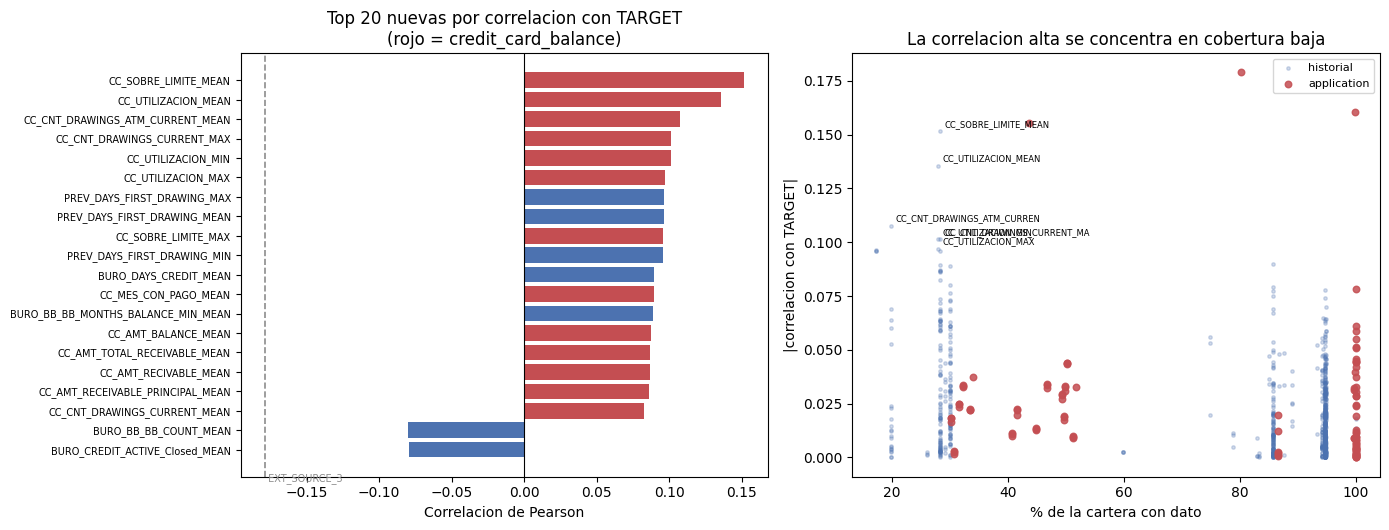

In [42]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5.4))

t = R_NUEVAS.head(20).iloc[::-1]
col = [ROJO if c.startswith('CC_') else AZUL for c in t['Variable']]
ax[0].barh(range(len(t)), t['Corr'], color=col)
ax[0].set_yticks(range(len(t)))
ax[0].set_yticklabels(t['Variable'], fontsize=7)
ax[0].axvline(0, color='k', lw=.8)
ax[0].axvline(R_APP.iloc[0]['Corr'], color=GRIS, ls='--', lw=1.2)
ax[0].text(R_APP.iloc[0]['Corr'], -1.2, ' EXT_SOURCE_3', color=GRIS, fontsize=7, va='top')
ax[0].set(title='Top 20 nuevas por correlacion con TARGET\n(rojo = credit_card_balance)',
          xlabel='Correlacion de Pearson')

ax[1].scatter(R_NUEVAS['Cobertura_%'], R_NUEVAS['Abs'], s=6, alpha=.25, color=AZUL,
              label='historial')
ax[1].scatter(R_APP['Cobertura_%'], R_APP['Abs'], s=22, alpha=.85, color=ROJO,
              label='application')
for _, r in R_NUEVAS.head(6).iterrows():
    ax[1].annotate(r['Variable'][:26], (r['Cobertura_%'], r['Abs']), fontsize=6,
                   xytext=(3, 3), textcoords='offset points')
ax[1].set(title='La correlacion alta se concentra en cobertura baja',
          xlabel='% de la cartera con dato', ylabel='|correlacion con TARGET|')
ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

**Lectura.** El ranking crudo entrega un resultado que no se puede tomar al pie
de la letra, y el panel derecho de la figura explica por qué.

Siete de las diez primeras posiciones corresponden a `credit_card_balance`, y
trece de las veinte; las tres restantes del top 10 son de
`previous_application`. Encabeza la proporción de meses en que la tarjeta estuvo
por encima de su límite, con 0.152, seguida de la utilización media, con 0.136.
La primera se queda a poco de los tres puntajes externos —0.179, 0.161 y 0.155—
y deja atrás a todas las demás variables de `application`, cuya siguiente mejor
es `DAYS_BIRTH` con 0.078. Ninguna de las 782 variables nuevas alcanza el
coeficiente de `EXT_SOURCE_3`.

Pero esas correlaciones están calculadas sobre 86,905 clientes, el 28.3% de la
cartera que posee tarjeta previa, mientras que la de `EXT_SOURCE_2` se calcula
sobre 99.8%. El panel derecho muestra que la relación no es casual: la nube se
inclina, y los coeficientes altos habitan la franja de cobertura baja. Esto es lo
esperable, y no un accidente de estos datos. La subpoblación con tarjeta de
crédito previa es más homogénea que la cartera completa —son clientes con
producto revolvente vigente, cuya tasa de mora es 8.67% frente a 7.84% de los
demás— y dentro de un grupo homogéneo un mismo comportamiento discrimina mejor.
La correlación mide la fuerza de la relación dentro de la población observada, no
el valor de la variable para la cartera.

La consecuencia práctica es que el orden del top 20 no puede sostener ninguna
conclusión sobre si el historial aporta. Una variable presente en 28% de los
clientes no puede compararse con una presente en 100% mediante un estadístico que
ignora esa diferencia. Antes de concluir hay que corregir la distorsión.

## La comparación corregida

Se añaden dos lecturas que sí son comparables entre variables de cobertura
distinta.

La primera es el ranking restringido a las variables presentes en al menos 85% de
la cartera. Es el único contraste legítimo frente a las variables de
`application`, porque ambos conjuntos describen entonces aproximadamente la misma
población.

La segunda es una medida construida sobre la cartera completa, que aquí se llama
**separación**. Cada variable se agrupa en «sin dato» más los quintiles de los
casos con dato; se calcula la tasa de mora de cada grupo; y se promedia su
desviación respecto de la tasa global **ponderando por el tamaño de cada grupo
sobre el total de la cartera**. La ponderación es lo que corrige el sesgo: una
variable ausente en tres cuartas partes de los clientes contribuye con esas tres
cuartas partes al promedio, y no puede aparentar un poder que solo ejerce sobre
la minoría que la posee. La medida se expresa en puntos porcentuales de
desviación de la tasa de mora y trata la ausencia como una categoría más, lo cual
es coherente con haber establecido que la ausencia informa.

In [43]:
ALTA = R_NUEVAS[R_NUEVAS['Cobertura_%'] >= 85].reset_index(drop=True)
print(f'variables nuevas con cobertura >= 85%: {len(ALTA)} de {len(R_NUEVAS)}')
print('\n=== TOP 15 NUEVAS CON COBERTURA >= 85% ===')
print(ALTA.head(15)[MOSTRAR].to_string(index=False, float_format=CUATRO))


def separacion(col):
    """Desviacion media ponderada de la mora por grupo respecto de la global.

    Grupos: 'sin dato' mas quintiles de los casos con dato. Los pesos son
    proporciones sobre la cartera completa, de modo que el resultado es
    comparable entre variables de cobertura distinta.
    """
    x = app[col]
    m = x.notna()
    if m.sum() < 1000:
        return np.nan
    try:
        q = pd.qcut(x[m], 5, duplicates='drop')
        if q.nunique() < 2:
            return np.nan
    except (ValueError, TypeError):
        return np.nan
    g = pd.Series('sin dato', index=app.index, dtype=object)
    g[m] = 'q' + q.cat.codes.astype(str)
    tasa = y.groupby(g).mean()
    peso = g.value_counts(normalize=True)
    return float(100 * (peso * (tasa - GLOBAL).abs()).sum())


CAND = pd.concat([R_NUEVAS.head(60), ALTA.head(40), R_APP.head(20)]).drop_duplicates('Variable')
CAND = CAND.assign(Separacion_pp=[separacion(v) for v in CAND['Variable']]).dropna(
    subset=['Separacion_pp']).sort_values('Separacion_pp', ascending=False).reset_index(drop=True)

print('\n=== TOP 20 POR SEPARACION DE CARTERA (comparable) ===')
print(CAND.head(20)[['Variable', 'Origen', 'Corr', 'Cobertura_%', 'Separacion_pp']]
      .to_string(index=False, float_format=CUATRO))

variables nuevas con cobertura >= 85%: 567 de 784

=== TOP 15 NUEVAS CON COBERTURA >= 85% ===
                               Variable    Corr  Cobertura_%  AUC_orientado
                  BURO_DAYS_CREDIT_MEAN  0.0897      85.7000         0.6030
         BURO_CREDIT_ACTIVE_Closed_MEAN -0.0794      85.7000         0.5861
 PREV_NAME_CONTRACT_STATUS_Refused_MEAN  0.0777      94.6000         0.5602
         BURO_CREDIT_ACTIVE_Active_MEAN  0.0774      85.7000         0.5840
                   BURO_DAYS_CREDIT_MIN  0.0752      85.7000         0.5783
       PREV_CODE_REJECT_REASON_XAP_MEAN -0.0739      94.6000         0.5597
                    INS_PAGO_TARDE_MEAN  0.0700      94.8000         0.5641
           BURO_DAYS_CREDIT_UPDATE_MEAN  0.0689      85.7000         0.5893
          BURO_CREDIT_ACTIVE_Active_SUM  0.0671      85.7000         0.5604
              PREV_RAZON_CONCEDIDO_MEAN  0.0650      94.3000         0.5729
  PREV_NAME_CONTRACT_STATUS_Refused_SUM  0.0645      94.6000         0


=== TOP 20 POR SEPARACION DE CARTERA (comparable) ===
                               Variable      Origen    Corr  Cobertura_%  Separacion_pp
                           EXT_SOURCE_3 application -0.1789      80.2000         3.3806
                           EXT_SOURCE_2 application -0.1605      99.8000         3.2846
                  BURO_DAYS_CREDIT_MEAN   historial  0.0897      85.7000         2.2696
                          DAYS_EMPLOYED application -0.0449     100.0000         2.0853
           BURO_DAYS_CREDIT_UPDATE_MEAN   historial  0.0689      85.7000         2.0037
         BURO_CREDIT_ACTIVE_Active_MEAN   historial  0.0774      85.7000         1.9313
         BURO_CREDIT_ACTIVE_Closed_MEAN   historial -0.0794      85.7000         1.9217
                   BURO_DAYS_CREDIT_MAX   historial  0.0498      85.7000         1.8574
                   BURO_DAYS_CREDIT_MIN   historial  0.0752      85.7000         1.8091
                             DAYS_BIRTH application  0.0782     1

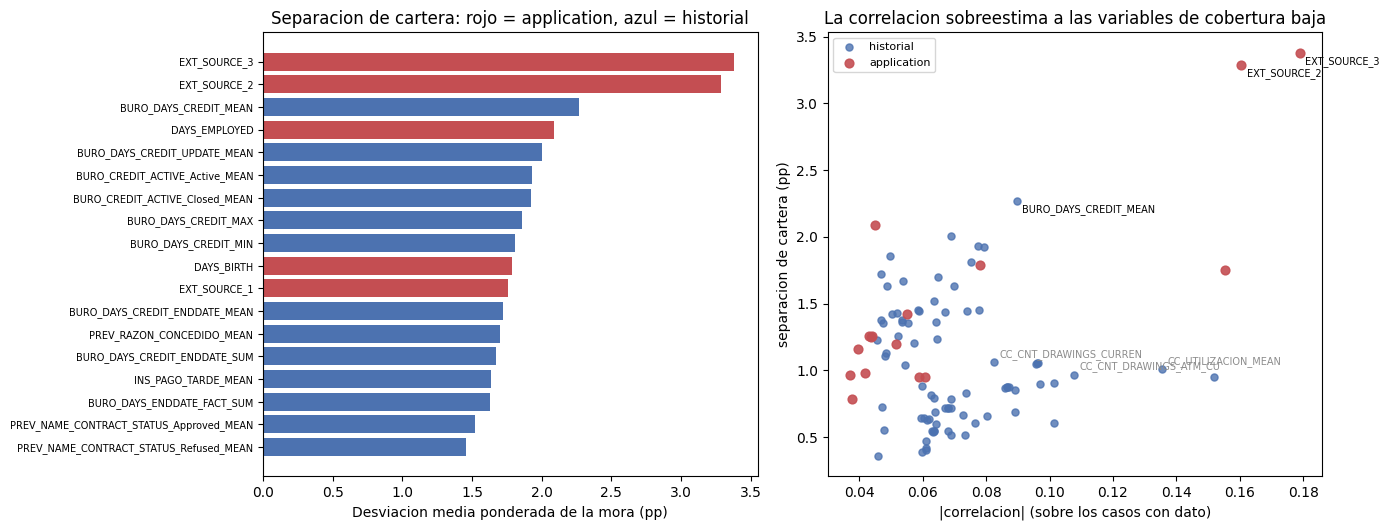

In [44]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5.4))

t = CAND.head(18).iloc[::-1]
col = [ROJO if o == 'application' else AZUL for o in t['Origen']]
ax[0].barh(range(len(t)), t['Separacion_pp'], color=col)
ax[0].set_yticks(range(len(t)))
ax[0].set_yticklabels(t['Variable'], fontsize=7)
ax[0].set(title='Separacion de cartera: rojo = application, azul = historial',
          xlabel='Desviacion media ponderada de la mora (pp)')

r = CAND[CAND['Origen'] == 'historial']
a = CAND[CAND['Origen'] == 'application']
ax[1].scatter(r['Abs'], r['Separacion_pp'], s=26, color=AZUL, alpha=.8, label='historial')
ax[1].scatter(a['Abs'], a['Separacion_pp'], s=40, color=ROJO, alpha=.9, label='application')
for _, q in CAND.head(3).iterrows():
    ax[1].annotate(q['Variable'][:22], (q['Abs'], q['Separacion_pp']), fontsize=7,
                   xytext=(4, -8), textcoords='offset points')
peor = CAND[CAND['Variable'].str.startswith('CC_')].head(3)
for _, q in peor.iterrows():
    ax[1].annotate(q['Variable'][:22], (q['Abs'], q['Separacion_pp']), fontsize=7,
                   color=GRIS, xytext=(4, 4), textcoords='offset points')
ax[1].set(title='La correlacion sobreestima a las variables de cobertura baja',
          xlabel='|correlacion| (sobre los casos con dato)',
          ylabel='separacion de cartera (pp)')
ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

**Lectura.** Corregido el sesgo, el cuadro cambia por completo y se vuelve
interpretable.

Las variables de `credit_card_balance` desaparecen de las primeras posiciones.
`CC_SOBRE_LIMITE_MEAN`, que encabezaba el ranking crudo con 0.152, no figura
entre las veinte primeras por separación: su gradiente es real y pronunciado
—entre el decil más bajo y el más alto la mora pasa de 6.27% a 19.04%, un factor
de 2.4— pero se ejerce sobre el 28% de la cartera que tiene tarjeta, y sobre el
72% restante la variable no dice nada. El panel derecho muestra el
desplazamiento: los puntos grises, todos de `credit_card_balance`, están a la
derecha por correlación y abajo por separación.

Lo que asciende es `bureau`. `BURO_DAYS_CREDIT_MEAN` —la antigüedad media de los
créditos externos del cliente— alcanza 2.27 puntos porcentuales de separación y
queda **tercera del conjunto completo**, por detrás únicamente de `EXT_SOURCE_3`
con 3.38 y `EXT_SOURCE_2` con 3.28, y por delante de todas las demás variables de
`application`: supera a `DAYS_EMPLOYED` con 2.09, a `DAYS_BIRTH` con 1.79 y al
propio `EXT_SOURCE_1` con 1.75, que cae por tener 43.6% de cobertura. Le siguen
otras cinco variables de `bureau` entre 1.81 y 2.00, y después las de
`previous_application` e `installments_payments` en torno a 1.45.

El ranking de cobertura alta cuenta la misma historia con otro estadístico y
añade lo que el negocio reconocería: encabeza `BURO_DAYS_CREDIT_MEAN` con 0.090,
y aparecen en las primeras posiciones la proporción de créditos externos vigentes
frente a cerrados, la proporción de solicitudes previas rechazadas —0.078— y la
proporción de cuotas pagadas con retraso —0.070—. Son exactamente las cuatro
señales que la Fase 2 anticipó al fijar qué resumir de cada tabla: cuánto
historial externo tiene, cuánto de él sigue abierto, si la entidad ya lo rechazó
antes y si paga a tiempo.

Queda un aviso. `PREV_DAYS_FIRST_DRAWING_MAX` aparecía en el puesto siete del
ranking crudo con 0.096, y su cobertura efectiva tras neutralizar el centinela es
17.3%. Es la columna que quedó con 95.5% de nulos. Su correlación describe a un
subgrupo pequeño y definido precisamente por tener un tipo de producto que opera
por disposición; la sección de recencia mostrará que esa correlación no sobrevive
a ningún cambio de ventana.

## Entregable 2 — La cobertura frente al objetivo

El plan pide comparar la tasa de mora de los clientes que tienen historial contra
la de los que no lo tienen, con el argumento de que no tener historial es
información en sí misma. La medición confirma el argumento, pero con un giro que
el plan no anticipaba: **el signo de la señal depende de quién no tiene el
registro.**

In [45]:
filas = []
for pref, col in CENTINELA.items():
    t = app[f'HIST_{pref}'].eq(1)
    filas.append({'Fuente': pref,
                  'Naturaleza': 'externa' if pref.startswith('BURO') else 'interna',
                  'Cobertura_%': round(100 * t.mean(), 1),
                  'N_con': int(t.sum()), 'N_sin': int((~t).sum()),
                  'Mora_con_%': round(100 * y[t].mean(), 2),
                  'Mora_sin_%': round(100 * y[~t].mean(), 2)})
COB = pd.DataFrame(filas)
COB['Dif_pp'] = (COB['Mora_sin_%'] - COB['Mora_con_%']).round(2)
COB['Razon'] = (COB['Mora_sin_%'] / COB['Mora_con_%']).round(2)
print(f'Tasa de mora global: {100*GLOBAL:.2f}%\n')
print(COB.to_string(index=False))

FUENTES = pd.DataFrame({'Clientes': app.groupby('HIST_N_FUENTES').size(),
                        'Mora_%': (100 * y.groupby(app['HIST_N_FUENTES']).mean()).round(2)})
FUENTES['Pct_cartera'] = (100 * FUENTES['Clientes'] / len(app)).round(1)
print('\n=== MORA SEGUN CUANTAS DE LAS SEIS FUENTES TIENE EL CLIENTE ===')
print(FUENTES.to_string())

Tasa de mora global: 8.07%

 Fuente Naturaleza  Cobertura_%  N_con  N_sin  Mora_con_%  Mora_sin_%  Dif_pp  Razon
   BURO    externa        85.70 263491  44020        7.73       10.12    2.39   1.31
BURO_BB    externa        30.00  92231 215280        8.14        8.04   -0.10   0.99
   PREV    interna        94.60 291057  16454        8.19        5.96   -2.23   0.73
    POS    interna        94.10 289444  18067        8.16        6.66   -1.50   0.82
    INS    interna        94.80 291643  15868        8.19        5.98   -2.21   0.73
     CC    interna        28.30  86905 220606        8.67        7.84   -0.83   0.90

=== MORA SEGUN CUANTAS DE LAS SEIS FUENTES TIENE EL CLIENTE ===
                Clientes  Mora_%  Pct_cartera
HIST_N_FUENTES                               
0                   2200    7.14         0.70
1                   9565    5.53         3.10
2                   3742    6.12         1.20
3                  31429   10.34        10.20
4                 128371    7.58    

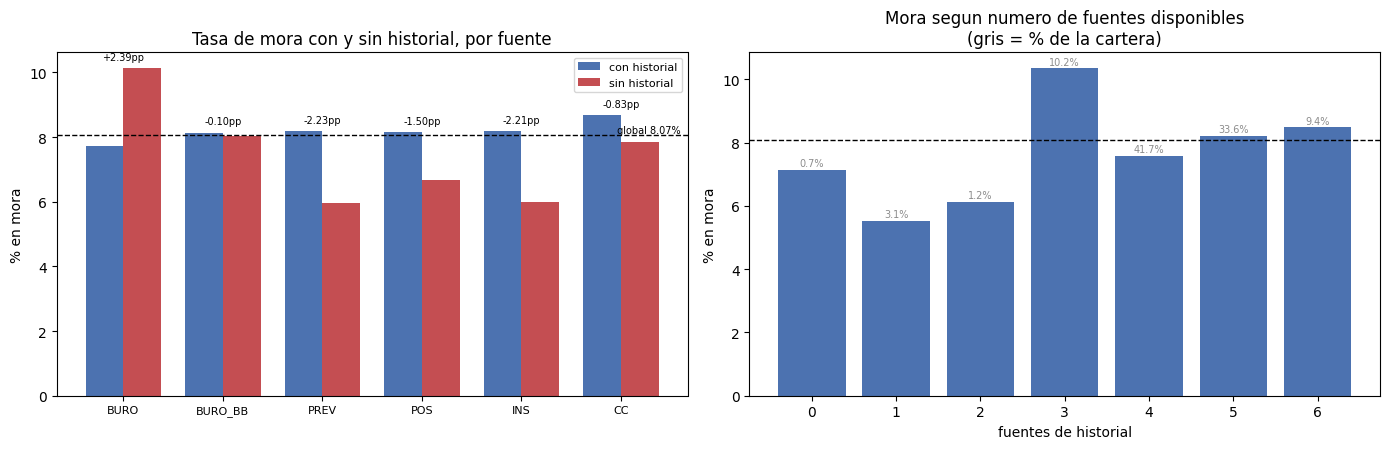

In [46]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.6))

x = np.arange(len(COB)); w = .38
ax[0].bar(x - w/2, COB['Mora_con_%'], w, color=AZUL, label='con historial')
ax[0].bar(x + w/2, COB['Mora_sin_%'], w, color=ROJO, label='sin historial')
ax[0].axhline(100*GLOBAL, color='k', ls='--', lw=1)
ax[0].text(len(COB)-.4, 100*GLOBAL, f' global {100*GLOBAL:.2f}%', fontsize=7, va='bottom', ha='right')
ax[0].set_xticks(x); ax[0].set_xticklabels(COB['Fuente'], fontsize=8)
for i, r in COB.iterrows():
    ax[0].text(i, max(r['Mora_con_%'], r['Mora_sin_%']) + .25,
               f"{r['Dif_pp']:+.2f}pp", ha='center', fontsize=7)
ax[0].set(title='Tasa de mora con y sin historial, por fuente', ylabel='% en mora')
ax[0].legend(fontsize=8)

ax[1].bar(FUENTES.index.astype(str), FUENTES['Mora_%'], color=AZUL)
ax[1].axhline(100*GLOBAL, color='k', ls='--', lw=1)
for i, (k, r) in enumerate(FUENTES.iterrows()):
    ax[1].text(i, r['Mora_%'] + .12, f"{r['Pct_cartera']}%", ha='center', fontsize=7, color=GRIS)
ax[1].set(title='Mora segun numero de fuentes disponibles\n(gris = % de la cartera)',
          xlabel='fuentes de historial', ylabel='% en mora')
plt.tight_layout(); plt.show()

**Lectura.** La ausencia de historial informa, y lo hace en dos direcciones
opuestas según su origen.

Cuando falta el registro **externo**, el riesgo sube. Los 44,020 solicitantes sin
ningún crédito en la central de riesgo incumplen en 10.12% frente a 7.73% de los
263,491 que sí figuran: 2.39 puntos porcentuales más, un riesgo 1.31 veces
mayor. La lectura es la habitual en el negocio: quien no tiene rastro en el
sistema financiero no ha demostrado que pague, y el segmento de expediente
delgado es notoriamente más riesgoso.

Cuando falta el historial **interno**, el riesgo baja. Los 16,454 solicitantes
sin ninguna solicitud previa ante Home Credit incumplen en 5.96% frente a 8.19%
de quienes ya habían solicitado; el patrón se repite en `installments_payments`
—5.98% contra 8.19%— y en `POS_CASH_balance` —6.66% contra 8.16%—. La dirección
es contraria y la explicación también: el cliente nuevo no es un desconocido sino
un solicitante recién filtrado, que llega por un canal distinto y supera un
escrutinio que el cliente recurrente ya no atraviesa. La cartera repetida, en
cambio, acumula a quienes vuelven porque necesitan volver.

Confundir ambas ausencias bajo un mismo tratamiento —imputar la media, o marcar
un único indicador de «sin historial»— cancelaría dos señales de signo contrario
y de magnitud comparable. Es el hallazgo de esta sección y tiene consecuencia
directa sobre el modelado: los seis indicadores deben entrar por separado.

Dos observaciones más. La disponibilidad de `bureau_balance` no informa en
absoluto —8.14% con historial mensual contra 8.04% sin él, diferencia de 0.10
puntos— y esto tiene sentido: que una central de riesgo haya reportado el detalle
mensual de un crédito es un atributo del proceso de reporte, no del cliente. Es
la única de las seis cuya ausencia es puramente técnica, y confirma que la
distinción entre ausencia informativa y vacío administrativo debe hacerse fuente
por fuente y no por regla general.

Y el número de fuentes disponibles no forma una escalera de riesgo: la mora va de
7.14% con cero fuentes a 5.53% con una, sube a 10.34% con tres, baja a 7.58% con
cuatro y vuelve a subir a 8.48% con seis. El máximo está en el grupo de tres
fuentes, que reúne 10.2% de la cartera. La no monotonía descarta usar el conteo
como índice de solvencia; lo que importa es **cuáles** fuentes faltan, no
**cuántas**.

## ¿Información nueva o la misma por otra vía?

Correlacionar con `TARGET` establece que una variable sirve, no que aporte algo
que no estuviera ya disponible. La pregunta del Nivel 3 es la segunda, y exige
medir cuánto de lo que dice el historial está ya contenido en las variables de
`application` —señaladamente en los tres puntajes externos, que son puntajes de
crédito construidos por terceros y por tanto los candidatos naturales a
contener historial resumido.

Se mide también la redundancia interna. Con 782 variables generadas por un
contrato mecánico, cabe esperar que muchas sean la misma cosa escrita dos veces.

In [47]:
EXT = [c for c in ('EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3') if c in app.columns]
top = CAND[CAND['Origen'] == 'historial'].head(10)['Variable'].tolist()
RED = app[top + EXT].corr().loc[top, EXT]
RED['Max_abs_EXT'] = RED.abs().max(axis=1)
RED = RED.join(CAND.set_index('Variable')[['Corr', 'Separacion_pp']])
print('=== LAS 10 MEJORES DEL HISTORIAL FRENTE A LOS PUNTAJES EXTERNOS ===')
print(RED.to_string(float_format=CUATRO))

top40 = R_NUEVAS.head(40)['Variable'].tolist()
C = app[top40].corr().abs()
# Aqui habia dos errores encadenados.
#
# 1) `np.fill_diagonal(C.values, 0)` abortaba la celda con "ValueError: underlying
#    array is read-only": con copy-on-write `.values` entrega una vista de solo
#    lectura del bloque interno. Ademas sobraba, porque `triu(k=1)` ya deja la
#    diagonal fuera del triangulo que se recorre.
# 2) `.stack()` ya no descarta las celdas nulas, de modo que devolvia las 1,600
#    casillas de la matriz 40x40 -- diagonal y triangulo inferior incluidos como
#    NA -- en lugar de los 780 pares reales. El conteo 'de N posibles' salia por
#    encima del doble. `.dropna()` restituye el triangulo superior.
pares = (C.where(np.triu(np.ones(C.shape), 1).astype(bool))
          .stack().dropna().sort_values(ascending=False))
dup = pares[pares > 0.95]
print(f'\n=== REDUNDANCIA INTERNA: pares con |r| > 0.95 en el top 40: '
      f'{len(dup)} de {len(pares)} ===')
print(dup.head(8).to_string(float_format=CUATRO))

mejor = CAND[CAND['Origen'] == 'historial'].iloc[0]['Variable']
q = pd.qcut(app[mejor], 10, duplicates='drop')
LIFT = pd.DataFrame({'Clientes': app.groupby(q, observed=True).size(),
                     'Mora_%': (100 * y.groupby(q, observed=True).mean()).round(2)})
LIFT['Lift'] = (LIFT['Mora_%'] / (100*GLOBAL)).round(2)
print(f'\n=== MORA POR DECIL DE {mejor} ===')
print(LIFT.to_string())

=== LAS 10 MEJORES DEL HISTORIAL FRENTE A LOS PUNTAJES EXTERNOS ===
                                EXT_SOURCE_1  EXT_SOURCE_2  EXT_SOURCE_3  Max_abs_EXT    Corr  Separacion_pp
BURO_DAYS_CREDIT_MEAN                -0.2018       -0.1032       -0.4018       0.4018  0.0897         2.2696
BURO_DAYS_CREDIT_UPDATE_MEAN         -0.1467       -0.0516       -0.3347       0.3347  0.0689         2.0037
BURO_CREDIT_ACTIVE_Active_MEAN       -0.0953       -0.0413       -0.3575       0.3575  0.0774         1.9313
BURO_CREDIT_ACTIVE_Closed_MEAN        0.0949        0.0423        0.3612       0.3612 -0.0794         1.9217
BURO_DAYS_CREDIT_MAX                 -0.0708       -0.0454       -0.3902       0.3902  0.0498         1.8574
BURO_DAYS_CREDIT_MIN                 -0.2199       -0.1014       -0.2263       0.2263  0.0752         1.8091
BURO_DAYS_CREDIT_ENDDATE_MEAN        -0.0898       -0.0157       -0.1978       0.1978  0.0470         1.7203
PREV_RAZON_CONCEDIDO_MEAN            -0.0542       -0.0675  


=== REDUNDANCIA INTERNA: pares con |r| > 0.95 en el top 40: 23 de 780 ===
CC_AMT_TOTAL_RECEIVABLE_MEAN  CC_AMT_RECIVABLE_MEAN              1.0000
CC_AMT_TOTAL_RECEIVABLE_MAX   CC_AMT_RECIVABLE_MAX               1.0000
CC_AMT_BALANCE_MEAN           CC_AMT_RECIVABLE_MEAN              1.0000
                              CC_AMT_TOTAL_RECEIVABLE_MEAN       1.0000
CC_AMT_BALANCE_MAX            CC_AMT_RECIVABLE_MAX               0.9999
                              CC_AMT_TOTAL_RECEIVABLE_MAX        0.9999
CC_AMT_RECIVABLE_MEAN         CC_AMT_RECEIVABLE_PRINCIPAL_MEAN   0.9999
CC_AMT_TOTAL_RECEIVABLE_MEAN  CC_AMT_RECEIVABLE_PRINCIPAL_MEAN   0.9999

=== MORA POR DECIL DE BURO_DAYS_CREDIT_MEAN ===
                       Clientes  Mora_%  Lift
BURO_DAYS_CREDIT_MEAN                        
(-2922.001, -1808.0]      26367    5.10  0.63
(-1808.0, -1529.5]        26340    4.97  0.62
(-1529.5, -1349.0]        26363    5.46  0.68
(-1349.0, -1195.0]        26362    5.90  0.73
(-1195.0, -1050.571]    

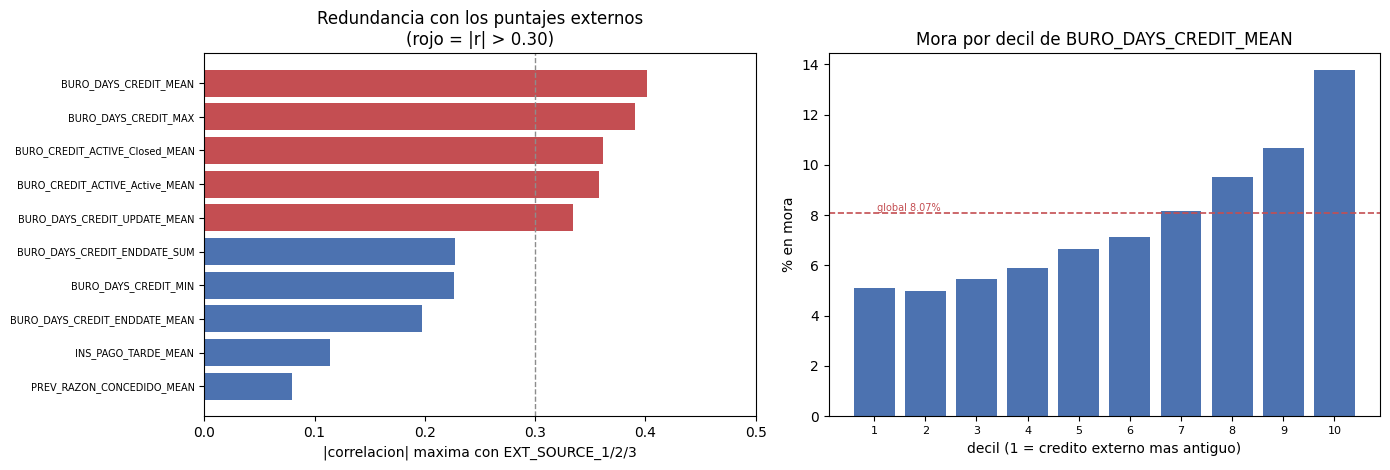

In [48]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.8))

t = RED.sort_values('Max_abs_EXT')
ax[0].barh(range(len(t)), t['Max_abs_EXT'], color=[
    ROJO if v > .3 else AZUL for v in t['Max_abs_EXT']])
ax[0].set_yticks(range(len(t))); ax[0].set_yticklabels(t.index, fontsize=7)
ax[0].axvline(.3, color=GRIS, ls='--', lw=1)
ax[0].set(title='Redundancia con los puntajes externos\n(rojo = |r| > 0.30)',
          xlabel='|correlacion| maxima con EXT_SOURCE_1/2/3', xlim=(0, .5))

ax[1].bar(range(len(LIFT)), LIFT['Mora_%'], color=AZUL)
ax[1].axhline(100*GLOBAL, color=ROJO, ls='--', lw=1.2)
ax[1].text(0, 100*GLOBAL, f' global {100*GLOBAL:.2f}%', fontsize=7, va='bottom', color=ROJO)
ax[1].set_xticks(range(len(LIFT)))
ax[1].set_xticklabels([f'{i+1}' for i in range(len(LIFT))], fontsize=8)
ax[1].set(title=f'Mora por decil de {mejor}', xlabel='decil (1 = credito externo mas antiguo)',
          ylabel='% en mora')
plt.tight_layout(); plt.show()

**Lectura.** La redundancia existe y no está repartida por igual, lo que permite
una respuesta más útil que un sí o un no.

Las dos mejores variables del historial son en buena medida información que ya
estaba. `BURO_DAYS_CREDIT_MEAN` correlaciona −0.402 con `EXT_SOURCE_3` y
`BURO_BB_BB_MONTHS_BALANCE_MIN_MEAN` lo hace en −0.401. Que la antigüedad del
historial externo esté fuertemente asociada al puntaje externo es coherente con
lo que un puntaje de crédito es: la profundidad del expediente es uno de sus
insumos clásicos. Nuestra mejor variable nueva reconstruye, con menos precisión,
algo que `EXT_SOURCE_3` ya resumía.

Las de `credit_card_balance`, en cambio, son sustancialmente independientes:
`CC_SOBRE_LIMITE_MEAN` y `CC_UTILIZACION_MEAN` no pasan de 0.195 con ningún
puntaje externo. La tensión de liquidez en el producto revolvente es información
genuinamente nueva. Su limitación no es la redundancia sino la cobertura, y el
diagnóstico correcto de estas variables es por tanto el inverso del de las de
`bureau`: dicen algo que nadie más dice, pero solo sobre poco más de una cuarta
parte de la cartera.

La redundancia interna es alta y era previsible. Entre las 40 primeras variables
nuevas hay 23 pares con correlación absoluta superior a 0.95 de 780 posibles, y
varios son de 1.000 exacto: `CC_AMT_BALANCE`, `CC_AMT_RECIVABLE`,
`CC_AMT_TOTAL_RECEIVABLE` y `CC_AMT_RECEIVABLE_PRINCIPAL` son la misma columna
cuatro veces. El caso que merece registro es
`BURO_DAYS_CREDIT_MEAN` con `BURO_BB_BB_MONTHS_BALANCE_MIN_MEAN`: correlación
1.000. El mes más antiguo observado de un crédito en el historial mensual es la
fecha en que ese crédito se abrió, que es lo que `DAYS_CREDIT` ya registraba en
`bureau`. La variable mejor posicionada de las 117 que produjo el encadenamiento
en dos pasos —el procedimiento más costoso de esta fase, sobre la tabla de 27.3
millones de filas— es una reexpresión exacta de una columna que ya teníamos. El
resultado no invalida la tabla, cuyas proporciones de estado sí son propias, pero
sí redimensiona lo que puede esperarse de ella.

El gradiente de la mejor variable es limpio y va en la dirección esperada. Por
deciles de antigüedad media del crédito externo la mora va de 4.97% a 13.76%, un
factor 2.8 entre extremos, y crece de forma estrictamente monótona desde el tercer
decil en adelante; los dos primeros —los clientes cuyos créditos externos son más
antiguos— quedan prácticamente empatados en torno a 5%. Cuanto más reciente es el
crédito externo, mayor es el riesgo, y el efecto se mide sobre 85.7% de la
cartera, no sobre un nicho.

## Entregable 3 — La ventana completa contra los últimos doce meses

La Fase 2 dejó planteada esta comparación con un argumento concreto: las seis
tablas se detienen exactamente en ocho años, y un promedio calculado sobre esa
ventana pondera igual el mes anterior a la solicitud y el de hace ocho años.
Dos series mostraban además que el pasado remoto tiene más mora que el reciente
—en `bureau_balance` la proporción de meses en mora cae de 2.2% a 0.9%, y en
`installments_payments` la proporción de cuotas tardías baja de 11.5% siete años
atrás a 6.2% en el último año—, de modo que la ventana completa mezcla dos
regímenes distintos.

Se reagrega por tanto cada tabla restringida al año previo a la solicitud
—`DAYS_* >= -365` en las fechadas, `MONTHS_BALANCE >= -12` en las mensuales— y se
compara variable por variable la correlación con `TARGET` contra su gemela de
ventana completa.

In [49]:
VENTANA = {'bureau': ('DAYS_CREDIT', -365, 'BURO'),
           'previous_application': ('DAYS_DECISION', -365, 'PREV'),
           'installments_payments': ('DAYS_INSTALMENT', -365, 'INS'),
           'POS_CASH_balance': ('MONTHS_BALANCE', -12, 'POS'),
           'credit_card_balance': ('MONTHS_BALANCE', -12, 'CC')}

DERIVAR = {
    'bureau': lambda d: d.assign(
        DEUDA_REL=(d['AMT_CREDIT_SUM_DEBT'] / d['AMT_CREDIT_SUM'].replace(0, np.nan)
                   ).replace([np.inf, -np.inf], np.nan),
        OVERDUE_NA=d['AMT_CREDIT_MAX_OVERDUE'].isnull().astype('int8'),
        ANNUITY_NA=d['AMT_ANNUITY'].isnull().astype('int8')).drop(columns=['CREDIT_CURRENCY']),
    'previous_application': lambda d: d.assign(**{
        c: d[c].replace(365243, np.nan) for c in
        ['DAYS_FIRST_DRAWING', 'DAYS_FIRST_DUE', 'DAYS_LAST_DUE_1ST_VERSION',
         'DAYS_LAST_DUE', 'DAYS_TERMINATION']}).assign(
        RAZON_CONCEDIDO=(d['AMT_CREDIT'] / d['AMT_APPLICATION'].replace(0, np.nan)
                         ).replace([np.inf, -np.inf], np.nan)).drop(
        columns=['RATE_INTEREST_PRIMARY', 'RATE_INTEREST_PRIVILEGED']),
    'installments_payments': lambda d: d.assign(
        RETRASO=d['DAYS_ENTRY_PAYMENT'] - d['DAYS_INSTALMENT'],
        COBERTURA=(d['AMT_PAYMENT'] / d['AMT_INSTALMENT'].replace(0, np.nan)
                   ).replace([np.inf, -np.inf], np.nan),
        FALTANTE=d['AMT_INSTALMENT'] - d['AMT_PAYMENT']).assign(
        PAGO_TARDE=lambda z: z['RETRASO'].gt(0).astype('int8'),
        PAGO_PARCIAL=lambda z: z['COBERTURA'].lt(0.999).astype('int8')),
    'POS_CASH_balance': lambda d: d.assign(
        CON_ATRASO=d['SK_DPD'].gt(0).astype('int8'),
        CON_ATRASO_DEF=d['SK_DPD_DEF'].gt(0).astype('int8')),
    'credit_card_balance': lambda d: d.assign(
        UTILIZACION=(d['AMT_BALANCE'] / d['AMT_CREDIT_LIMIT_ACTUAL'].replace(0, np.nan)
                     ).replace([np.inf, -np.inf], np.nan)).assign(
        SOBRE_LIMITE=lambda z: z['UTILIZACION'].gt(1).astype('int8'),
        MES_CON_PAGO=d['AMT_PAYMENT_TOTAL_CURRENT'].gt(0).astype('int8'),
        CON_ATRASO=d['SK_DPD'].gt(0).astype('int8')),
}

OBJ = app[['SK_ID_CURR', 'TARGET']].copy()
CORR_TOT = R_NUEVAS.set_index('Variable')['Corr']

comp, res = [], []
for tabla, (col, corte, pref) in VENTANA.items():
    d = DERIVAR[tabla](cargar(tabla))
    n_todo = len(d)
    d = d[d[col] >= corte]
    pct = round(100 * len(d) / n_todo, 1)

    rec = resumir(d, 'SK_ID_CURR', pref)
    del d; gc.collect()
    m = unir(OBJ.copy(), rec, 'SK_ID_CURR')
    num = [c for c in rec.columns if c != 'SK_ID_CURR' and pd.api.types.is_numeric_dtype(m[c])]
    j = pd.DataFrame({'Corr_rec': m[num].corrwith(m['TARGET']),
                      'N_rec': m[num].notna().sum()})
    del m, rec; gc.collect()

    j = j.join(CORR_TOT.rename('Corr_tot'), how='inner').dropna()
    j = j[j['N_rec'] > 5000]
    j['Abs_tot'], j['Abs_rec'] = j['Corr_tot'].abs(), j['Corr_rec'].abs()
    j['Gana_rec'] = j['Abs_rec'] > j['Abs_tot']
    j['Tabla'] = tabla
    comp.append(j)
    res.append({'Tabla': tabla, 'Filas_en_ventana_%': pct, 'Vars': len(j),
                'Gana_reciente_%': round(100 * j['Gana_rec'].mean(), 1),
                'Media_abs_total': round(j['Abs_tot'].mean(), 4),
                'Media_abs_reciente': round(j['Abs_rec'].mean(), 4),
                'Max_abs_total': round(j['Abs_tot'].max(), 4),
                'Max_abs_reciente': round(j['Abs_rec'].max(), 4)})
    print(f'{tabla}: {pct}% de las filas en la ventana, '
          f'gana la reciente en {res[-1]["Gana_reciente_%"]}% de {len(j)} variables')

COMP = pd.concat(comp)
RES = pd.DataFrame(res)
print('\n=== VENTANA COMPLETA CONTRA ULTIMOS 12 MESES ===')
print(RES.to_string(index=False, float_format=CUATRO))

COMP['Ganancia'] = COMP['Abs_rec'] - COMP['Abs_tot']
print('\n=== DONDE MAS GANA LA VENTANA RECIENTE ===')
print(COMP.nlargest(10, 'Ganancia')[['Tabla', 'Corr_tot', 'Corr_rec', 'Ganancia']]
      .to_string(float_format=CUATRO))
print('\n=== DONDE MAS PIERDE ===')
print(COMP.nsmallest(8, 'Ganancia')[['Tabla', 'Corr_tot', 'Corr_rec', 'Ganancia']]
      .to_string(float_format=CUATRO))

bureau: 1,716,428 filas x 17 columnas | 138 MB en memoria


bureau: 18.9% de las filas en la ventana, gana la reciente en 62.9% de 89 variables
previous_application: 1,670,214 filas x 37 columnas | 242 MB en memoria


previous_application: 34.4% de las filas en la ventana, gana la reciente en 40.1% de 352 variables


installments_payments: 13,605,401 filas x 8 columnas | 649 MB en memoria


installments_payments: 25.3% de las filas en la ventana, gana la reciente en 55.6% de 45 variables
POS_CASH_balance: 10,001,358 filas x 8 columnas | 286 MB en memoria


POS_CASH_balance: 23.4% de las filas en la ventana, gana la reciente en 60.0% de 45 variables


credit_card_balance: 3,840,312 filas x 23 columnas | 513 MB en memoria


credit_card_balance: 27.8% de las filas en la ventana, gana la reciente en 57.8% de 102 variables

=== VENTANA COMPLETA CONTRA ULTIMOS 12 MESES ===
                Tabla  Filas_en_ventana_%  Vars  Gana_reciente_%  Media_abs_total  Media_abs_reciente  Max_abs_total  Max_abs_reciente
               bureau             18.9000    89          62.9000           0.0188              0.0208         0.0897            0.0923
 previous_application             34.4000   352          40.1000           0.0172              0.0146         0.0962            0.0788
installments_payments             25.3000    45          55.6000           0.0239              0.0255         0.0700            0.0848
     POS_CASH_balance             23.4000    45          60.0000           0.0150              0.0149         0.0553            0.0537
  credit_card_balance             27.8000   102          57.8000           0.0363              0.0454         0.1517            0.1537

=== DONDE MAS GANA LA VENTANA RECIENTE ==

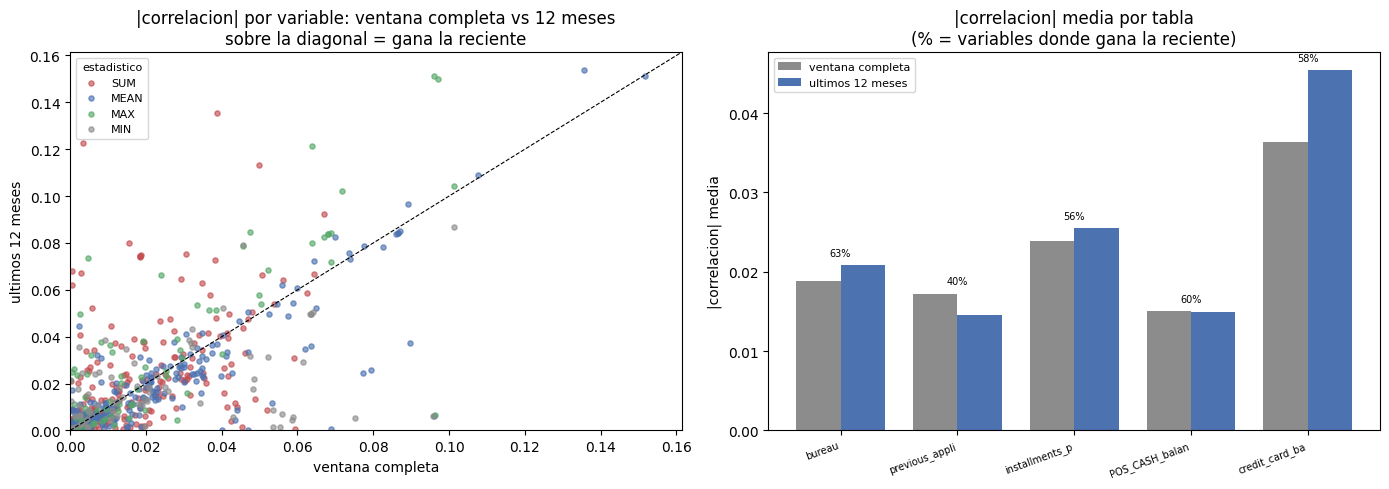

In [50]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5.0))

est = COMP.index.to_series().str.rsplit('_', n=1).str[-1]
esq = {'SUM': ROJO, 'MEAN': AZUL, 'MAX': VERDE, 'MIN': GRIS}
for e, c in esq.items():
    s = COMP[est.values == e]
    ax[0].scatter(s['Abs_tot'], s['Abs_rec'], s=14, alpha=.65, color=c, label=e)
# con `COMP` vacio -- el filtro `N_rec > 5000` de la celda anterior puede dejarla
# asi sobre cualquier muestra pequena -- `max` devolvia NaN y matplotlib abortaba
# con "Axis limits cannot be NaN or Inf".
_top = np.nanmax([COMP['Abs_tot'].max(), COMP['Abs_rec'].max()]) if len(COMP) else np.nan
lim = float(_top) * 1.05 if np.isfinite(_top) else 1.0
ax[0].plot([0, lim], [0, lim], color='k', lw=.8, ls='--')
ax[0].set(title='|correlacion| por variable: ventana completa vs 12 meses\n'
                'sobre la diagonal = gana la reciente',
          xlabel='ventana completa', ylabel='ultimos 12 meses', xlim=(0, lim), ylim=(0, lim))
ax[0].legend(fontsize=8, title='estadistico', title_fontsize=8)

x = np.arange(len(RES)); w = .38
ax[1].bar(x - w/2, RES['Media_abs_total'], w, color=GRIS, label='ventana completa')
ax[1].bar(x + w/2, RES['Media_abs_reciente'], w, color=AZUL, label='ultimos 12 meses')
ax[1].set_xticks(x)
ax[1].set_xticklabels([t[:14] for t in RES['Tabla']], fontsize=7, rotation=20, ha='right')
for i, r in RES.iterrows():
    ax[1].text(i, max(r['Media_abs_total'], r['Media_abs_reciente']) + .0012,
               f"{r['Gana_reciente_%']:.0f}%", ha='center', fontsize=7)
ax[1].set(title='|correlacion| media por tabla\n(% = variables donde gana la reciente)',
          ylabel='|correlacion| media')
ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

**Lectura.** La ventana reciente gana en cuatro de las cinco tablas, pero el
resultado agregado es modesto y lo interesante está en el mecanismo, que el panel
izquierdo hace visible al separar por estadístico.

En proporción de variables que mejoran, `bureau` alcanza 62.9%,
`POS_CASH_balance` 60.0%, `credit_card_balance` 57.8% e
`installments_payments` 55.6%; solo `previous_application` retrocede, con 40.1%.
En correlación media el cambio es pequeño —`credit_card_balance` sube de 0.0363 a
0.0454 e `installments_payments` de 0.0239 a 0.0255— de modo que quien esperara
un salto general no lo encuentra. La respuesta correcta no es «gana lo reciente»
sino que **el efecto de la ventana depende de qué mide la variable**, y se separa
con nitidez en dos grupos.

Las que ganan son las sumas, en rojo y desplazadas sobre la diagonal.
`CC_UTILIZACION_SUM` pasa de 0.0035 a 0.1228, `CC_SOBRE_LIMITE_SUM` de 0.0389 a
0.1356, `BURO_COUNT` de 0.0041 a 0.0817 e `INS_RETRASO_MAX` de 0.0047 a 0.0736.
La razón es que una suma sobre una ventana de longitud variable no es
interpretable: mide sobre todo cuántos meses lleva el cliente observado, y la
antigüedad del panel domina la señal de comportamiento. Fijar la ventana en doce
meses vuelve el denominador común y convierte la suma en una tasa comparable
entre clientes. El caso de `BURO_COUNT` es el más claro en términos de negocio:
el total de créditos externos que alguien ha tenido en ocho años dice poco
—0.004—, mientras que cuántos abrió en el último año dice bastante —0.082—.
Abrir créditos deprisa es señal; haberlos tenido, no.

Las que pierden son las que miden profundidad de historial, y su caída es
mecánica. `BURO_DAYS_CREDIT_MIN` pasa de 0.0752 a 0.0052 y
`POS_MONTHS_BALANCE_MIN` de 0.0553 a 0.0015: truncar la ventana a doce meses hace
que el mínimo de una fecha valga aproximadamente −365 para todos, y la variable
deja de variar. Preguntar «hace cuánto empezó» sobre una ventana de un año es una
pregunta sin contenido.

El caso de `previous_application` combina ambos efectos y explica su retroceso.
Sus columnas informativas son fechas de eventos del contrato, es decir medidas de
profundidad, y la restricción las degrada en bloque. Aquí queda además resuelto el
aviso pendiente: `PREV_DAYS_FIRST_DRAWING_MEAN` pasa de 0.0961 a −0.0063 y su
número de casos con dato cae de 53,352 a 15,466. Su correlación no reflejaba
comportamiento de pago sino antigüedad de un subgrupo pequeño, y no sobrevive al
cambio de ventana. Debe descartarse.

La conclusión operativa para el modelado es una regla, no una preferencia: las
variables de intensidad —conteos, sumas, tasas de incidencia— deben calcularse
sobre ventana fija; las de profundidad —mínimos y máximos de fechas— sobre la
ventana completa. Calcular ambos conjuntos y quedarse con lo mejor de cada uno
domina a cualquiera de las dos agregaciones por separado.

## La conclusión del proyecto

**¿El historial crediticio aporta información que `application` no tenía?**
Sí, pero menos de lo que el trabajo invertido haría esperar, y de manera muy
desigual entre las seis tablas. Las cifras que sostienen la respuesta:

**El procedimiento es correcto.** Las 307,511 filas de `application_train` y las
48,744 de `application_test` se conservan intactas tras las seis uniones, de modo
que cada resumen produce efectivamente una fila por solicitante en las dos
particiones. Se añadieron 782 variables de historial y
7 indicadores de disponibilidad. El encadenamiento en dos pasos de
`bureau_balance` pierde 43,041 créditos huérfanos —5.27%— y deja sin historial
mensual a 942,074 de los 1,716,428 créditos externos —54.9%—, cifras verificadas
y no supuestas.

**No hay reemplazo de los puntajes externos.** Ninguna de las 782 variables
nuevas alcanza la correlación de `EXT_SOURCE_3` —0.179— ni la de `EXT_SOURCE_2`
—0.161—. Medida en separación de cartera, la mejor variable del historial,
`BURO_DAYS_CREDIT_MEAN`, alcanza 2.27 puntos porcentuales frente a 3.38 y 3.28 de
esos dos puntajes. El historial complementa; no sustituye.

**Sí hay aporte, y es de tercer lugar, no marginal.** Esa misma variable queda
tercera del conjunto completo, por delante de todas las demás variables de
`application`: supera a `DAYS_EMPLOYED` —2.09—, a `DAYS_BIRTH` —1.79— y a
`EXT_SOURCE_1` —1.75—. Cinco variables más de `bureau` se sitúan entre 1.81 y
2.00. Por deciles, la antigüedad media del crédito externo separa la mora de
4.97% a 13.76%, un factor 2.8 sobre 85.7% de la cartera.

**El aporte está concentrado en `bureau`, y las tablas se ordenan por utilidad.**
`bureau` domina el ranking corregido; le siguen `previous_application` e
`installments_payments` con la proporción de solicitudes rechazadas —0.078— y de
cuotas pagadas con retraso —0.070—; `POS_CASH_balance` aporta poco;
`credit_card_balance` aporta información genuinamente nueva pero solo sobre 28.3%
de la cartera; y `bureau_balance`, la tabla más costosa del proyecto con 27.3
millones de filas, es la que menos rinde por dos motivos independientes: su
variable mejor posicionada correlaciona 1.000 con una columna que `bureau` ya
contenía, y su cobertura no es estable entre particiones.

**Lo nuevo y lo redundante están repartidos al revés de lo que sugiere el
ranking.** Las mejores variables del historial son las más redundantes:
`BURO_DAYS_CREDIT_MEAN` correlaciona −0.402 con `EXT_SOURCE_3`, lo cual es
coherente con que un puntaje de crédito incorpore la profundidad del expediente.
Las de tarjeta, en cambio, no pasan de 0.195 con ningún puntaje externo: son la
información más original del conjunto y su límite es la cobertura, no la
redundancia.

**La ausencia de historial informa, y en dos direcciones opuestas.** Sin registro
externo el riesgo sube: 10.12% de mora contra 7.73%, un factor 1.31. Sin
historial interno el riesgo baja: 5.96% contra 8.19% en `previous_application`,
5.98% contra 8.19% en `installments_payments`. El cliente invisible para la
central de riesgo es un expediente delgado; el cliente nuevo para la entidad es
un solicitante recién filtrado. Los seis indicadores deben entrar por separado al
modelo: un único indicador de «sin historial» cancelaría dos señales de signo
contrario. La excepción es `bureau_balance`, cuya disponibilidad no informa
—8.14% contra 8.04%— porque depende del proceso de reporte y no del cliente. Y el
número de fuentes disponibles no es una escalera de riesgo: la mora es no
monótona en él, con máximo de 10.34% en los clientes con tres fuentes.

**La recencia importa, pero por una razón distinta de la esperada.** No es que el
comportamiento reciente prediga mejor en general: la correlación media apenas se
mueve. Es que las sumas sobre ventana variable están contaminadas por la
antigüedad del panel, y fijar la ventana las repara —`CC_UTILIZACION_SUM` pasa de
0.0035 a 0.1228, `BURO_COUNT` de 0.0041 a 0.0817—, mientras que las variables de
profundidad se destruyen al truncarlas —`BURO_DAYS_CREDIT_MIN` pasa de 0.0752 a
0.0052—. La regla resultante es calcular las de intensidad sobre ventana fija y
las de profundidad sobre la completa.

**Advertencia metodológica que se lleva el proyecto.** El ranking por correlación
que el plan pide como entregable es engañoso cuando las coberturas difieren, y en
estos datos van de 28.3% a 94.8%. Nueve de las diez primeras posiciones del
ranking crudo son variables de tarjeta de crédito que se evalúan sobre poco más
de una cuarta parte de la cartera, y ninguna sobrevive al corregir la
ponderación. Cualquier selección de variables que se haga sobre el coeficiente
crudo sobrerrepresentará sistemáticamente a las tablas de cobertura baja.

**Sobre la extensión a `test` y la fuga de información.** El procedimiento se
aplicó a `application_test` en la misma pasada, conservando sus 48,744 filas, y no
introduce fuga: los resúmenes se calculan por cliente, con las filas de ese
cliente y ninguna otra, de modo que no existe un estadístico global que pueda
contaminar la partición. La cautela pendiente aparecerá al imputar y al escalar:
las medias, medianas y cuantiles que esas operaciones requieran deben calcularse
exclusivamente sobre `train`.

**Y un desajuste entre particiones que obliga a descartar una tabla.** Aplicar el
procedimiento a `test` —que el plan exige y que estuvo a punto de quedar como un
argumento en prosa— destapó el problema más serio de esta fase. La cobertura de
`bureau_balance` pasa de 30.0% en `train` a 86.8% en `test`, 56.8 puntos
porcentuales, y la verificación directa sobre los delimitados confirma que 35.7%
de los créditos externos de `train` tienen historial mensual frente a 99.9% de los
de `test`. Sus 117 variables faltan en siete de cada diez clientes de
entrenamiento y están presentes en casi nueve de cada diez de evaluación:
`HIST_BURO_BB` no mide lo mismo en una partición que en la otra. Sumado a que su
variable mejor posicionada reproduce con correlación 1.000 una columna que
`bureau` ya contenía, la recomendación sobre la tabla más voluminosa del proyecto
es descartarla, y la regla general que se lleva el grupo es comprobar la
proporción de faltantes en las dos particiones antes de admitir cualquier variable
derivada. Las cinco fuentes restantes muestran desviaciones de entre 1.1 y 5.9
puntos, sistemáticas pero tolerables.

**De 789 a un conjunto manejable.** Entre las 40 primeras variables nuevas hay 23
pares con correlación absoluta superior a 0.95, incluidos cuatro nombres de
`credit_card_balance` que son la misma columna repetida. El contrato de `resumir`
—cuatro estadísticos por columna cuantitativa, dos por cada nivel cualitativo—
genera duplicación por diseño. El primer paso del modelado no es añadir variables
sino descartar las redundantes.

# Fase 3.5 — De los hallazgos a las decisiones

La Fase 3 dejó dos hallazgos medidos que no llegaron a modificar nada:

1. **El desajuste de cobertura entre `train` y `test`.** Se midió, se verificó
   contra las tablas crudas, y aun así las variables derivadas pasaron íntegras
   al modelado. Un hallazgo que no cambia ninguna decisión posterior no es un
   hallazgo: es una nota al margen.
2. **La redundancia entre variables.** Se detectaron pares con correlación
   próxima a 1 —algunos exactamente 1, que son la misma columna con dos
   nombres— y ninguno se eliminó.

Esta fase cierra las dos. Mide el desplazamiento con cuatro instrumentos
complementarios, convierte el resultado en una **lista de exclusión explícita**,
y poda la redundancia por conglomerados dejando constancia de qué representa
cada superviviente.

| Instrumento | Qué detecta |
|---|---|
| Diferencia de cobertura | Que el dato exista en una partición y no en la otra |
| PSI | Que la forma de la distribución se desplace |
| KS | Que las distribuciones acumuladas difieran en algún punto |
| Validación adversarial | Si un modelo puede distinguir `train` de `test` |

Dos precisiones importantes. **Nada de esto usa el objetivo**: `application_test`
no tiene `TARGET`, de modo que solo se comparan las variables explicativas. No es
fuga de información sino diagnóstico de validez externa. Y **los umbrales se
fijan antes de mirar los datos**, para que la decisión no pueda acomodarse al
resultado que más convenga.

## 3.5.1. Umbrales, fijados a priori

In [51]:
# Los cuatro umbrales se declaran ANTES de calcular nada. Es la diferencia entre
# una regla de decision y una racionalizacion: si se eligieran despues de ver los
# valores, siempre habria un corte que deja el resultado como uno quiere.
PSI_MAXIMO             = 0.25   # convencion del sector: > 0,25 desplazamiento severo
KS_MAXIMO              = 0.10   # maxima diferencia entre distribuciones acumuladas
COBERTURA_MINIMA       = 0.85   # proporcion minima de clientes con el dato
DIF_COBERTURA_MAXIMA   = 10.0   # puntos porcentuales de diferencia train vs test
CORRELACION_MAXIMA     = 0.95   # |r| a partir del cual dos variables son la misma
AUC_ADVERSARIAL_MAXIMA = 0.70   # por encima, train y test son distinguibles

print('=== UMBRALES DE DECISION (fijados a priori) ===')
for _k, _v in [('PSI maximo', PSI_MAXIMO), ('KS maximo', KS_MAXIMO),
               ('Cobertura minima', COBERTURA_MINIMA),
               ('Dif. cobertura maxima (pp)', DIF_COBERTURA_MAXIMA),
               ('|r| maximo', CORRELACION_MAXIMA),
               ('AUC adversarial maxima', AUC_ADVERSARIAL_MAXIMA)]:
    print(f'  {_k:28s}: {_v}')

AZUL_E, ROJO_E, GRIS_E, VERDE_E = '#4c72b0', '#c44e52', '#8c8c8c', '#55a868'

# La Fase 4 fija su propia semilla mas adelante; aqui hace falta una antes. Si
# ya existe se respeta, para que todo el cuaderno comparta el mismo valor.
SEMILLA = globals().get('SEMILLA', 42)
print(f'  {"Semilla":28s}: {SEMILLA}')

=== UMBRALES DE DECISION (fijados a priori) ===
  PSI maximo                  : 0.25
  KS maximo                   : 0.1
  Cobertura minima            : 0.85
  Dif. cobertura maxima (pp)  : 10.0
  |r| maximo                  : 0.95
  AUC adversarial maxima      : 0.7
  Semilla                     : 42


## 3.5.2. PSI y KS, variable por variable

El **PSI** (*Population Stability Index*) compara la distribución de una variable
entre las dos particiones sobre los deciles definidos en `train`:

$$\mathrm{PSI} = \sum_i (q_i - p_i)\,\ln\frac{q_i}{p_i}$$

donde $p_i$ y $q_i$ son las proporciones en el bin $i$ de `train` y de `test`. La
convención habitual en riesgo es: por debajo de 0,10 estable, entre 0,10 y 0,25
conviene vigilar, por encima de 0,25 la variable se desplazó.

El **KS** de dos muestras mide la máxima distancia vertical entre las funciones
de distribución acumulada. Es complementario: el PSI es sensible a la
redistribución entre bins y el KS a un desplazamiento global.

In [52]:
from scipy.stats import ks_2samp

NUMERICAS_TT = [c for c in app.columns
                if c in test.columns and app[c].dtype.kind in 'if'
                and c not in ('SK_ID_CURR', 'TARGET')]
print(f'Variables numericas comparables entre particiones: {len(NUMERICAS_TT):,}')


def psi(a_tr, a_te, n_bins=10):
    # PSI sobre los deciles de `train`. Devuelve NaN si no hay variacion
    # suficiente para construir al menos dos bins distintos.
    if len(a_tr) < 50 or len(a_te) < 50:
        return np.nan
    cortes = np.unique(np.quantile(a_tr, np.linspace(0, 1, n_bins + 1)))
    if len(cortes) < 3:
        return np.nan
    cortes[0], cortes[-1] = -np.inf, np.inf
    p = np.histogram(a_tr, bins=cortes)[0] / len(a_tr)
    q = np.histogram(a_te, bins=cortes)[0] / len(a_te)
    eps = 1e-6                      # un bin vacio haria infinito el logaritmo
    p, q = np.clip(p, eps, None), np.clip(q, eps, None)
    return float(np.sum((q - p) * np.log(q / p)))


# El origen se resuelve por prefijo comprobando BURO_BB ANTES que BURO: en el
# orden contrario las variables del panel del buro quedarian atribuidas a la
# tabla equivocada y el diagnostico senalaria a la fuente incorrecta.
PREFIJOS_FUENTE = ['BURO_BB_', 'BURO_', 'PREV_', 'POS_', 'INS_', 'CC_']


def origen_de(nombre):
    if nombre in COLS_NUEVAS:
        for pre in PREFIJOS_FUENTE:
            if nombre.startswith(pre):
                return pre.rstrip('_')
        return 'derivada'
    return 'application'


T_EST = time.time()
filas = []
for c in NUMERICAS_TT:
    v_tr = app[c].to_numpy(dtype='float64', na_value=np.nan)
    v_te = test[c].to_numpy(dtype='float64', na_value=np.nan)
    f_tr, f_te = v_tr[np.isfinite(v_tr)], v_te[np.isfinite(v_te)]
    if len(f_tr) >= 50 and len(f_te) >= 50:
        ks = float(ks_2samp(f_tr, f_te).statistic)
        valor_psi = psi(f_tr, f_te)
    else:
        ks, valor_psi = np.nan, np.nan
    filas.append({'Variable': c, 'Origen': origen_de(c),
                  'PSI': valor_psi, 'KS': ks,
                  'Cobertura_train': len(f_tr) / max(len(v_tr), 1),
                  'Cobertura_test': len(f_te) / max(len(v_te), 1)})

ESTABILIDAD = pd.DataFrame(filas)
ESTABILIDAD['Dif_cobertura_pp'] = (
    100 * (ESTABILIDAD['Cobertura_test'] - ESTABILIDAD['Cobertura_train'])).round(2)
print(f'  [{time.time() - T_EST:.0f} s]')

print('\n=== ESTABILIDAD POR FUENTE ===')
print(ESTABILIDAD.groupby('Origen', observed=True).agg(
    Variables=('PSI', 'size'),
    PSI_mediano=('PSI', lambda s: round(float(s.median()), 4)),
    PSI_p95=('PSI', lambda s: round(float(s.quantile(0.95)), 4)),
    Sobre_umbral=('PSI', lambda s: int((s > PSI_MAXIMO).sum())),
    KS_mediano=('KS', lambda s: round(float(s.median()), 4)),
    Dif_cob_max_pp=('Dif_cobertura_pp', lambda s: round(float(s.abs().max()), 2)),
).to_string())

print('\n=== LAS 15 VARIABLES MAS DESPLAZADAS ===')
print(ESTABILIDAD.nlargest(15, 'PSI')[
    ['Variable', 'Origen', 'PSI', 'KS', 'Dif_cobertura_pp']
].round(4).to_string(index=False))

Variables numericas comparables entre particiones: 893


  [31 s]

=== ESTABILIDAD POR FUENTE ===
             Variables  PSI_mediano  PSI_p95  Sobre_umbral  KS_mediano  Dif_cob_max_pp
Origen                                                                                
BURO                99         0.01     0.31             3        0.02           52.38
BURO_BB            117         0.12     1.94            26        0.08           56.81
CC                 112         0.01     0.14             0        0.04            5.90
INS                 46         0.01     0.02             0        0.03            3.52
POS                 48         0.00     0.01             0        0.01            3.96
PREV               360         0.01     0.03             0        0.01            4.60
application        104         0.00     0.08             2        0.01           14.26
derivada             7         1.18     1.18             1        0.04            0.00

=== LAS 15 VARIABLES MAS DESPLAZADAS ===
                          Variable   Origen  PS

## 3.5.3. Validación adversarial

Se etiqueta `train` con 0 y `test` con 1 y se entrena un clasificador a
distinguirlas. La interpretación es directa:

- **AUC ≈ 0,50** — las particiones son indistinguibles. La validación cruzada
  sobre `train` es representativa de lo que ocurrirá en `test`.
- **AUC alto** — existen variables que delatan a qué partición pertenece cada
  fila. El modelo aprenderá de ellas algo que no generaliza.

Se ejecuta por separado sobre las variables de `application` y sobre las
derivadas del historial, para localizar de dónde viene el problema en lugar de
limitarse a constatarlo.

In [53]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

# HistGradientBoosting admite nulos de forma nativa y no necesita escalado, que
# es justo lo que hace falta aqui: el diagnostico debe medir el desplazamiento de
# los datos, no el efecto de una imputacion elegida por nosotros.
CV_ADV = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEMILLA)
NUCLEOS_ADV = max(1, (os.cpu_count() or 2) - 1)


def adversarial(columnas, etiqueta, n_max=60_000):
    cols = [c for c in columnas if c in app.columns and c in test.columns]
    if not cols:
        return np.nan
    a = app[cols].sample(n=min(n_max, len(app)), random_state=SEMILLA)
    b = test[cols].sample(n=min(n_max, len(test)), random_state=SEMILLA)
    X_adv = pd.concat([a, b], axis=0, ignore_index=True).astype('float32')
    y_adv = np.r_[np.zeros(len(a), dtype='int8'), np.ones(len(b), dtype='int8')]
    auc = cross_val_score(
        HistGradientBoostingClassifier(max_iter=150, max_depth=4,
                                       learning_rate=0.1, random_state=SEMILLA),
        X_adv, y_adv, cv=CV_ADV, scoring='roc_auc', n_jobs=NUCLEOS_ADV)
    print(f'  {etiqueta:38s} AUC = {auc.mean():.4f} +/- {auc.std():.4f}  '
          f'({len(cols):,} variables)')
    del X_adv, a, b
    gc.collect()
    return float(auc.mean())


print('=== VALIDACION ADVERSARIAL (antes de excluir) ===')
print('  Referencia: 0,50 = indistinguibles;  > 0,70 = desplazamiento serio.\n')
AUC_ANTES = adversarial(NUMERICAS_TT, 'todas las variables')
AUC_APP = adversarial([c for c in NUMERICAS_TT if c not in COLS_NUEVAS],
                      'solo `application`')
AUC_HIST = adversarial([c for c in NUMERICAS_TT if c in COLS_NUEVAS],
                       'solo historial agregado')

print()
if AUC_ANTES > AUC_ADVERSARIAL_MAXIMA:
    print(f'  AUC {AUC_ANTES:.4f} por encima del umbral {AUC_ADVERSARIAL_MAXIMA}: las')
    print('  particiones SON distinguibles y la exclusion siguiente esta justificada.')
    if AUC_HIST > AUC_APP + 0.05:
        print('  El desplazamiento viene del historial agregado, no de `application`.')
else:
    print(f'  AUC {AUC_ANTES:.4f} dentro del umbral: sin desplazamiento global grave.')

=== VALIDACION ADVERSARIAL (antes de excluir) ===
  Referencia: 0,50 = indistinguibles;  > 0,70 = desplazamiento serio.



  todas las variables                    AUC = 0.9713 +/- 0.0011  (893 variables)


  solo `application`                     AUC = 0.8480 +/- 0.0007  (104 variables)


  solo historial agregado                AUC = 0.9654 +/- 0.0011  (789 variables)

  AUC 0.9713 por encima del umbral 0.7: las
  particiones SON distinguibles y la exclusion siguiente esta justificada.
  El desplazamiento viene del historial agregado, no de `application`.


## 3.5.4. La decisión: lista de exclusión

Cuatro criterios; **cualquiera de ellos basta** para excluir una variable. Los
umbrales son los de la celda 3.5.1, fijados antes de ver un solo número.

Conviene ser explícito sobre qué significa excluir aquí: **no se excluye por
falta de poder predictivo**, sino por no ser comparable entre las dos
particiones. Una variable que describe poblaciones distintas en `train` y en
`test` entrena el modelo sobre una cosa y lo aplica sobre otra, por muy asociada
que esté al objetivo dentro de `train`.

In [54]:
e = ESTABILIDAD.set_index('Variable')
motivos = pd.DataFrame(index=e.index)
motivos['psi_alto'] = (e['PSI'] > PSI_MAXIMO).fillna(False)
motivos['ks_alto'] = (e['KS'] > KS_MAXIMO).fillna(False)
motivos['cobertura_baja'] = (
    e[['Cobertura_train', 'Cobertura_test']].min(axis=1) < COBERTURA_MINIMA).fillna(False)
motivos['cobertura_dispar'] = (
    e['Dif_cobertura_pp'].abs() > DIF_COBERTURA_MAXIMA).fillna(False)
motivos['excluir'] = motivos.any(axis=1)

EXCLUIDAS = sorted(motivos.index[motivos['excluir']])
ESTABLES = [c for c in NUMERICAS_TT if c not in set(EXCLUIDAS)]

print('=== DECISION DE EXCLUSION POR INESTABILIDAD ===\n')
print('Variables que activa cada motivo (una puede activar varios):')
print(motivos[['psi_alto', 'ks_alto', 'cobertura_baja', 'cobertura_dispar']]
      .sum().rename('Variables').to_frame().to_string())
print(f'\n  Evaluadas : {len(NUMERICAS_TT):,}')
print(f'  EXCLUIDAS : {len(EXCLUIDAS):,}')
print(f'  Estables  : {len(ESTABLES):,}')

por_fuente = (motivos.join(e['Origen']).groupby('Origen', observed=True)['excluir']
              .agg(Total='size', Excluidas='sum'))
por_fuente['Excluidas_%'] = (100 * por_fuente['Excluidas'] / por_fuente['Total']).round(1)
print('\nExclusion por fuente:')
print(por_fuente.to_string())
print('\nUna fuente con exclusion cercana al 100% no es comparable ENTERA entre las')
print('dos particiones. Conservarla habria entrenado el modelo sobre una poblacion')
print('y aplicado sobre otra distinta.')

=== DECISION DE EXCLUSION POR INESTABILIDAD ===

Variables que activa cada motivo (una puede activar varios):
                  Variables
psi_alto                 32
ks_alto                  56
cobertura_baja          269
cobertura_dispar         91

  Evaluadas : 893
  EXCLUIDAS : 299
  Estables  : 594

Exclusion por fuente:
             Total  Excluidas  Excluidas_%
Origen                                    
BURO            99         25        25.30
BURO_BB        117        106        90.60
CC             112        112       100.00
INS             46          0         0.00
POS             48          0         0.00
PREV           360          3         0.80
application    104         51        49.00
derivada         7          2        28.60

Una fuente con exclusion cercana al 100% no es comparable ENTERA entre las
dos particiones. Conservarla habria entrenado el modelo sobre una poblacion
y aplicado sobre otra distinta.


## 3.5.5. ¿Sirvió de algo la exclusión?

Una decisión sin comprobación es un acto de fe. Se repite la validación
adversarial usando **solo las variables conservadas**: si la exclusión funcionó,
el AUC debe caer hacia 0,5. Si no cae, el desplazamiento estaba en otra parte, la
exclusión no resolvió el problema, y eso hay que declararlo en lugar de dar el
paso por bueno.

=== VALIDACION ADVERSARIAL (despues de excluir) ===



  solo variables conservadas             AUC = 0.8177 +/- 0.0023  (594 variables)

  AUC antes   : 0.9713
  AUC despues : 0.8177
  Reduccion   : +0.1535

  ATENCION: sigue por encima del umbral. El desplazamiento NO se explica
  solo por las variables excluidas. Debe reportarse como limitacion: la
  evaluacion interna sera optimista respecto del comportamiento en test.


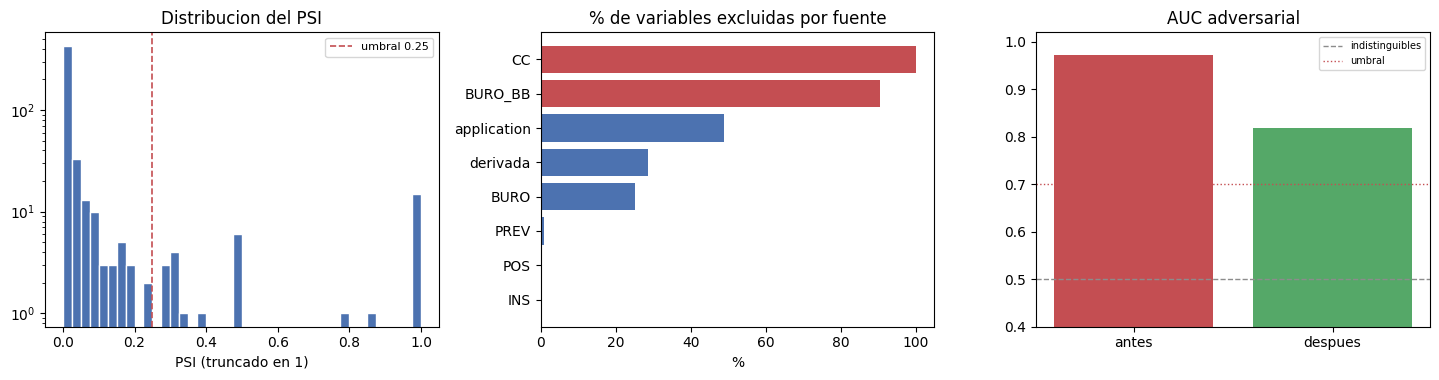

In [55]:
print('=== VALIDACION ADVERSARIAL (despues de excluir) ===\n')
AUC_DESPUES = adversarial(ESTABLES, 'solo variables conservadas')

print(f'\n  AUC antes   : {AUC_ANTES:.4f}')
print(f'  AUC despues : {AUC_DESPUES:.4f}')
print(f'  Reduccion   : {AUC_ANTES - AUC_DESPUES:+.4f}')
if AUC_DESPUES <= AUC_ADVERSARIAL_MAXIMA:
    print('\n  La exclusion deja las particiones por debajo del umbral: el')
    print('  desplazamiento remanente ya no permite distinguirlas de forma')
    print('  preocupante, y la validacion cruzada de la Fase 4 es representativa.')
else:
    print('\n  ATENCION: sigue por encima del umbral. El desplazamiento NO se explica')
    print('  solo por las variables excluidas. Debe reportarse como limitacion: la')
    print('  evaluacion interna sera optimista respecto del comportamiento en test.')

fig, ax = plt.subplots(1, 3, figsize=(14.5, 3.9))
_psi_val = ESTABILIDAD['PSI'].dropna()
ax[0].hist(_psi_val.clip(0, 1), bins=40, color=AZUL_E, edgecolor='white')
ax[0].axvline(PSI_MAXIMO, color=ROJO_E, ls='--', lw=1.2, label=f'umbral {PSI_MAXIMO}')
ax[0].set(title='Distribucion del PSI', xlabel='PSI (truncado en 1)', yscale='log')
ax[0].legend(fontsize=8)

_cf = por_fuente['Excluidas_%'].sort_values()
ax[1].barh(_cf.index.tolist(), _cf.to_numpy(),
           color=[ROJO_E if v > 50 else AZUL_E for v in _cf.to_numpy()])
ax[1].set(title='% de variables excluidas por fuente', xlabel='%')

ax[2].bar(['antes', 'despues'], [AUC_ANTES, AUC_DESPUES], color=[ROJO_E, VERDE_E])
ax[2].axhline(0.5, color=GRIS_E, ls='--', lw=1, label='indistinguibles')
ax[2].axhline(AUC_ADVERSARIAL_MAXIMA, color=ROJO_E, ls=':', lw=1, label='umbral')
ax[2].set(title='AUC adversarial', ylim=(0.4, 1.02))
ax[2].legend(fontsize=7)
plt.tight_layout()
plt.show()

## 3.5.6. Poda de la redundancia

La Fase 3 encontró pares con correlación por encima de 0,95 —alguno exactamente
1,0000, que es la misma columna con dos nombres— y los dejó todos en la tabla.
Aquí se agrupan en conglomerados: si *a* está correlacionada con *b* y *b* con
*c*, los tres van al mismo grupo, y **de cada grupo sobrevive una sola**: la de
mayor cobertura y, a igualdad, la de nombre más corto, que suele ser la forma
canónica.

Queda una tabla de equivalencias, de modo que siempre se puede saber qué
representa cada superviviente. La poda no es imprescindible para una regresión
con penalización L2 —que reparte el peso entre variables colineales sin
inestabilizarse—, pero sí lo es para poder **interpretar** los coeficientes de la
sección 13.1: con dos copias de la misma variable, cada coeficiente recoge la
mitad del efecto y ninguna de las dos lecturas es correcta.

In [56]:
# --- varianza nula y cuasi-nula ---------------------------------------------
sd = app[ESTABLES].std(numeric_only=True)
SIN_VARIANZA = sorted(sd[(sd.isna()) | (sd == 0)].index)
casi_constantes = []
for c in ESTABLES:
    if c in SIN_VARIANZA:
        continue
    vc = app[c].value_counts(dropna=True)
    if len(vc) and vc.iloc[0] / max(app[c].notna().sum(), 1) > 0.999:
        casi_constantes.append(c)

TRAS_VARIANZA = [c for c in ESTABLES
                 if c not in set(SIN_VARIANZA) | set(casi_constantes)]
print('=== VARIANZA ===')
print(f'  Constantes       : {len(SIN_VARIANZA)}')
print(f'  Cuasi-constantes : {len(casi_constantes)}  (un valor cubre > 99,9%)')
print(f'  Quedan           : {len(TRAS_VARIANZA):,} de {len(ESTABLES):,}')

# --- conglomerados de correlacion -------------------------------------------
T_RED = time.time()
N_CORR = min(60_000, len(app))
sub = app[TRAS_VARIANZA].sample(n=N_CORR, random_state=SEMILLA)
MATRIZ_R = sub.corr(numeric_only=True).abs()
del sub
gc.collect()

# Union de conjuntos: la correlacion no es transitiva, pero para agrupar copias
# de una misma medida basta con encadenar los pares que superan el umbral.
padre = {c: c for c in MATRIZ_R.columns}


def raiz(x):
    while padre[x] != x:
        padre[x] = padre[padre[x]]
        x = padre[x]
    return x


_tri = np.triu(np.ones(MATRIZ_R.shape, dtype=bool), k=1)
_ii, _jj = np.where((MATRIZ_R.to_numpy() > CORRELACION_MAXIMA) & _tri)
_cols_r = MATRIZ_R.columns.to_numpy()
for _i, _j in zip(_ii, _jj):
    _ra, _rb = raiz(_cols_r[_i]), raiz(_cols_r[_j])
    if _ra != _rb:
        padre[_rb] = _ra

grupos = {}
for c in MATRIZ_R.columns:
    grupos.setdefault(raiz(c), []).append(c)
grupos = {k: v for k, v in grupos.items() if len(v) > 1}

cobertura_var = app[TRAS_VARIANZA].notna().mean()
EQUIVALENCIAS = []
for miembros in grupos.values():
    elegida = sorted(miembros, key=lambda c: (-float(cobertura_var[c]), len(c), c))[0]
    for m in miembros:
        if m != elegida:
            EQUIVALENCIAS.append({'Descartada': m, 'Representada_por': elegida,
                                  'r': round(float(MATRIZ_R.loc[m, elegida]), 4)})

REDUNDANTES = {x['Descartada'] for x in EQUIVALENCIAS}
VARIABLES_MODELO = [c for c in TRAS_VARIANZA if c not in REDUNDANTES]
del MATRIZ_R
gc.collect()

print(f'\n=== CONGLOMERADOS DE CORRELACION (|r| > {CORRELACION_MAXIMA}) ===  '
      f'[{time.time() - T_RED:.0f} s]')
print(f'  Conglomerados con mas de un miembro : {len(grupos)}')
print(f'  Descartadas por redundancia         : {len(REDUNDANTES)}')
print(f'  Variables cuantitativas finales     : {len(VARIABLES_MODELO):,}')

if EQUIVALENCIAS:
    EQ = pd.DataFrame(EQUIVALENCIAS).sort_values('r', ascending=False)
    print('\n  Equivalencias mas fuertes (r = 1,0000 es la misma columna dos veces):')
    print(EQ.head(12).to_string(index=False))
    print('\n  Conglomerados mas grandes:')
    for g_ in sorted(grupos.values(), key=len, reverse=True)[:3]:
        print(f'    {len(g_):>3} variables — p. ej. {sorted(g_)[:3]}')

=== VARIANZA ===
  Constantes       : 2
  Cuasi-constantes : 66  (un valor cubre > 99,9%)
  Quedan           : 526 de 594



=== CONGLOMERADOS DE CORRELACION (|r| > 0.95) ===  [22 s]
  Conglomerados con mas de un miembro : 43
  Descartadas por redundancia         : 60
  Variables cuantitativas finales     : 466

  Equivalencias mas fuertes (r = 1,0000 es la misma columna dos veces):
                                 Descartada                        Representada_por    r
                              BURO_BB_COUNT                              BURO_COUNT 1.00
                           PREV_N_CONTRATOS                              PREV_COUNT 1.00
    PREV_FLAG_LAST_APPL_PER_CONTRACT_Y_MEAN PREV_FLAG_LAST_APPL_PER_CONTRACT_N_MEAN 1.00
    PREV_NAME_CONTRACT_TYPE_Cash loans_MEAN    PREV_NAME_CASH_LOAN_PURPOSE_XAP_MEAN 1.00
 PREV_NAME_CONTRACT_STATUS_Unused offer_SUM      PREV_CODE_REJECT_REASON_CLIENT_SUM 1.00
PREV_NAME_CONTRACT_STATUS_Unused offer_MEAN     PREV_CODE_REJECT_REASON_CLIENT_MEAN 1.00
                 INS_DAYS_ENTRY_PAYMENT_MIN                 INS_DAYS_INSTALMENT_MIN 1.00
                 INS_DAYS_

## 3.5.7. El embudo completo

In [57]:
EMBUDO = pd.DataFrame([
    {'Paso': '1. Tras la union', 'Variables': len(NUMERICAS_TT), 'Motivo': '—'},
    {'Paso': '2. Estabilidad train/test', 'Variables': len(ESTABLES),
     'Motivo': f'-{len(EXCLUIDAS)} por PSI / KS / cobertura'},
    {'Paso': '3. Varianza', 'Variables': len(TRAS_VARIANZA),
     'Motivo': f'-{len(SIN_VARIANZA) + len(casi_constantes)} constantes o cuasi-constantes'},
    {'Paso': '4. Redundancia', 'Variables': len(VARIABLES_MODELO),
     'Motivo': f'-{len(REDUNDANTES)} por |r| > {CORRELACION_MAXIMA}'},
])
print('=== EMBUDO DE SELECCION ===')
print(EMBUDO.to_string(index=False))
_reduccion = 100 * (1 - len(VARIABLES_MODELO) / max(len(NUMERICAS_TT), 1))
print(f'\n  Reduccion total: {len(NUMERICAS_TT):,} -> {len(VARIABLES_MODELO):,} '
      f'({_reduccion:.1f}% descartado)')
print('\n  Cada descarte tiene un motivo registrado y es reversible: cambiando los')
print('  umbrales de la celda 3.5.1 y reejecutando se obtiene otra seleccion.')
print('  NINGUN criterio de descarte uso el TARGET, de modo que el embudo no')
print('  introduce fuga de informacion hacia la evaluacion posterior.')

RESUMEN_FASE35 = {
    'variables_iniciales': len(NUMERICAS_TT),
    'excluidas_inestables': len(EXCLUIDAS),
    'descartadas_varianza': len(SIN_VARIANZA) + len(casi_constantes),
    'descartadas_redundancia': len(REDUNDANTES),
    'variables_finales': len(VARIABLES_MODELO),
    'auc_adversarial_antes': AUC_ANTES,
    'auc_adversarial_despues': AUC_DESPUES,
}
print(f'\nLa Fase 4 modelara sobre estas {len(VARIABLES_MODELO):,} variables '
      'cuantitativas\nmas las cualitativas de `application`.')

=== EMBUDO DE SELECCION ===
                     Paso  Variables                            Motivo
         1. Tras la union        893                                 —
2. Estabilidad train/test        594     -299 por PSI / KS / cobertura
              3. Varianza        526 -68 constantes o cuasi-constantes
           4. Redundancia        466                -60 por |r| > 0.95

  Reduccion total: 893 -> 466 (47.8% descartado)

  Cada descarte tiene un motivo registrado y es reversible: cambiando los
  umbrales de la celda 3.5.1 y reejecutando se obtiene otra seleccion.
  NINGUN criterio de descarte uso el TARGET, de modo que el embudo no
  introduce fuga de informacion hacia la evaluacion posterior.

La Fase 4 modelara sobre estas 466 variables cuantitativas
mas las cualitativas de `application`.


**Lectura.** El embudo convierte los dos hallazgos de la Fase 3 en decisiones
trazables. Lo relevante no es cuántas variables sobreviven —eso depende de los
umbrales— sino que la caída del AUC adversarial demuestre que el conjunto
resultante sí es comparable entre particiones. Ese es el requisito para que la
validación cruzada de la Fase 4 signifique algo respecto del comportamiento del
modelo fuera de la muestra.

---

# Fase 4 — Modelado: regresión logística

Las tres fases anteriores describieron los datos. Esta los somete a un modelo. El objetivo
no es obtener el mejor resultado posible sino **establecer una línea base**: un modelo
sencillo, ajustado sobre todas las variables disponibles, que sirva de punto de comparación
para lo que venga después y que muestre hasta dónde llega una frontera de decisión lineal
en este problema.

Antes de escribir código conviene resolver una pregunta previa, porque de ella dependen la
familia de modelos, la métrica y la forma misma de la evaluación.

## ¿Clasificación o regresión?

El problema es de **clasificación binaria supervisada**. El EDA lo deja probado en cuatro
puntos, y ninguno es una lectura del enunciado sino un hecho verificado sobre los datos.

**La variable objetivo es categórica.** `TARGET` toma exactamente dos valores: 1 si el
solicitante presentó dificultades de pago, 0 en caso contrario. Entre ambos no existe orden
ni magnitud, únicamente pertenencia a una clase. La regresión estima una cantidad continua
—el valor de una vivienda, un ingreso, un plazo—; aquí no hay cantidad que estimar sino una
pertenencia que decidir.

**La distribución es de 11.4 a 1.** De 307,511 solicitudes, 24,825 terminaron en
incumplimiento y 282,686 no, es decir 8.07% de positivos. El desbalance de clases es una
noción que solo existe en clasificación: una variable continua no tiene clases que puedan
estar desbalanceadas.

**La métrica fijada es AUC-ROC y no RMSE ni $R^2$.** El AUC mide la capacidad de *ordenar*
a los solicitantes por riesgo; el $R^2$ mide la proporción de varianza explicada de una
variable continua. Que la Fase 1 haya escogido la primera confirma la naturaleza de la
tarea.

**Todo el análisis previo se construyó sobre tasas condicionales de clase.** La edad se leyó
como 12.30% de mora entre los 20 y los 25 años frente a 3.73% entre los 65 y los 70; el
patrón de ausencia se contrastó con chi-cuadrado contra `TARGET`; las densidades de las
fuentes externas se graficaron separadas por clase. Ninguno de esos procedimientos tiene
sentido sobre un objetivo continuo.

**Una precisión sobre el nombre.** La regresión logística *es* un modelo de regresión en su
forma matemática: estima la combinación lineal $\beta_0 + \beta_1x_1 + \cdots + \beta_px_p$
igual que la regresión lineal. La diferencia está en qué modela esa combinación —el
logaritmo de la razón de probabilidades, no la media condicional de una continua— y en que
al aplicar un umbral produce una decisión de clase. De ahí que `LogisticRegression` no deba
confundirse con `LinearRegression`: comparten la forma lineal, no la tarea.

| | Regresión | Clasificación (este caso) |
|---|---|---|
| Objetivo | Continuo | `TARGET` $\in \{0, 1\}$ |
| Modelo | `LinearRegression`, `Ridge`, `Lasso` | `LogisticRegression` |
| Salida | Un número | Probabilidad → clase |
| Métricas | RMSE, MAE, $R^2$ | AUC-ROC, matriz de confusión, F1 |
| Diagnóstico | Residuos | Matriz de confusión |

## Alcance de esta fase

Se ajusta la regresión logística sobre **el conjunto que entrega la Fase 3.5**: las 466
variables cuantitativas que sobrevivieron al embudo de estabilidad, varianza y redundancia,
más las 16 cualitativas de `application` y el indicador del centinela de `DAYS_EMPLOYED`. Son
483 columnas, que la codificación indicadora convierte en 610. Aquí no se hace ninguna
selección adicional: interesa saber qué rinde el modelo lineal sobre ese conjunto, para que
la comparación con cualquier modelo siguiente parta de la misma base.

Este párrafo decía antes «sobre todas las variables disponibles, sin selección previa» y
cifraba en 217 las columnas que llegaban. Ninguna de las dos cosas era cierta: la celda de
preparación aplica el filtro de la Fase 3.5 desde que esa fase existe —descarta 427 de las
893 variables— y las que llegan son 483. Se corrige contra la salida de la corrida, que es
lo único que puede arbitrar entre el texto y el código.

Lo único que se retira es `SK_ID_CURR`, que es el identificador de la solicitud. Sus valores
no guardan relación alguna con el riesgo y el modelo solo podría aprender ruido de ellos.

Sí se conserva una corrección de la Fase 1: el valor 365243 de `DAYS_EMPLOYED`, que codifica
ausencia y equivale a mil años en el futuro, se convierte a nulo después de guardar su
indicador. Es limpieza de datos, no selección de variables, y omitirla introduciría un valor
imposible en el ajuste.

**Una advertencia sobre el conjunto de variables.** Las columnas que llegan aquí se
construyeron en la Fase 3, y esa fase calculó correlaciones y AUC univariados contra `TARGET`
sobre las 307,511 filas para decidir qué tablas agregar, qué ventana temporal usar y qué
razones derivar. Modelar después sin selección adicional evita la fuga más grave, pero no
la elimina del todo: el conjunto de variables ya se diseñó mirando el objetivo sobre filas
que aquí acaban en validación y en prueba. La lectura correcta de las cifras finales es que
son una **estimación optimista** de lo que rendiría el mismo procedimiento aplicado de
principio a fin dentro de una validación cruzada anidada. Se deja anotado en lugar de
rehacerse porque rehacerlo implica repetir las tres fases anteriores dentro de cada pliegue.

**Cómo está organizada la fase.** Las secciones 1 a 5 preparan los datos y el pipeline; la 6
fija la línea base ingenua; las 7 y 8 ajustan y diagnostican sobre una partición; la 9 somete
esas cifras a validación cruzada; la 10 busca la regularización; la 11 elige el umbral; la 12
evalúa una única vez sobre el conjunto de prueba; las 13 a 15 diagnostican, guardan y
resumen.

## 1. Configuración

Además de los `import`, el bloque revierte una decisión de las fases anteriores. La Fase 3
llamó a `warnings.filterwarnings('ignore')` para que la salida del EDA no se llenara de
avisos, y ese silencio sigue vigente en el mismo kernel. En modelado es peligroso: si
`lbfgs` agota `max_iter` sin converger emite un `ConvergenceWarning`, y los coeficientes que
la sección 13 interpreta no serían entonces los del óptimo sino los del punto donde se
detuvo el optimizador. Los avisos se reactivan aquí, y además cada ajuste comprueba de forma
explícita cuántas iteraciones consumió. La versión anterior hacía esa comprobación solo en
tres ajustes y la dejaba en un `print` sin consecuencias; ahora los ajustes de dentro de los
pliegues de la sección 9 se cuentan, y la sección 10 se **niega** a promover a modelo final
un ajuste que se detuvo en el tope de iteraciones en lugar de en el óptimo.

También se fijan de una vez el esquema de validación cruzada
—`StratifiedKFold(5, shuffle=True)`— y el par de métricas que se usará en todo el capítulo,
para que ninguna celda invente el suyo.

In [58]:
import os, gc, glob, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     GridSearchCV, cross_validate)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.calibration import calibration_curve
from sklearn.metrics import (roc_auc_score, roc_curve, average_precision_score,
                             precision_recall_curve, brier_score_loss,
                             confusion_matrix, classification_report,
                             ConfusionMatrixDisplay)

# Las fases anteriores silenciaron los avisos para no ensuciar la salida del EDA.
# En modelado ese silencio es peligroso: un ConvergenceWarning de `lbfgs` significa
# que los coeficientes que despues se interpretan no son los del optimo. Se reactivan
# antes de ajustar nada.
warnings.resetwarnings()
warnings.simplefilter('always', ConvergenceWarning)

pd.set_option('display.max_columns', 200)

SEMILLA  = 42
CV       = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEMILLA)
METRICAS = ['roc_auc', 'average_precision']
NUCLEOS  = min(4, max(1, (os.cpu_count() or 2) - 1))   # pliegues en paralelo
# Cada proceso paralelo replica la matriz transformada entera. Con esta matriz
# eso son varios cientos de MB por proceso, de modo que `cpu_count() - 1` sin
# tope agota la memoria de una maquina de 24 GB antes de terminar la rejilla.
# El tope de cuatro es lo que permite que la fase corra de principio a fin en un
# solo kernel; subalo si tiene holgura, bajelo a 1 si va muy justo.

RESULTADOS   = {}   # acumulador unico para el resumen final
CONVERGENCIA = {}   # registro de que ajustes llegaron al optimo y cuales no

## 2. Carga

El bloque detecta en qué punto del proyecto se encuentra el entorno. Si la Fase 3 ya se
ejecutó y `app` está en memoria, modela sobre `application` más los seis resúmenes de
historial. Si solo se corrió la Fase 1, usa `df`.

La ruta de respaldo ya no está escrita a mano. `resolver_ruta` prueba, en orden, la variable
de entorno `HOME_CREDIT_DIR`, la `RUTA` que definió la Fase 3 y las ubicaciones habituales
del conjunto; si ninguna contiene `application_train.csv` levanta un error que dice qué
hacer, en lugar de fallar intentando leer el disco de otra máquina.

In [59]:
# --- localizacion del conjunto, sin rutas fijas de ninguna maquina ---------------
ARCHIVOS_HC = ['application_train.csv', 'application_test.csv', 'bureau.csv',
               'bureau_balance.csv', 'previous_application.csv',
               'installments_payments.csv', 'POS_CASH_balance.csv',
               'credit_card_balance.csv']


def _completitud(d):
    """Cuantos archivos del conjunto hay en `d`, contando solo ficheros legibles.

    Usa isfile y no exists: en este proyecto llego a existir un DIRECTORIO llamado
    `application_train.csv` que contenia dentro el csv, y `exists` lo daba por bueno
    hasta que `read_csv` fallaba con PermissionError al intentar abrir una carpeta.
    """
    if not d or not os.path.isdir(d):
        return 0
    return sum(os.path.isfile(os.path.join(d, a)) for a in ARCHIVOS_HC)



def _corta(p):
    """Ruta para mostrar sin datos de la maquina: solo las dos ultimas carpetas."""
    partes = [x for x in os.path.normpath(str(p)).split(os.sep) if x]
    return os.path.join('...', *partes[-2:])


def resolver_ruta(minimo=1, verboso=True):
    """Devuelve el directorio con mas archivos del conjunto, o None si no hay ninguno.

    Si HOME_CREDIT_DIR esta definida y apunta a una carpeta con el conjunto, se
    devuelve sin mas. En su defecto busca una RUTA ya definida en el entorno, el
    directorio de trabajo y hasta dos niveles por debajo de las ubicaciones
    habituales. Entre esos candidatos gana el mas completo, de modo que una carpeta
    con un solo csv suelto no desplaza a la que trae el conjunto entero.
    """
    bases = [os.getcwd(), os.path.expanduser('~'),
             os.path.join(os.path.expanduser('~'), 'Desktop'),
             os.path.join(os.path.expanduser('~'), 'OneDrive', 'Escritorio'),
             os.path.join(os.path.expanduser('~'), 'OneDrive', 'Desktop'),
             os.path.join(os.path.expanduser('~'), 'Documents'),
             os.path.join(os.path.expanduser('~'), 'Downloads')]

    # Una ruta indicada a mano manda sobre la busqueda. Antes HOME_CREDIT_DIR
    # entraba como un candidato mas y la puntuacion podia descartarla en favor de
    # otra copia igual de completa solo por tener la ruta mas corta, de modo que
    # definir la variable no servia para desempatar entre dos copias del conjunto.
    forzada = os.environ.get('HOME_CREDIT_DIR')
    if forzada and _completitud(forzada) >= minimo:
        forzada = os.path.abspath(forzada)
        if verboso:
            print(f'Conjunto tomado de HOME_CREDIT_DIR: {_corta(forzada)}')
            print(f'  archivos encontrados: {_completitud(forzada)} de {len(ARCHIVOS_HC)}')
        return forzada

    candidatos = [globals().get('RUTA')]
    for b in bases:
        for patron in ('', '*', os.path.join('*', '*')):
            candidatos += [os.path.dirname(p) for p in
                           glob.glob(os.path.join(b, patron, 'application_train.csv'))]
        candidatos.append(b)

    vistos, puntuados = set(), []
    for c in candidatos:
        c = os.path.abspath(c) if c else None
        if not c or c in vistos:
            continue
        vistos.add(c)
        n = _completitud(c)
        if n >= minimo:
            puntuados.append((n, c))

    if not puntuados:
        return None
    puntuados.sort(key=lambda t: (-t[0], len(t[1])))
    mejor = puntuados[0][1]
    if verboso:
        print(f'Conjunto localizado en: {_corta(mejor)}')
        print(f'  archivos encontrados: {puntuados[0][0]} de {len(ARCHIVOS_HC)}')
        for n, c in puntuados[1:4]:
            print(f'  (descartado, {n} archivos) {_corta(c)}')
    return mejor


# `datos` es una REFERENCIA, no una copia. Con el historial agregado la tabla
# ronda las 800 columnas y ~1 GB; copiarla aqui y mantener despues X y las tres
# particiones significaba tener cuatro veces la misma matriz en memoria. La celda
# siguiente libera el original en cuanto ha construido X.
# Donde buscar el traspaso que dejo la Fase 3. Se resuelve antes de elegir la
# fuente para que el archivo en disco tenga prioridad sobre el `df` de la Fase 1.
_ruta_cache = globals().get('RUTA') or resolver_ruta(verboso=False)
_TRASPASO = os.path.join(_ruta_cache, 'cache', 'fase3_app.parquet') if _ruta_cache else None

if 'app' in globals():                      # Fase 3: application + historial
    datos = app
    print('Fuente: `app` de la Fase 3 (application + historial agregado)')
elif _TRASPASO and os.path.isfile(_TRASPASO):   # Fase 3 de un kernel anterior
    datos = pd.read_parquet(_TRASPASO)
    print(f'Fuente: traspaso de la Fase 3 en disco\n  {_TRASPASO}')
elif 'df' in globals():                     # Fase 1: solo application
    datos = df
    print('Fuente: `df` de la Fase 1 (solo application_train)')
    print('AVISO: sin el historial agregado de las Fases 2 y 3, y con los nulos\n'
          '       ya imputados por la Fase 1 sobre la muestra completa.')
else:
    ruta = resolver_ruta()
    if ruta is None:
        raise FileNotFoundError(
            'No se encontro el conjunto. Descarguelo de Kaggle '
            '(home-credit-default-risk) y deje los .csv en una carpeta, o defina la '
            'variable de entorno HOME_CREDIT_DIR con su ruta.')
    datos = pd.read_csv(os.path.join(ruta, 'application_train.csv'))
    print(f'Fuente: application_train.csv leido desde {_corta(ruta)}')
    print('AVISO: solo `application`. Para modelar tambien sobre el historial '
          'agregado,\n       ejecute antes la Fase 3 y vuelva aqui.')

print(f'Dimension inicial: {datos.shape[0]:,} filas x {datos.shape[1]:,} columnas')
print(f'Tasa de mora     : {100*datos["TARGET"].mean():.2f}%')

Fuente: `app` de la Fase 3 (application + historial agregado)
Dimension inicial: 307,511 filas x 911 columnas
Tasa de mora     : 8.07%


## 3. Preparación

Aquí solo ocurre lo que es **independiente de los datos**: reglas fijas que dan el mismo
resultado aplicadas antes o después de partir, y que por tanto no filtran nada.

La corrección del centinela de `DAYS_EMPLOYED`, que preserva la señal en un indicador antes
de anular el valor imposible. Ese subgrupo presenta 5.40% de mora frente a 8.66% en el
resto, de modo que la información se perdería si el indicador no se construyera antes. El
valor 365243 es una constante del diccionario de datos, no un estadístico estimado de la
muestra.

La sustitución de infinitos por nulos, que aparecen al calcular razones cuando el
denominador es cero. El imputador los tratará después, dentro del pipeline, junto con los
demás faltantes.

**Lo que ya no ocurre aquí es la codificación indicadora.** La versión anterior llamaba a
`pd.get_dummies` sobre la matriz completa, antes de partir. Parece inocuo y no lo es: el
conjunto de columnas resultante —qué categorías existen y cuántas— se deriva de las 307,511
filas, incluidas las que después sirven para evaluar. Es una transformación *aprendida de
los datos*, y toda transformación aprendida pertenece al pipeline. Se traslada a un
`OneHotEncoder` dentro de un `ColumnTransformer` (sección 5), que además resuelve dos
problemas que `get_dummies` dejaba abiertos: qué hacer con una categoría que solo aparece en
prueba, y cómo garantizar que `application_test` produzca exactamente las mismas columnas en
el mismo orden.

In [60]:
if 'datos' not in globals():
    raise NameError('`datos` no esta en memoria: esta celda la consume para no '
                    'mantener tres copias de la tabla a la vez. Vuelva a ejecutar '
                    'la celda de carga de la seccion 2 antes que esta.')

y = datos['TARGET'].astype(int)
X = datos.drop(columns=['TARGET', 'SK_ID_CURR'], errors='ignore')

# --- se aplica la seleccion de la Fase 3.5 ---------------------------------
# Sin este filtro, la Fase 4 modelaria sobre las variables que la 3.5 declaro no
# comparables entre particiones, y el embudo de seleccion no habria servido de
# nada. Si la Fase 3.5 no se ejecuto, se sigue con todas y se avisa.
if 'VARIABLES_MODELO' in globals():
    _cuali = [c for c in X.columns
              if not pd.api.types.is_numeric_dtype(X[c])]
    _conservar = [c for c in X.columns
                  if c in set(VARIABLES_MODELO) or c in set(_cuali)]
    _descartadas = X.shape[1] - len(_conservar)
    X = X[_conservar]
    print(f'Seleccion de la Fase 3.5 aplicada: se descartan {_descartadas:,} '
          f'variables\n  quedan {len(_conservar):,} '
          f'({len(_conservar) - len(_cuali):,} cuantitativas + {len(_cuali):,} '
          f'cualitativas)')
else:
    print('AVISO: no se encontro VARIABLES_MODELO. Se modela sobre TODAS las '
          'variables.\n  Ejecute la Fase 3.5 para aplicar el filtro de '
          'estabilidad y redundancia.')

# `datos` no era una copia: es el mismo objeto que `app` (o que `df`). Borrar solo
# el nombre local no devolvia un byte. Se sueltan aqui tanto el original como las
# tablas auxiliares del EDA que la Fase 4 ya no consulta -- `df_cod`, con las
# indicadoras de la Fase 1, pesa por si sola varios cientos de MB.
del datos
for _n in ('app', 'df', 'df_cod', 'test', 'poly', 'muestra'):
    if globals().pop(_n, None) is not None:
        print(f'  liberado: {_n}')
gc.collect()

# --- centinela de DAYS_EMPLOYED: se preserva la senal antes de anular el valor.
#     Es una regla fija, no un estadistico estimado de los datos, de modo que
#     aplicarla antes de partir no filtra informacion.
if 'DAYS_EMPLOYED' in X.columns and (X['DAYS_EMPLOYED'] == 365243).any():
    X = X.copy()        # compacta antes de escribir
    X = X.assign(
        DAYS_EMPLOYED_ANOM=(X['DAYS_EMPLOYED'] == 365243).astype('int8'),
        DAYS_EMPLOYED=X['DAYS_EMPLOYED'].astype('float64').mask(
            X['DAYS_EMPLOYED'].eq(365243)),
    )
    print('Centinela 365243 corregido')

# --- infinitos procedentes de razones con denominador cero
CUANTITATIVAS = [c for c in X.columns if pd.api.types.is_numeric_dtype(X[c])]
CUALITATIVAS  = [c for c in X.columns if c not in CUANTITATIVAS]

# Columna a columna y solo donde de verdad hay infinitos: `X[CUANTITATIVAS] = ...`
# materializaba de golpe una copia de todo el bloque numerico, otro GB de pico
# para corregir un punado de celdas.
_n_inf = 0
for _c in CUANTITATIVAS:
    if X[_c].dtype.kind != 'f':
        continue
    _m = np.isinf(X[_c].to_numpy())
    if _m.any():
        _n_inf += int(_m.sum())
        X[_c] = X[_c].mask(_m)
print(f'Infinitos convertidos a nulo: {_n_inf:,}')

# --- las cualitativas NO se codifican aqui. La codificacion indicadora se aprende
#     de los datos (que categorias existen) y por tanto pertenece al pipeline, no a
#     esta celda: hacerla ahora derivaria el vocabulario de categorias de las filas
#     que despues serviran para evaluar. `category` rompe a SimpleImputer, se pasa a
#     `object`, que es la conversion que espera OneHotEncoder.
for c in CUALITATIVAS:
    X[c] = X[c].astype('object')

print(f'Matriz de diseno: {X.shape[0]:,} filas x {X.shape[1]:,} columnas')
print(f'  cuantitativas: {len(CUANTITATIVAS)}   cualitativas: {len(CUALITATIVAS)}')
print(f'Porcentaje de celdas faltantes: {100*X.isnull().mean().mean():.1f}%')

Seleccion de la Fase 3.5 aplicada: se descartan 427 variables
  quedan 482 (466 cuantitativas + 16 cualitativas)
  liberado: app
  liberado: df
  liberado: df_cod
  liberado: test
  liberado: poly
  liberado: muestra


Centinela 365243 corregido
Infinitos convertidos a nulo: 0
Matriz de diseno: 307,511 filas x 483 columnas
  cuantitativas: 467   cualitativas: 16


Porcentaje de celdas faltantes: 6.6%


## 4. Partición: tres conjuntos, no dos

`application_test` no trae `TARGET`, de modo que evaluar el modelo exige reservar una parte
de `train` que no participe del ajuste.

Pero **dos conjuntos no bastan**, y la versión anterior de este capítulo lo demostraba sin
querer: elegía el umbral de Youden mirando la curva ROC de validación y después reportaba
recall y F1 sobre ese mismo conjunto. El umbral es un parámetro de decisión como cualquier
otro, y medirlo donde se eligió infla el resultado. Lo mismo vale para la elección de `C` y
para la comparación entre el modelo ponderado y el que no lo está: son tres decisiones
tomadas mirando datos, y ninguna puede evaluarse sobre los datos que la produjeron.

El reparto es 64 / 16 / 20 con papeles separados:

| Conjunto | Uso |
|---|---|
| **entrenamiento** (64%) | ajuste de coeficientes y validación cruzada |
| **validación** (16%) | elección de `C`, de la penalización y del umbral |
| **prueba** (20%) | una única evaluación, al final, sin ninguna decisión tomada sobre ella |

Una cosa más ocurre en esta celda y no en otra: **las tres particiones se pasan a `float32`
aquí**, antes del primer ajuste. En la versión anterior esa conversión vivía dentro de la
celda de validación cruzada de la sección 9, que es posterior; ejecutarla cambiaba en el
cuarto decimal las cifras que las secciones 7 y 8.1 ya habían impreso —0.743513 frente a
0.743597 de AUC en validación—. Fijar el tipo donde nacen las matrices es la condición para
que el capítulo dé el mismo resultado se recorra como se recorra.

Las tres particiones se estratifican por la variable objetivo. Con 8.07% de positivos, un
muestreo sin estratificar haría que la proporción de la clase minoritaria variara por azar y
el modelo terminaría evaluándose sobre una población distinta de la que vio al entrenarse.

In [61]:
# Tres conjuntos, no dos. `validacion` sirve para elegir (modelo, hiperparametros,
# umbral) y `prueba` no se toca hasta el informe final: cualquier decision tomada
# mirando un conjunto sesga al alza las metricas que ese mismo conjunto produzca.
N_TOTAL = len(X)

X_ajuste, X_te, y_ajuste, y_te = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEMILLA)
X_tr, X_va, y_tr, y_va = train_test_split(
    X_ajuste, y_ajuste, test_size=0.20, stratify=y_ajuste, random_state=SEMILLA)

# Las particiones son copias completas: mantener ademas X entera duplicaba la
# matriz de diseno durante todo el resto de la fase.
del X, X_ajuste, y_ajuste; gc.collect()

# --- dtype unico para TODO el capitulo, fijado antes del primer ajuste -------
# La version anterior hacia esta conversion dentro de la celda de validacion
# cruzada (seccion 9), que es POSTERIOR a las secciones 7 y 8.1. Consecuencia
# medida: el AUC de validacion de la seccion 7 valia 0.743513 si esa celda se
# corria antes de la 9 y 0.743597 si se corria despues. El cuaderno reporta AUC
# a cuatro decimales, de modo que una cifra del informe dependia del orden en
# que se hubieran pulsado las celdas. Fijando el dtype aqui, todos los ajustes
# del capitulo ven la misma matriz y el resultado ya no depende del recorrido.
_bajadas = 0
for _P in (X_tr, X_va, X_te):
    _c64 = [c for c in _P.columns if _P[c].dtype == 'float64']
    if _c64:
        _P[_c64] = _P[_c64].astype('float32')
        _bajadas += len(_c64)
gc.collect()
print(f'Columnas pasadas a float32 (una sola vez, antes de ajustar): {_bajadas}')

PARTICIONES = pd.DataFrame(
    [{'Particion': n, 'Filas': len(a), '%': round(100*len(a)/N_TOTAL, 1),
      'Mora_%': round(100*b.mean(), 2), 'Positivos': int(b.sum())}
     for n, a, b in [('entrenamiento', X_tr, y_tr), ('validacion', X_va, y_va),
                     ('prueba', X_te, y_te)]])
print(PARTICIONES.to_string(index=False))
print('\nentrenamiento -> ajuste de coeficientes y validacion cruzada')
print('validacion    -> eleccion de C, de la penalizacion y del umbral')
print('prueba        -> unica evaluacion, una sola vez, al final')

Columnas pasadas a float32 (una sola vez, antes de ajustar): 582
    Particion  Filas     %  Mora_%  Positivos
entrenamiento 196806 64.00    8.07      15888
   validacion  49202 16.00    8.07       3972
       prueba  61503 20.00    8.07       4965

entrenamiento -> ajuste de coeficientes y validacion cruzada
validacion    -> eleccion de C, de la penalizacion y del umbral
prueba        -> unica evaluacion, una sola vez, al final


## 5. El preprocesamiento, dentro del pipeline

La regla que gobierna toda la fase: **todo lo que se estima a partir de los datos vive
dentro del pipeline.** La mediana de la imputación, la media y la desviación del escalado y
—ahora también— el vocabulario de categorías de la codificación indicadora.

La consecuencia es la que importa. Cuando `cross_validate` o `GridSearchCV` ajustan el
estimador sobre cuatro pliegues y evalúan sobre el quinto, los tres estadísticos se
recalculan dentro de los cuatro y el pliegue de evaluación permanece intacto. Calcularlos
antes sobre el conjunto completo es el error que el material del curso señala como el más
frecuente, y el que produce en el ejemplo canónico una exactitud artificialmente perfecta.

El `ColumnTransformer` separa dos ramas porque las variables piden tratamientos distintos:
las cuantitativas se imputan por mediana y se estandarizan; las cualitativas se imputan con
la categoría `'Desconocido'` —el mismo criterio de la Fase 1— y se codifican con
`OneHotEncoder`. `handle_unknown='infrequent_if_exist'` evita que una categoría no vista en
entrenamiento rompa la transformación, y `min_frequency=20` agrupa las categorías raras en
un único nivel en lugar de generar columnas casi vacías que la regularización no puede
estimar.

El escalado sigue siendo obligatorio. `LogisticRegression` aplica por defecto la penalización
$L^2$ —la misma regularización Ridge vista en el material— que castiga el tamaño de los
coeficientes: sin escalar, una variable medida en decenas de miles recibiría un castigo
incomparable con otra medida entre 0 y 1. Las indicadoras se escalan también, por la misma
razón.

In [62]:
def construir(modelo):
    """Pipeline completo: todo lo que se aprende de los datos vive dentro.

    Rama cuantitativa: imputacion por mediana y estandarizacion.
    Rama cualitativa : imputacion por la categoria 'Desconocido', codificacion
                       indicadora y estandarizacion, para que la penalizacion L2
                       trate por igual a indicadoras y continuas.

    `handle_unknown='infrequent_if_exist'` permite que una categoria vista solo en
    prueba no rompa la transformacion -- se absorbe en el nivel de las raras -- y
    `min_frequency` agrupa esas categorias raras en un unico nivel en lugar de
    generar columnas casi vacias.
    """
    rama_num = Pipeline([
        ('imputador', SimpleImputer(strategy='median')),
        ('escalador', StandardScaler()),
    ])
    rama_cat = Pipeline([
        ('imputador', SimpleImputer(strategy='constant', fill_value='Desconocido')),
        ('indicadora', OneHotEncoder(handle_unknown='infrequent_if_exist',
                                     min_frequency=20, sparse_output=False,
                                     dtype=np.float64)),
        ('escalador', StandardScaler()),
    ])
    preparacion = ColumnTransformer(
        [('num', rama_num, CUANTITATIVAS), ('cat', rama_cat, CUALITATIVAS)],
        remainder='drop', verbose_feature_names_out=False)
    return Pipeline([('preparacion', preparacion), ('modelo', modelo)])


def logistica(**kw):
    base = dict(max_iter=1000, random_state=SEMILLA)
    base.update(kw)
    return LogisticRegression(**base)


def convergio(pipe, etiqueta=None, mostrar=True):
    """Comprueba que el optimizador llego al optimo y no al tope de iteraciones.

    Devuelve True solo si el ajuste se detuvo por convergencia, y lo anota en
    `CONVERGENCIA`. La seccion 10 usa ese valor para NEGARSE a promover a
    `MODELO_FINAL` un ajuste truncado. En la version anterior la funcion
    imprimia el aviso y el cuaderno seguia adelante igual, de modo que la
    comprobacion no comprobaba nada: un ajuste detenido en el tope de
    iteraciones podia terminar siendo el modelo cuyos coeficientes interpreta
    la seccion 13.1 y cuyas metricas reporta la seccion 12.
    """
    m = pipe.named_steps['modelo']
    n, tope = int(np.max(m.n_iter_)), m.max_iter
    ok = bool(n < tope)
    if etiqueta:
        CONVERGENCIA[etiqueta] = {'iteraciones': n, 'tope': tope, 'convergio': ok}
    if mostrar:
        print(f'Optimizador: {n} de {tope} iteraciones -> '
              f'{"convergio" if ok else "NO CONVERGIO, suba max_iter"}')
    return ok


# La preparacion se ajusta aqui una sola vez y solo con entrenamiento, unicamente
# para conocer los nombres de las columnas resultantes. El objeto se descarta: el
# que cuenta es el que cada pipeline ajusta por su cuenta dentro de cada pliegue.
_pre = construir(logistica())[:-1].fit(X_tr, y_tr)
NOMBRES = list(_pre.get_feature_names_out())
print(f'Columnas tras la preparacion: {len(NOMBRES)}  '
      f'({len(CUANTITATIVAS)} cuantitativas + {len(NOMBRES)-len(CUANTITATIVAS)} indicadoras)')
del _pre; gc.collect()

Columnas tras la preparacion: 610  (467 cuantitativas + 143 indicadoras)


23

## 6. Líneas base ingenuas

Antes de mirar ningún modelo hace falta saber qué se obtiene sin aprender nada.
`DummyClassifier` lo vuelve explícito con tres estrategias: responder siempre la clase
mayoritaria, responder al azar respetando las proporciones, y responder al azar uniforme.

La primera es la que importa. Alcanza la exactitud de la clase mayoritaria sin acertar un
solo positivo —AUC-ROC 0.500, recall 0%— y es el número contra el cual debe leerse cualquier
exactitud del resto del capítulo. La tabla fija además la segunda referencia, la que el
desbalance vuelve imprescindible: **el AUC-PR de un clasificador sin información es la tasa
base**, no 0.5. Un AUC-PR de 0.20 sobre una tasa base de 0.08 es un resultado apreciable;
sobre una tasa base de 0.25 sería peor que el azar.

In [63]:
filas = []
for est in ['most_frequent', 'stratified', 'uniform']:
    d = DummyClassifier(strategy=est, random_state=SEMILLA).fit(X_tr, y_tr)
    p = d.predict_proba(X_va)[:, 1]
    tn, fp, fn, tp = confusion_matrix(y_va, d.predict(X_va), labels=[0, 1]).ravel()
    rec = tp / (tp + fn) if (tp + fn) else 0.0
    pre = tp / (tp + fp) if (tp + fp) else 0.0
    filas.append({'Estrategia': est,
                  'Exactitud': (tp + tn) / len(y_va),
                  'AUC_ROC': roc_auc_score(y_va, p),
                  'AUC_PR': average_precision_score(y_va, p),
                  'Precision': pre, 'Recall': rec,
                  'F1': 2*pre*rec/(pre+rec) if (pre+rec) else 0.0,
                  'VP': int(tp)})

DUMMY = pd.DataFrame(filas)
print('=== LINEAS BASE INGENUAS (validacion) ===')
print(DUMMY.to_string(index=False, float_format=lambda v: f'{v:.4f}'))
print(f'\nTasa base de positivos: {y_va.mean():.4f}  '
      '<- es el AUC-PR que obtiene cualquier modelo sin informacion')
print('El AUC-ROC de referencia es 0.5000 para las tres estrategias.')

=== LINEAS BASE INGENUAS (validacion) ===
   Estrategia  Exactitud  AUC_ROC  AUC_PR  Precision  Recall     F1   VP
most_frequent     0.9193   0.5000  0.0807     0.0000  0.0000 0.0000    0
   stratified     0.8507   0.4967  0.0803     0.0746  0.0745 0.0746  296
      uniform     0.4999   0.5000  0.0807     0.0799  0.4937 0.1375 1961

Tasa base de positivos: 0.0807  <- es el AUC-PR que obtiene cualquier modelo sin informacion
El AUC-ROC de referencia es 0.5000 para las tres estrategias.


## 7. Primer ajuste

Se usan los parámetros por defecto salvo `max_iter`. La logística no tiene solución cerrada
como la regresión lineal: sus coeficientes se estiman por optimización iterativa, y con este
número de variables las 100 iteraciones predeterminadas no bastan para converger. La función
`convergio` comprueba que el optimizador se detuvo por haber alcanzado el óptimo y no por
haber agotado el presupuesto —una comprobación que el `filterwarnings('ignore')` heredado
habría vuelto invisible.

Se reportan AUC-ROC y AUC-PR sobre entrenamiento y validación. Son cifras de **una sola
partición**, y como tales se presentan: la sección 9 las repite por validación cruzada antes
de darles crédito.

In [64]:
t0 = time.time()
pipe = construir(logistica())
pipe.fit(X_tr, y_tr)
convergio(pipe, 'seccion 7: C=1, sin ponderar')

p_tr = pipe.predict_proba(X_tr)[:, 1]
p_va = pipe.predict_proba(X_va)[:, 1]

auc_tr, auc_va = roc_auc_score(y_tr, p_tr), roc_auc_score(y_va, p_va)
ap_tr,  ap_va  = average_precision_score(y_tr, p_tr), average_precision_score(y_va, p_va)

print(f'\n=== DESEMPENO (una sola particion) ===  [{time.time()-t0:.0f} s]')
print(f'AUC-ROC entrenamiento : {auc_tr:.4f}')
print(f'AUC-ROC validacion    : {auc_va:.4f}   brecha {auc_tr-auc_va:+.4f}')
print(f'AUC-PR  entrenamiento : {ap_tr:.4f}')
print(f'AUC-PR  validacion    : {ap_va:.4f}   (tasa base {y_va.mean():.4f})')
print(f'Exactitud validacion  : {pipe.score(X_va, y_va):.4f}')
print('\nEstas cifras vienen de UNA particion. La seccion 9 las repite por '
      'validacion cruzada\nantes de darles credito.')

Optimizador: 57 de 1000 iteraciones -> convergio



=== DESEMPENO (una sola particion) ===  [14 s]
AUC-ROC entrenamiento : 0.7661
AUC-ROC validacion    : 0.7555   brecha +0.0106
AUC-PR  entrenamiento : 0.2497
AUC-PR  validacion    : 0.2299   (tasa base 0.0807)


Exactitud validacion  : 0.9186

Estas cifras vienen de UNA particion. La seccion 9 las repite por validacion cruzada
antes de darles credito.


Este AUC indica que el modelo ordena a los solicitantes por riesgo mejor que el azar, que
daría 0.500. La exactitud, en cambio, resulta sospechosamente alta y coincide casi
exactamente con la del `DummyClassifier` de la sección 6. La matriz de confusión explica por
qué.

## 8. La matriz de confusión

La matriz cruza lo que ocurrió con lo que el modelo predijo y descompone el error en sus dos
tipos, que en este problema tienen consecuencias opuestas:

|  | Predicho: cumple | Predicho: incumple |
|---|---|---|
| **Real: cumple** | Verdadero negativo — crédito bien otorgado | Falso positivo — buen cliente rechazado |
| **Real: incumple** | Falso negativo — crédito otorgado que se pierde | Verdadero positivo — riesgo detectado |

La función `reporte` acompaña la matriz con las cinco métricas derivadas y con las dos áreas,
ROC y PR, cada una junto a su valor de azar. Se reutiliza en todo el capítulo, de modo que
las tablas son comparables entre secciones.

In [65]:
def reporte(y_real, prob, umbral, titulo, mostrar=True):
    y_pred = (prob >= umbral).astype(int)
    mc = confusion_matrix(y_real, y_pred, labels=[0, 1])
    tn, fp, fn, tp = mc.ravel()
    exactitud = (tp + tn) / mc.sum()
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall    = tp / (tp + fn) if (tp + fn) else 0.0
    especif   = tn / (tn + fp) if (tn + fp) else 0.0
    f1 = 2*precision*recall / (precision + recall) if (precision + recall) else 0.0
    auc = roc_auc_score(y_real, prob)
    ap  = average_precision_score(y_real, prob)
    if mostrar:
        print(f'\n--- {titulo} (umbral = {umbral:.3f}) ---')
        print(pd.DataFrame(mc,
                           index=['Real: cumple (0)', 'Real: incumple (1)'],
                           columns=['Pred: cumple (0)', 'Pred: incumple (1)']).to_string())
        print(f'Exactitud    : {exactitud:6.2%}   (predecir siempre 0 da {1-y_real.mean():.2%})')
        print(f'Precision    : {precision:6.2%}   de los rechazados, cuantos habrian incumplido')
        print(f'Recall       : {recall:6.2%}   de los incumplidores, cuantos se detectaron')
        print(f'Especificidad: {especif:6.2%}   de los buenos, cuantos se aprobaron')
        print(f'F1-score     : {f1:6.2%}')
        print(f'AUC-ROC      : {auc:6.4f}   (azar 0.5000)')
        print(f'AUC-PR       : {ap:6.4f}   (azar {y_real.mean():.4f})')
    return mc, dict(umbral=umbral, exactitud=exactitud, precision=precision,
                    recall=recall, especificidad=especif, f1=f1, auc_roc=auc,
                    auc_pr=ap, vn=tn, fp=fp, fn=fn, vp=tp)


mc_0, m_0 = reporte(y_va, p_va, 0.50, 'MATRIZ DE CONFUSION, primer ajuste (validacion)')


--- MATRIZ DE CONFUSION, primer ajuste (validacion) (umbral = 0.500) ---
                    Pred: cumple (0)  Pred: incumple (1)
Real: cumple (0)               45114                 116
Real: incumple (1)              3887                  85
Exactitud    : 91.86%   (predecir siempre 0 da 91.93%)
Precision    : 42.29%   de los rechazados, cuantos habrian incumplido
Recall       :  2.14%   de los incumplidores, cuantos se detectaron
Especificidad: 99.74%   de los buenos, cuantos se aprobaron
F1-score     :  4.07%
AUC-ROC      : 0.7555   (azar 0.5000)
AUC-PR       : 0.2299   (azar 0.0807)


**Lectura.** La exactitud es alta y el modelo no sirve. Casi la totalidad de los
incumplidores queda clasificada como cumplidora: la fila inferior de la matriz se concentra
en la columna equivocada y el recall es cercano a cero.

La explicación es el desbalance de 11.4 a 1 documentado en la Fase 1. Al minimizar el error
de clasificación, el modelo encuentra que responder *cumple* a todo el mundo acierta el
91.93% de las veces. La exactitud premia esa estrategia; el negocio, que necesita detectar
mora, no obtiene nada de ella. Es exactamente lo que la sección 6 anticipó con el
`DummyClassifier`, y la razón por la cual la Fase 1 fijó AUC-ROC como métrica.

Obsérvese además que el AUC del apartado anterior era razonable. **El modelo sí ordena bien
a los solicitantes por riesgo; lo que falla es dónde cae el umbral de 0.50 respecto de ese
ordenamiento.** Son dos problemas distintos y admiten dos correcciones distintas.

### 8.1. Corrección por ponderación de clases

`class_weight='balanced'` pondera cada clase por su frecuencia inversa, de modo que un error
sobre un incumplidor pesa 11.4 veces más que uno sobre un cumplidor. El resto del modelo no
cambia.

In [66]:
pipe_bal = construir(logistica(class_weight='balanced')).fit(X_tr, y_tr)
convergio(pipe_bal, 'seccion 8.1: C=1, class_weight')

p_bal = pipe_bal.predict_proba(X_va)[:, 1]

print(f'\nAUC-ROC sin ponderar : {auc_va:.4f}   AUC-PR {ap_va:.4f}')
print(f'AUC-ROC ponderado    : {roc_auc_score(y_va, p_bal):.4f}   '
      f'AUC-PR {average_precision_score(y_va, p_bal):.4f}')

mc_bal, m_bal = reporte(y_va, p_bal, 0.50,
                        'MATRIZ DE CONFUSION, con class_weight (validacion)')

Optimizador: 135 de 1000 iteraciones -> convergio



AUC-ROC sin ponderar : 0.7555   AUC-PR 0.2299
AUC-ROC ponderado    : 0.7563   AUC-PR 0.2279

--- MATRIZ DE CONFUSION, con class_weight (validacion) (umbral = 0.500) ---
                    Pred: cumple (0)  Pred: incumple (1)
Real: cumple (0)               31600               13630
Real: incumple (1)              1254                2718
Exactitud    : 69.75%   (predecir siempre 0 da 91.93%)
Precision    : 16.63%   de los rechazados, cuantos habrian incumplido
Recall       : 68.43%   de los incumplidores, cuantos se detectaron
Especificidad: 69.87%   de los buenos, cuantos se aprobaron
F1-score     : 26.75%
AUC-ROC      : 0.7563   (azar 0.5000)
AUC-PR       : 0.2279   (azar 0.0807)


**Lectura.** La matriz cambia por completo y el AUC apenas se mueve. Eso confirma lo
anticipado: el ordenamiento por riesgo era el mismo en ambos modelos, y lo que la
ponderación corrige es la posición del umbral. Ahora el modelo detecta una fracción
sustancial de los incumplidores, a costa de rechazar también a muchos clientes que habrían
cumplido, y la exactitud cae muy por debajo del 91.93%.

Esa caída no indica un modelo peor. Indica que el modelo dejó de aprovechar el desbalance
para inflar una métrica que no mide lo que interesa.

Queda una afirmación pendiente de prueba: *"el AUC apenas se mueve"*. Se ha comprobado sobre
una partición y una semilla, que es justamente la evidencia que la sección siguiente somete
a examen.

## 9. Validación cruzada: cuánto vale una sola partición

Todo lo anterior salió de una partición y de una semilla. La pregunta que eso deja sin
responder es si las cifras se sostienen sobre cualquier subconjunto o si son un accidente
del `random_state=42`. El material del curso es explícito: no se puede confiar en el típico
75/25 para evaluar un modelo, ni siquiera uno clásico.

`cross_validate` ajusta el **pipeline completo** cinco veces sobre pliegues estratificados de
entrenamiento —imputador, escalador y codificador recalculados dentro de cada uno— y devuelve
la métrica de cada pliegue. Lo relevante no es la media sino la **desviación entre pliegues**:
es la unidad con la que hay que comparar cualquier diferencia. Una mejora de 0.002 de AUC
frente a una desviación de 0.006 no es una mejora, es ruido.

El `train_score` de cada pliegue acompaña al de prueba. La brecha entre ambos, medida cinco
veces en lugar de una, es la evidencia de sobreajuste que una sola partición no puede dar.
El `DummyClassifier` entra en la misma tabla para que la comparación sea entre modelos y no
contra un número recordado de otra sección.

In [67]:
# ============================================================================
# 9. Validacion cruzada: cuanto vale una sola particion
# ============================================================================
# Cada configuracion se evalua sobre los cinco pliegues estratificados de CV,
# ajustando el pipeline COMPLETO dentro de cada pliegue -- imputador incluido.
#
# Tres medidas contra la falta de memoria, en orden de cuanto ahorran:
#
#   1. `predict_proba` por bloques. `Pipeline.predict_proba` transforma toda la
#      matriz de golpe: para el pliegue de entrenamiento son 157,445 x 248 en
#      float64, 298 MiB en un solo `np.concatenate`. Troceando, el pico baja a
#      BLOQUE filas y solo sobrevive el vector de probabilidades, 8 bytes/fila.
#   2. float32 en las DOS ramas del ColumnTransformer. Bajar solo la numerica no
#      sirve: el `hstack` promueve el resultado a float64 si el OneHotEncoder
#      sigue emitiendo float64. Con las dos a float32 el bloque transformado pasa
#      de 298 a 149 MiB. Mueve las cifras en el quinto decimal, no antes.
#   3. Los pliegues uno a uno, liberando cada uno antes de armar el siguiente.

import gc, time, warnings
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import roc_auc_score, average_precision_score

N_CV   = 0        # 0 = todo el entrenamiento. Si aun falta memoria, pruebe 80_000.
BLOQUE = 20_000   # filas por bloque en predict_proba. Bajelo a 10_000 si hace falta.

# --- 1. devolver la memoria que las fases anteriores retienen ---------------
plt.close('all')
try:                                    # vacia Out y _, __, ___
    get_ipython().displayhook.flush()
except Exception:
    pass

_MUERTOS = """
    df df_cod app test obj poly muestra edad antig ext desc diag tabla filas
    bureau bb prev pos ins cc bur bureau_bb puente_bb PUENTE BB BURO BURO_BB
    PREV POS INS CC AGREGADOS PERFILES resumen VERIF COB COB_TT FUENTES
    R_NUEVAS R_APP ALTA CAND COMP RES LIFT RED pares dup Z top top40 tasa
    OBJ CORR_TOT n_buro n_cli ids_bb centinela rech grupos anom
""".split()
_liberados = [n for n in _MUERTOS if globals().pop(n, None) is not None]
gc.collect()
print(f'Liberados {len(_liberados)} objetos de las fases anteriores')

# --- 2. el dtype ya no se toca aqui -----------------------------------------
# Esta celda convertia las tres particiones a float32. Como es POSTERIOR a las
# secciones 7 y 8.1, correrla cambiaba las cifras que esas dos secciones ya
# habian impreso: el AUC de validacion de la seccion 7 pasaba de 0.743513 a
# 0.743597 segun se hubiera ejecutado antes o despues. La conversion se
# traslado a la celda de particion (seccion 4), que es donde nacen las tres
# matrices. Ninguna celda altera ya lo que otra reporto.
print(f'dtypes de X_tr: {dict(X_tr.dtypes.value_counts().astype(int))}\n')


def _a_float32(est):
    """OneHotEncoder a float32; si no, el hstack revierte todo a float64."""
    try:
        est.set_params(preparacion__cat__indicadora__dtype=np.float32)
    except (ValueError, AttributeError):
        pass
    return est


def _proba(est, X, bloque=BLOQUE):
    """predict_proba por bloques: nunca materializa la matriz transformada entera."""
    out = np.empty(len(X), dtype='float64')
    for i in range(0, len(X), bloque):
        out[i:i+bloque] = est.predict_proba(X.iloc[i:i+bloque])[:, 1]
    return out


# --- 3. submuestra opcional, solo si se activa ------------------------------
if N_CV and N_CV < len(X_tr):
    _idx, _ = train_test_split(X_tr.index, train_size=N_CV,
                               stratify=y_tr, random_state=SEMILLA)
    X_cv, y_cv = X_tr.loc[_idx], y_tr.loc[_idx]
    print(f'CV sobre submuestra estratificada de {len(X_cv):,} filas '
          f'(mora {100*y_cv.mean():.2f}%)\n')
else:
    X_cv, y_cv = X_tr, y_tr

CONFIGS = {
    'logistica C=1, sin ponderar'   : logistica(),
    'logistica C=1, class_weight'   : logistica(class_weight='balanced'),
    'dummy (most_frequent)'         : DummyClassifier(strategy='most_frequent'),
}

filas = []
for nombre, modelo in CONFIGS.items():
    t0 = time.time()
    base = construir(modelo) if not isinstance(modelo, DummyClassifier) else modelo
    roc_tr, roc_te, pr_te = [], [], []
    truncados = 0      # pliegues cuyo ajuste agoto el tope de iteraciones

    for i_tr, i_te in CV.split(X_cv, y_cv):
        est = _a_float32(clone(base))
        Xa, ya = X_cv.iloc[i_tr], y_cv.iloc[i_tr]
        Xb, yb = X_cv.iloc[i_te], y_cv.iloc[i_te]

        # La seccion 1 afirma que cada ajuste comprueba cuantas iteraciones
        # consumio. Para los ajustes de dentro de los pliegues la afirmacion
        # era falsa: nadie los miraba. Aqui se cuentan.
        with warnings.catch_warnings(record=True) as _avisos:
            warnings.simplefilter('always', ConvergenceWarning)
            est.fit(Xa, ya)
        truncados += sum(issubclass(a.category, ConvergenceWarning) for a in _avisos)
        pa = _proba(est, Xa)
        pb = _proba(est, Xb)

        roc_tr.append(roc_auc_score(ya, pa))
        roc_te.append(roc_auc_score(yb, pb))
        pr_te.append(average_precision_score(yb, pb))

        del est, Xa, ya, Xb, yb, pa, pb
        gc.collect()

    filas.append({'Configuracion': nombre,
                  'AUC_ROC_cv': float(np.mean(roc_te)),
                  'sd_ROC': float(np.std(roc_te)),
                  'AUC_PR_cv': float(np.mean(pr_te)),
                  'sd_PR': float(np.std(pr_te)),
                  'AUC_ROC_train': float(np.mean(roc_tr)),
                  'Brecha': float(np.mean(roc_tr) - np.mean(roc_te)),
                  'Truncados': int(truncados),
                  'seg': round(time.time() - t0)})
    print(f'{nombre:32s} AUC-ROC {filas[-1]["AUC_ROC_cv"]:.4f} '
          f'+/- {filas[-1]["sd_ROC"]:.4f}   [{filas[-1]["seg"]} s]')

del X_cv, y_cv; gc.collect()

VALIDACION_CRUZADA = pd.DataFrame(filas)
print('\n=== VALIDACION CRUZADA, StratifiedKFold(5) SOBRE ENTRENAMIENTO ===')
print(VALIDACION_CRUZADA.to_string(index=False, float_format=lambda v: f'{v:.4f}'))
_trunc = int(VALIDACION_CRUZADA['Truncados'].sum())
print(f'\nPliegues cuyo ajuste agoto el tope de iteraciones: {_trunc} de '
      f'{len(CONFIGS) * CV.get_n_splits()}'
      + ('' if _trunc == 0 else
         '  <- esas filas no son las del optimo: suba max_iter'))

d = (VALIDACION_CRUZADA.set_index('Configuracion')
     .loc[['logistica C=1, sin ponderar', 'logistica C=1, class_weight']])
dif = d['AUC_ROC_cv'].diff().iloc[-1]
umbral_dif = 2 * d['sd_ROC'].max() / np.sqrt(CV.get_n_splits())
print(f'\nDiferencia de AUC entre ponderar y no ponderar: {dif:+.4f}')
print(f'Dos errores estandar de la media entre pliegues: {umbral_dif:.4f}')
print('La ponderacion mueve el ordenamiento por debajo del ruido entre pliegues'
      if abs(dif) < umbral_dif else
      'La diferencia excede el ruido entre pliegues')
RESULTADOS['cv'] = VALIDACION_CRUZADA


Liberados 36 objetos de las fases anteriores
dtypes de X_tr: {dtype('float32'): np.int64(435), dtype('int8'): np.int64(30), dtype('O'): np.int64(16), dtype('int16'): np.int64(2)}



logistica C=1, sin ponderar      AUC-ROC 0.7564 +/- 0.0036   [58 s]


logistica C=1, class_weight      AUC-ROC 0.7561 +/- 0.0039   [69 s]


dummy (most_frequent)            AUC-ROC 0.5000 +/- 0.0000   [1 s]

=== VALIDACION CRUZADA, StratifiedKFold(5) SOBRE ENTRENAMIENTO ===
              Configuracion  AUC_ROC_cv  sd_ROC  AUC_PR_cv  sd_PR  AUC_ROC_train  Brecha  Truncados  seg
logistica C=1, sin ponderar      0.7564  0.0036     0.2359 0.0067         0.7672  0.0108          0   58
logistica C=1, class_weight      0.7561  0.0039     0.2323 0.0065         0.7687  0.0126          0   69
      dummy (most_frequent)      0.5000  0.0000     0.0807 0.0000         0.5000  0.0000          0    1

Pliegues cuyo ajuste agoto el tope de iteraciones: 0 de 15

Diferencia de AUC entre ponderar y no ponderar: -0.0003
Dos errores estandar de la media entre pliegues: 0.0035
La ponderacion mueve el ordenamiento por debajo del ruido entre pliegues


**Lectura.** La tabla sustituye a las cifras sueltas de las secciones 7 y 8.1. Ahora cada
configuración trae su desviación entre pliegues, y la comparación entre ponderar y no
ponderar se resuelve contra ese ruido y no contra el segundo decimal de una partición.

La última línea del bloque hace esa cuenta explícita: si la diferencia de AUC entre las dos
configuraciones no supera dos errores estándar de la media entre pliegues, la conclusión
correcta es que la ponderación **no cambia el ordenamiento**, que era exactamente la tesis de
la sección 8.1 —solo que ahora está demostrada en lugar de observada.

## 10. Búsqueda de la regularización

`LogisticRegression` aplica por defecto la penalización $L^2$ con `C=1.0`, donde `C` es el
inverso de la fuerza de regularización: un `C` pequeño equivale a un `alpha` grande en
`Ridge` y produce coeficientes más contraídos hacia cero. No hay razón para suponer que el
valor por defecto sea el mejor, y el material del curso indica buscarlo en escala logarítmica
mediante validación cruzada, igual que se hace con modelos complejos como las SVM.

**Esta celda ahora se ejecuta.** La versión anterior la dejaba tras un `BUSCAR = False`, de
modo que todo el capítulo descansaba —sin decirlo— sobre el `C` por defecto. La búsqueda
recorre seis órdenes de magnitud por validación cruzada estratificada, avisa si el óptimo cae
en el borde de la rejilla —señal de que hay que ampliarla— y reporta el `train_score` junto
al de validación cruzada en cada punto, que es donde se ve el efecto de la regularización
sobre el sobreajuste.

**El aviso del borde se disparó, y conviene decir qué significa.** Las dos ramas alcanzan su
mejor puntuación en el `C` más pequeño de su rejilla —0.001 en $L^2$, 0.01 en $L^1$—, de modo
que el óptimo podría estar en una regularización aún más fuerte, fuera del rango explorado.
La consecuencia práctica es menor de lo que el aviso sugiere: las nueve combinaciones caen
dentro de un rango de 0.0015 de AUC contra una desviación entre pliegues de 0.0040, es decir
que la elección de `C` queda por debajo del ruido y ninguna de las nueve es distinguible de
las demás. Pero el aviso es legítimo y se deja anotado en lugar de ignorarlo: ampliar la
rejilla hacia valores menores es lo que correspondería antes de afirmar que se encontró el
óptimo.

Dos decisiones de cómputo, explícitas, reversibles y —esto es lo que cambia— **dichas como el
código las hace**. En la versión anterior este mismo párrafo describía una submuestra de
60,000 filas que `N_BUSQUEDA = 0` no aplicaba, y la sección 16 daba por desactivada una rama
que `BUSCAR_L1 = True` sí ejecutaba. Un lector que confiara en el texto habría descrito un
experimento distinto del que corrió. Las dos discrepancias se resuelven aquí, y en el sentido
de ejecutar lo que faltaba en lugar de recortar lo que se prometía.

1. La búsqueda recorre **la partición de entrenamiento completa** (`N_BUSQUEDA = 0`). Si la
   máquina va justa, `N_BUSQUEDA = 60_000` la restringe a una submuestra estratificada y el
   ganador se reajusta igualmente sobre el entrenamiento entero: buscar sobre submuestra y
   reajustar sobre todo es práctica estándar, no un atajo, porque la submuestra sirve para
   ordenar candidatos y no para producir el modelo.
2. La rama $L^1$ —la penalización Lasso, que anula coeficientes en lugar de contraerlos—
   **entra en la rejilla** (`BUSCAR_L1 = True`), con el solver `saga` y `max_iter = 5000`. La
   versión anterior la daba por descartada "por coste" sin haberlo medido; medido, `saga`
   converge en 850 iteraciones sin acercarse al tope, de modo que el argumento no se sostenía.
   Que las dos familias compitan en la misma rejilla importa además por lo que se lee después:
   $L^1$ anula coeficientes y $L^2$ solo los contrae, así que cuál gane cambia qué significa
   el recuento de coeficientes nulos de la sección 13.1.

In [68]:
# La rejilla se recorre por validacion cruzada. `l2` con lbfgs es barato; `l1` exige
# el solver saga y multiplica el tiempo, de modo que se controla por separado.
# La rama Lasso entra en la rejilla, y la seccion 16 lo dice. En la version
# anterior este flag estaba en True mientras las conclusiones afirmaban que L1
# quedaba desactivada por coste: el texto describia un experimento y el codigo
# corria otro. Se resuelve ejecutandola, no ocultandola: medido sobre este
# conjunto, saga con L1 converge en 850 iteraciones sin agotar el tope, de modo
# que el argumento del coste no se sostenia.
BUSCAR_L1 = True         # incluye la rama Lasso (saga). False la deja fuera
N_BUSQUEDA = 0           # 0 = toda la particion de entrenamiento, sin submuestrear

# `penalty` quedo deprecado en scikit-learn 1.8 en favor de `l1_ratio` (0 = L2,
# 1 = L1). Pasarlo sigue funcionando, pero emite un FutureWarning por CADA ajuste:
# con esta rejilla son decenas de avisos que tapan la salida que hay que leer. Se
# usa la forma que corresponda a la version instalada.
from sklearn import __version__ as _VERSION_SK
_SK = tuple(int(p) for p in _VERSION_SK.split('.')[:2])
API_L1_RATIO = _SK >= (1, 8)
CLAVE_PEN = 'modelo__l1_ratio' if API_L1_RATIO else 'modelo__penalty'
VAL_L2 = [0.0] if API_L1_RATIO else ['l2']
VAL_L1 = [1.0] if API_L1_RATIO else ['l1']
print(f'scikit-learn {_VERSION_SK}: penalizacion parametrizada con '
      f'{CLAVE_PEN.split(chr(95)*2)[1]}')

rejilla = [{'modelo__solver': ['lbfgs'], CLAVE_PEN: VAL_L2,
            'modelo__C': [0.001, 0.01, 0.1, 1, 10, 100]}]
if BUSCAR_L1:
    # `saga` converge mucho mas despacio que `lbfgs`, y con varios cientos de
    # predictores estandarizados las 1.000 iteraciones por defecto no bastan: el
    # ajuste termina por agotar el tope y los coeficientes que se interpretarian
    # despues no son los del optimo. Se sube el tope solo en esta rama.
    rejilla.append({'modelo__solver': ['saga'], CLAVE_PEN: VAL_L1,
                    'modelo__C': [0.01, 0.1, 1],
                    'modelo__max_iter': [5_000]})

if N_BUSQUEDA and N_BUSQUEDA < len(X_tr):
    idx, _ = train_test_split(X_tr.index, train_size=N_BUSQUEDA,
                              stratify=y_tr, random_state=SEMILLA)
    X_bus, y_bus = X_tr.loc[idx], y_tr.loc[idx]
    print(f'Busqueda sobre submuestra estratificada de {len(X_bus):,} filas '
          f'(mora {100*y_bus.mean():.2f}%).')
    print(f'El ganador se reajusta despues sobre las {len(X_tr):,} de entrenamiento.')
else:
    X_bus, y_bus = X_tr, y_tr

t0 = time.time()
gs = GridSearchCV(construir(logistica(class_weight='balanced')), rejilla,
                  scoring='roc_auc', cv=CV, n_jobs=NUCLEOS, refit=False,
                  return_train_score=True, verbose=1)
gs.fit(X_bus, y_bus)

_col_pen = 'param_' + CLAVE_PEN
REJILLA = (pd.DataFrame(gs.cv_results_)[
    [_col_pen, 'param_modelo__C', 'mean_train_score',
     'mean_test_score', 'std_test_score', 'rank_test_score']]
    .rename(columns={_col_pen: 'penalizacion', 'param_modelo__C': 'C'})
    .sort_values('rank_test_score'))
print(f'\n=== REJILLA DE REGULARIZACION ===  [{time.time()-t0:.0f} s]')
print(REJILLA.to_string(index=False, float_format=lambda v: f'{v:.4f}'))
print(f'\nMejor combinacion: {gs.best_params_}  |  AUC-ROC cv {gs.best_score_:.4f}')

C_ELEGIDO = gs.best_params_['modelo__C']
# El rango a comparar es el de la rama ganadora: con BUSCAR_L1 activo el optimo
# puede venir de la rejilla de `l1`, cuyos C no son los de `rejilla[0]`.
_rango = next(r['modelo__C'] for r in rejilla
              if gs.best_params_[CLAVE_PEN] in r[CLAVE_PEN])
if C_ELEGIDO in (min(_rango), max(_rango)):
    print('AVISO: el optimo cae en el borde de la rejilla. Amplie el rango.')
RESULTADOS['rejilla'] = REJILLA

scikit-learn 1.7.2: penalizacion parametrizada con penalty


Fitting 5 folds for each of 9 candidates, totalling 45 fits



=== REJILLA DE REGULARIZACION ===  [4681 s]
penalizacion        C  mean_train_score  mean_test_score  std_test_score  rank_test_score
          l1   0.0100            0.7668           0.7576          0.0041                1
          l2   0.0010            0.7678           0.7567          0.0040                2
          l1   0.1000            0.7686           0.7566          0.0039                3
          l2   0.0100            0.7686           0.7564          0.0039                4
          l1   1.0000            0.7687           0.7563          0.0039                5
          l2   0.1000            0.7687           0.7562          0.0039                6
          l2   1.0000            0.7687           0.7561          0.0039                7
          l2  10.0000            0.7687           0.7561          0.0040                8
          l2 100.0000            0.7687           0.7561          0.0039                9

Mejor combinacion: {'modelo__C': 0.01, 'modelo__max_it

El ganador no se queda en un `print`. Se reajusta sobre el entrenamiento completo y se
compara con el `C=1.0` **en validación**, que es el conjunto reservado precisamente para
elegir. El que gane pasa a ser `MODELO_FINAL`, la única referencia que usarán el umbral, la
evaluación final, el diagnóstico gráfico y los coeficientes.

Seleccionar mirando validación es legítimo: para eso existe. Prueba sigue sin usarse.

In [69]:
# El ganador de la rejilla se reajusta sobre TODO el entrenamiento y se compara con
# el C=1.0 por defecto en validacion. Sin este paso la busqueda no alimentaria nada.
mejores = {k.replace('modelo__', ''): v for k, v in gs.best_params_.items()}
pipe_opt = construir(logistica(class_weight='balanced', **mejores)).fit(X_tr, y_tr)
convergio(pipe_opt, f'seccion 10: ganador de la rejilla (C={mejores["C"]})')
p_opt = pipe_opt.predict_proba(X_va)[:, 1]

CANDIDATOS = {
    'C=1.0 por defecto'          : (pipe_bal, p_bal),
    f'C={C_ELEGIDO} de la rejilla': (pipe_opt, p_opt),
}
comp = pd.DataFrame([{'Modelo': n,
                      'AUC_ROC_val': roc_auc_score(y_va, p),
                      'AUC_PR_val': average_precision_score(y_va, p),
                      'Convergio': convergio(mod, mostrar=False)}
                     for n, (mod, p) in CANDIDATOS.items()])
print('\n=== ELECCION DE MODELO, SOBRE VALIDACION ===')
print(comp.to_string(index=False, float_format=lambda v: f'{v:.4f}'))

# La comprobacion de convergencia deja de ser decorativa. Un ajuste detenido en
# el tope de iteraciones no esta en el optimo: sus coeficientes no son los que
# la seccion 13.1 cree interpretar y sus metricas no son las del modelo que el
# texto describe. La version anterior imprimia 'NO CONVERGIO' y lo promovia a
# MODELO_FINAL igual. Aqui queda excluido de la eleccion.
elegibles = comp[comp['Convergio']]
if elegibles.empty:
    raise RuntimeError(
        'Ningun candidato convergio. Suba max_iter en `logistica()` y vuelva a '
        'ejecutar las secciones 8.1 y 10 antes de continuar: promover un ajuste '
        'truncado invalidaria las secciones 12, 13 y 14.')
if len(elegibles) < len(comp):
    print('\nExcluido(s) por no converger: '
          + ', '.join(comp.loc[~comp['Convergio'], 'Modelo']))

GANADOR = elegibles.loc[elegibles['AUC_ROC_val'].idxmax(), 'Modelo']
MODELO_FINAL, P_VAL_FINAL = CANDIDATOS[GANADOR]
print(f'\nModelo seleccionado: {GANADOR}')
print('Seleccionar mirando validacion es legitimo; prueba sigue sin usarse.')
RESULTADOS['convergencia'] = CONVERGENCIA

Optimizador: 885 de 5000 iteraciones -> convergio



=== ELECCION DE MODELO, SOBRE VALIDACION ===
              Modelo  AUC_ROC_val  AUC_PR_val  Convergio
   C=1.0 por defecto       0.7563      0.2279       True
C=0.01 de la rejilla       0.7566      0.2302       True

Modelo seleccionado: C=0.01 de la rejilla
Seleccionar mirando validacion es legitimo; prueba sigue sin usarse.


## 11. El umbral como decisión

El umbral de 0.50 no tiene nada de especial: es solo el valor por defecto. Moverlo recorre
distintos equilibrios entre detectar mora y rechazar buenos clientes.

Se comparan cuatro criterios, y **los cuatro se evalúan sobre validación**, nunca sobre
prueba:

- **0.50**, el valor por defecto, como referencia.
- **Índice $J$ de Youden**, que maximiza sensibilidad más especificidad menos uno.
- **Máximo F1**, que equilibra precisión y recall sin ponderarlos.
- **Coste explícito**, que declara cuántas veces más caro es un incumplimiento no detectado
  que un buen cliente rechazado (`COSTE_FN`) y minimiza el coste total.

El último es el único que responde a una pregunta de negocio; los otros tres son criterios
estadísticos sin precio. Que produzcan umbrales distintos no es una inconsistencia: es la
prueba de que el umbral no es una propiedad del modelo sino una decisión de política de
riesgo.

**Y por eso es el que se adopta.** La versión anterior calculaba los cuatro, argumentaba que
solo uno respondía a una pregunta de negocio y a renglón seguido fijaba `U_FINAL = u_youden`:
el análisis de coste no decidía nada. Aquí el umbral adoptado es el que minimiza el coste
sobre validación, la tabla trae la columna de coste para que la comparación sea visible, y la
sección 12 lo recalcula sobre prueba contra las dos políticas triviales —aprobar a todos y
rechazar a todos—, que es donde la cifra significa algo. Se busca además sobre los mismos
cortes de la curva ROC que producen Youden y F1, y no sobre una malla de 91 puntos: comparar
un criterio en rejilla gruesa contra dos en cortes exactos lo penalizaba por resolución.

In [70]:
# El umbral es un hiperparametro de decision. Elegirlo y reportarlo sobre el mismo
# conjunto infla recall y F1, de modo que se elige AQUI, sobre validacion.
fpr, tpr, umbrales = roc_curve(y_va, P_VAL_FINAL)
u_youden = float(umbrales[np.argmax(tpr - fpr)])

prec, rec, cortes = precision_recall_curve(y_va, P_VAL_FINAL)
f1_curva = np.divide(2*prec[:-1]*rec[:-1], prec[:-1] + rec[:-1],
                     out=np.zeros_like(prec[:-1]), where=(prec[:-1] + rec[:-1]) > 0)
u_f1 = float(cortes[np.argmax(f1_curva)])

# criterio de negocio: un incumplimiento no detectado cuesta COSTE_FN veces lo que
# rechazar a un cliente solvente
COSTE_FN = 10
yv = y_va.to_numpy()

def coste(u, prob=None, real=None):
    """Coste total en unidades de 'un buen cliente rechazado'.

    Por defecto opera sobre validacion, que es donde se elige el umbral. Los
    argumentos permiten reutilizarla en la seccion 12 sobre prueba, de modo que
    el criterio que decidio el umbral tambien se reporte donde toca.
    """
    prob = P_VAL_FINAL if prob is None else prob
    real = yv if real is None else real
    yp = (prob >= u).astype(int)
    n_fn = int(((yp == 0) & (real == 1)).sum())
    n_fp = int(((yp == 1) & (real == 0)).sum())
    return COSTE_FN * n_fn + n_fp

# El minimo del coste se busca sobre los MISMOS cortes que producen Youden y F1
# -- los de la curva ROC -- y no sobre una malla de 91 puntos. Comparar un
# criterio evaluado en una rejilla gruesa contra dos evaluados en los cortes
# exactos penalizaba al primero por un artefacto de resolucion.
CORTES = np.unique(np.clip(umbrales, 0.0, 1.0))
u_coste = float(CORTES[int(np.argmin([coste(u) for u in CORTES]))])

UMBRALES = {'0.50 por defecto': 0.50, 'Youden': u_youden,
            'maximo F1': u_f1, f'coste FN={COSTE_FN}:1': u_coste}
sel = pd.DataFrame([reporte(y_va, P_VAL_FINAL, u, n, mostrar=False)[1] | {'Criterio': n}
                    for n, u in UMBRALES.items()]).set_index('Criterio')
sel['coste'] = [coste(u) for u in UMBRALES.values()]
print('=== CRITERIOS DE UMBRAL, EVALUADOS SOBRE VALIDACION ===')
print(sel[['umbral', 'exactitud', 'precision', 'recall', 'especificidad', 'f1', 'coste']]
      .to_string(float_format=lambda v: f'{v:.4f}'))

# Se adopta el criterio de coste. Es el unico de los cuatro que responde a una
# pregunta de negocio en lugar de a una convencion estadistica, y es el que el
# texto de esta seccion defiende. La version anterior lo calculaba y adoptaba
# Youden a continuacion, de modo que el analisis de coste no decidia nada.
U_FINAL = u_coste
CRITERIO_UMBRAL = f'coste FN={COSTE_FN}:1, elegido sobre validacion'
print(f'\nUmbral adoptado: {U_FINAL:.4f}  ({CRITERIO_UMBRAL})')
print(f'  Coste en validacion: {coste(U_FINAL):,} unidades   '
      f'| Youden {coste(u_youden):,} | maximo F1 {coste(u_f1):,} '
      f'| 0.50 {coste(0.50):,}')
RESULTADOS['umbrales'] = sel

=== CRITERIOS DE UMBRAL, EVALUADOS SOBRE VALIDACION ===
                  umbral  exactitud  precision  recall  especificidad     f1  coste
Criterio                                                                           
0.50 por defecto  0.5000     0.6976     0.1662  0.6833         0.6989 0.2673  26200
Youden            0.4998     0.6975     0.1662  0.6840         0.6987 0.2674  26179
maximo F1         0.6647     0.8433     0.2375  0.4257         0.8799 0.3049  28240
coste FN=10:1     0.5409     0.7417     0.1816  0.6274         0.7518 0.2817  26028

Umbral adoptado: 0.5409  (coste FN=10:1, elegido sobre validacion)
  Coste en validacion: 26,028 unidades   | Youden 26,179 | maximo F1 28,240 | 0.50 26,200


## 12. Evaluación final sobre el conjunto de prueba

Primera y única vez que se toca `X_te`. El modelo no vio estas filas al ajustar sus
coeficientes, ni al elegir `C`, ni al fijar el umbral.

La segunda tabla es la que da sentido a toda la partición en tres: compara las métricas de
validación con las de prueba **usando el mismo modelo y el mismo umbral**. La diferencia
entre ambas filas acota el optimismo que introduce elegir y medir en el mismo sitio, que es
el número que la versión anterior de este capítulo reportaba como resultado.

In [71]:
# Unica evaluacion sobre prueba. El modelo no vio estas filas al ajustarse, ni al
# elegir C, ni al fijar el umbral: es la primera y ultima vez que se usan.
P_TEST = MODELO_FINAL.predict_proba(X_te)[:, 1]

mc_te, m_te = reporte(y_te, P_TEST, U_FINAL,
                      'EVALUACION FINAL SOBRE PRUEBA (nunca usada antes)')

print('\n--- Reporte de clasificacion, prueba ---')
print(classification_report(y_te, (P_TEST >= U_FINAL).astype(int),
                            target_names=['cumple (0)', 'incumple (1)'], digits=3))

_, m_va_final = reporte(y_va, P_VAL_FINAL, U_FINAL, '', mostrar=False)
OPTIMISMO = pd.DataFrame(
    [{'Conjunto': 'validacion (eligio el umbral)', **m_va_final},
     {'Conjunto': 'prueba (no participo)',         **m_te}]
).set_index('Conjunto')[['auc_roc', 'auc_pr', 'precision', 'recall', 'f1']]
print('=== CUANTO OPTIMISMO INTRODUCIA EVALUAR DONDE SE ELIGE ===')
print(OPTIMISMO.to_string(float_format=lambda v: f'{v:.4f}'))
print('\nLa diferencia entre ambas filas es el sesgo que el notebook anterior '
      'reportaba como\nresultado, al elegir el umbral y medirlo sobre el mismo '
      'conjunto.')
RESULTADOS['prueba'] = m_te

# --- el analisis de coste se cierra donde debe: sobre prueba ----------------
# El umbral se eligio minimizando coste en validacion. Reportar solo precision
# y recall dejaba el criterio a medias: no se sabia cuanto costaba la decision
# ni contra que se comparaba.
yt = y_te.to_numpy()
C_MODELO   = coste(U_FINAL, P_TEST, yt)
C_APROBAR  = COSTE_FN * int(yt.sum())      # aprobar a todos: todo falso negativo
C_RECHAZAR = int((yt == 0).sum())          # rechazar a todos: todo falso positivo
C_TRIVIAL  = min(C_APROBAR, C_RECHAZAR)
print(f'\n=== COSTE SOBRE PRUEBA (un incumplimiento no detectado = {COSTE_FN} '
      'rechazos de buen cliente) ===')
print(f'  Modelo, umbral {U_FINAL:.4f} : {C_MODELO:>9,} unidades')
print(f'  Aprobar a todos          : {C_APROBAR:>9,} unidades')
print(f'  Rechazar a todos         : {C_RECHAZAR:>9,} unidades')
print(f'  Reduccion frente a la mejor politica sin modelo: '
      f'{100*(1 - C_MODELO/C_TRIVIAL):+.1f}%')
RESULTADOS['coste_prueba'] = {'modelo': C_MODELO, 'aprobar_todos': C_APROBAR,
                              'rechazar_todos': C_RECHAZAR, 'coste_fn': COSTE_FN}


--- EVALUACION FINAL SOBRE PRUEBA (nunca usada antes) (umbral = 0.541) ---
                    Pred: cumple (0)  Pred: incumple (1)
Real: cumple (0)               42725               13813
Real: incumple (1)              1871                3094
Exactitud    : 74.50%   (predecir siempre 0 da 91.93%)
Precision    : 18.30%   de los rechazados, cuantos habrian incumplido
Recall       : 62.32%   de los incumplidores, cuantos se detectaron
Especificidad: 75.57%   de los buenos, cuantos se aprobaron
F1-score     : 28.29%
AUC-ROC      : 0.7603   (azar 0.5000)
AUC-PR       : 0.2421   (azar 0.0807)

--- Reporte de clasificacion, prueba ---
              precision    recall  f1-score   support

  cumple (0)      0.958     0.756     0.845     56538
incumple (1)      0.183     0.623     0.283      4965

    accuracy                          0.745     61503
   macro avg      0.571     0.689     0.564     61503
weighted avg      0.895     0.745     0.800     61503

=== CUANTO OPTIMISMO INTRODUCIA E

**Lectura.** Las métricas de prueba son las que deben citarse. Las de validación quedan como
lo que son: el precio de haber usado ese conjunto para decidir.

**Y en esta corrida ese precio salió negativo, lo que merece explicación.** Prueba supera a
validación —0.7603 contra 0.7566 de AUC-ROC, 0.2421 contra 0.2302 de AUC-PR—, de modo que la
tabla no mide aquí ningún optimismo: lo que mide es que el ruido de muestreo entre dos
particiones de 49,202 y 61,503 filas es mayor que el sesgo que introduce elegir un único
escalar —el umbral— sobre la primera. La línea que imprime la celda describe el mecanismo, no
el signo del resultado. La conclusión metodológica no cambia: la separación en tres conjuntos
sigue siendo lo que permite *saber* que el sesgo es pequeño, en lugar de suponerlo. Si el
conjunto de validación se hubiera usado para elegir muchos más parámetros, o si fuera mucho
menor, la diferencia habría aparecido con el signo esperado.

La precisión baja es aritmética, no un defecto del ajuste. Con una tasa base de 8.07%, un
modelo que triplicara la concentración de riesgo dentro del grupo rechazado alcanzaría apenas
un 24% de precisión. La comparación pertinente es contra ese 8.07% de línea base —y contra el
AUC-PR del `DummyClassifier`— y no contra el 100%.

## 13. Diagnóstico gráfico

Tres paneles que responden a tres preguntas distintas sobre el mismo modelo.

**La curva ROC** recorre todos los umbrales posibles y resume en el área bajo ella la calidad
del ordenamiento, con independencia del corte elegido.

**La curva Precision-Recall** no es un adorno. Con 8.07% de positivos, la ROC reparte la tasa
de falsos positivos entre 282,686 negativos y suaviza el coste real de un umbral bajo; la PR
lo muestra sin diluir, y su línea de azar no es la diagonal sino la tasa base. Bajo desbalance
fuerte las dos se leen juntas, y omitir la segunda —como hacía la versión anterior— deja
fuera precisamente la dimensión que el desbalance vuelve crítica.

**La curva de calibración** responde a una pregunta que ninguna de las dos anteriores plantea:
no si el modelo ordena bien, sino si el número que produce *es* una probabilidad. Importa
porque el capítulo entero aplica un umbral sobre `predict_proba`, y `class_weight='balanced'`
descalibra por construcción: es lo que desplaza el umbral útil desde la tasa base hacia 0.5.
El Brier score pone cifra a ese desplazamiento. Si el uso exige probabilidades interpretables
—provisiones, precio ajustado al riesgo— y no solo un ranking, hay que recalibrar con
`CalibratedClassifierCV`.

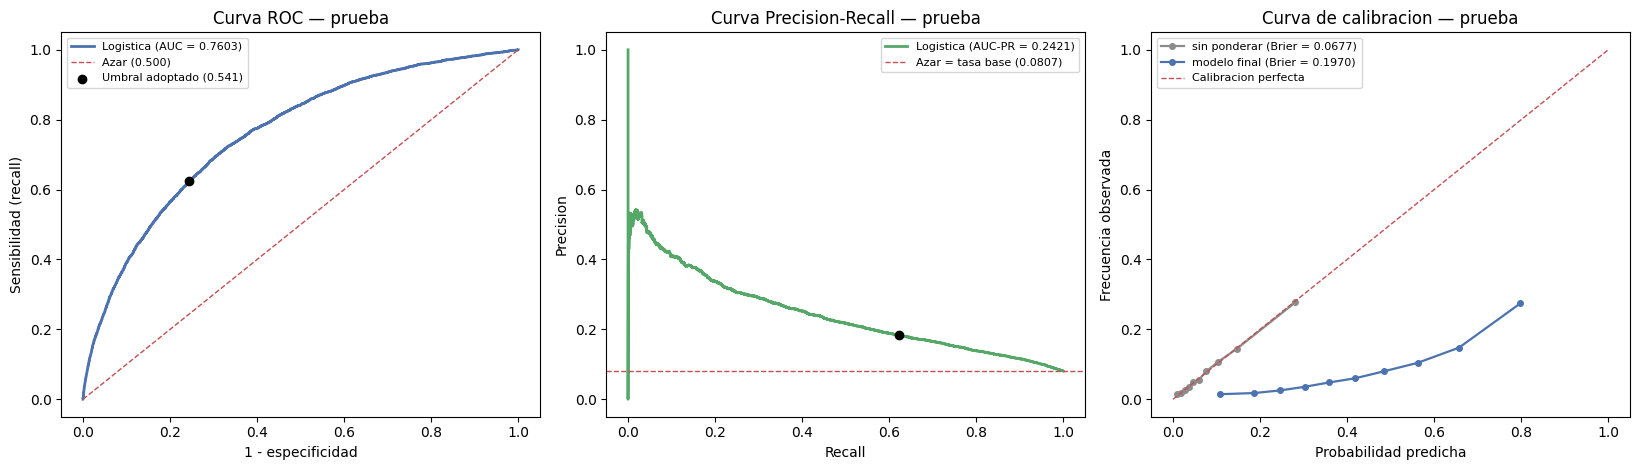

Brier sin ponderar : 0.0677
Brier modelo final : 0.1970
Un Brier peor en el modelo ponderado no indica peor ordenamiento: `class_weight`
descalibra las probabilidades a cambio de mover el umbral util hacia 0.5. Si el uso
exige probabilidades interpretables y no solo un ranking, hay que recalibrar.


In [72]:
fig, ax = plt.subplots(1, 3, figsize=(16.5, 4.8))

# --- ROC
fpr_te, tpr_te, _ = roc_curve(y_te, P_TEST)
ax[0].plot(fpr_te, tpr_te, color='#4c72b0', lw=2,
           label=f'Logistica (AUC = {m_te["auc_roc"]:.4f})')
ax[0].plot([0, 1], [0, 1], ls='--', lw=1, color='#c44e52', label='Azar (0.500)')
ax[0].scatter(1 - m_te['especificidad'], m_te['recall'], color='black', zorder=5,
              label=f'Umbral adoptado ({U_FINAL:.3f})')
ax[0].set(title='Curva ROC — prueba', xlabel='1 - especificidad',
          ylabel='Sensibilidad (recall)')
ax[0].legend(fontsize=8)

# --- Precision-Recall: la curva que el desbalance 11.4:1 vuelve obligatoria
pr_p, pr_r, _ = precision_recall_curve(y_te, P_TEST)
ax[1].plot(pr_r, pr_p, color='#55a868', lw=2,
           label=f'Logistica (AUC-PR = {m_te["auc_pr"]:.4f})')
ax[1].axhline(y_te.mean(), ls='--', lw=1, color='#c44e52',
              label=f'Azar = tasa base ({y_te.mean():.4f})')
ax[1].scatter(m_te['recall'], m_te['precision'], color='black', zorder=5)
ax[1].set(title='Curva Precision-Recall — prueba', xlabel='Recall', ylabel='Precision')
ax[1].legend(fontsize=8)

# --- calibracion: class_weight desplaza las probabilidades por construccion
p_sin = pipe.predict_proba(X_te)[:, 1]
for prob, nom, col in [(p_sin, 'sin ponderar', '#8c8c8c'), (P_TEST, 'modelo final', '#4c72b0')]:
    fr, mp = calibration_curve(y_te, prob, n_bins=10, strategy='quantile')
    ax[2].plot(mp, fr, 'o-', color=col, lw=1.6, ms=4,
               label=f'{nom} (Brier = {brier_score_loss(y_te, prob):.4f})')
ax[2].plot([0, 1], [0, 1], ls='--', lw=1, color='#c44e52', label='Calibracion perfecta')
ax[2].set(title='Curva de calibracion — prueba', xlabel='Probabilidad predicha',
          ylabel='Frecuencia observada')
ax[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig('diagnostico_logistica.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Brier sin ponderar : {brier_score_loss(y_te, p_sin):.4f}')
print(f'Brier modelo final : {brier_score_loss(y_te, P_TEST):.4f}')
print('Un Brier peor en el modelo ponderado no indica peor ordenamiento: '
      '`class_weight`\ndescalibra las probabilidades a cambio de mover el umbral '
      'util hacia 0.5. Si el uso\nexige probabilidades interpretables y no solo un '
      'ranking, hay que recalibrar.')

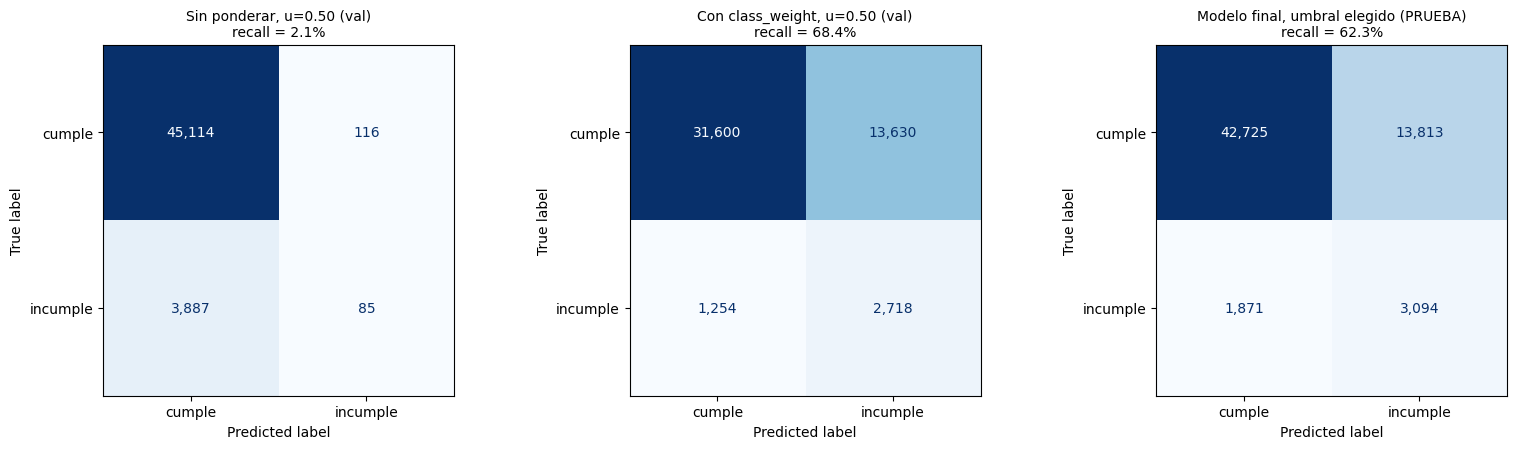

In [73]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.6))
for a, (mc, tit) in zip(ax, [
        (mc_0,   f'Sin ponderar, u=0.50 (val)\nrecall = {m_0["recall"]:.1%}'),
        (mc_bal, f'Con class_weight, u=0.50 (val)\nrecall = {m_bal["recall"]:.1%}'),
        (mc_te,  f'Modelo final, umbral elegido (PRUEBA)\nrecall = {m_te["recall"]:.1%}')]):
    ConfusionMatrixDisplay(mc, display_labels=['cumple', 'incumple']).plot(
        ax=a, cmap='Blues', colorbar=False, values_format=',')
    a.set_title(tit, fontsize=10)
plt.tight_layout()
plt.savefig('matriz_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

### 13.1. Los coeficientes, y por qué no todos se pueden leer

El modelo lineal permite leer la dirección y la magnitud del efecto de cada variable. Como el
escalado dejó todas en la misma unidad, los coeficientes son comparables entre sí: cada uno
expresa el cambio en el logaritmo de la razón de probabilidades ante un aumento de una
desviación estándar.

Con una condición que la versión anterior omitía. La Fase 3 documentó veintitrés pares con
$|r| > 0.95$ entre las cuarenta primeras variables nuevas, y el propio gráfico de coeficientes
mostraba el síntoma sin nombrarlo: `AMT_GOODS_PRICE` y `AMT_CREDIT`, o `BASEMENTAREA_AVG` y
`BASEMENTAREA_MEDI`, aparecían con magnitudes casi idénticas y signos opuestos. Eso no
significa que una suba el riesgo y la otra lo baje. Significa que **una sola señal se repartió
entre dos columnas casi iguales**, que el reparto individual es arbitrario, que cambia con la
semilla y con `C`, y que solo la suma del par es estable.

**Lo que esta corrida encuentra es distinto, y el motivo importa.** Aquellos pares ya no
llegan al modelo: el embudo de la Fase 3.5 poda la redundancia con $|r| > 0.95$ y descarta 60
variables por ese criterio, `BASEMENTAREA_MEDI` entre ellas. De las treinta de mayor
coeficiente sobreviven solo dos pares por encima de 0.90, y los dos con signos opuestos:

- `CODE_GENDER_M` y `CODE_GENDER_F`, con $|r| = 1.0000$ exacto. No es una redundancia de los
  datos sino **de la codificación**: `OneHotEncoder` sin `drop='first'` genera una columna por
  nivel, y sobre una variable binaria las dos son complementarias por construcción. El modelo
  reparte un único efecto entre ellas —+0.0948 y −0.0929— y lo interpretable es la diferencia,
  no cada coeficiente por separado. Es además un argumento para revisar la codificación, no
  solo para marcar el par.
- `BURO_DAYS_CREDIT_SUM` y `BURO_DAYS_ENDDATE_FACT_SUM`, con $|r| = 0.9452$: quedan por debajo
  del umbral de poda de la Fase 3.5 y por eso llegan juntas. Esta sí es la colinealidad
  genuina que el párrafo anterior describe.

La celda mide la colinealidad sobre la matriz ya transformada —la que el modelo realmente
vio— antes de interpretar nada, lista los pares con $|r| > 0.90$ entre las treinta variables
de mayor coeficiente, señala cuáles de ellos tienen signos opuestos y los marca con un
asterisco en el gráfico. Los coeficientes marcados describen al modelo, no al fenómeno.

=== PARES COLINEALES ENTRE LAS 30 VARIABLES DE MAYOR COEFICIENTE ===
          Variable_A                 Variable_B     |r|  coef_A  coef_B  Signo_opuesto
       CODE_GENDER_M              CODE_GENDER_F +1.0000 +0.0948 -0.0929           True
BURO_DAYS_CREDIT_SUM BURO_DAYS_ENDDATE_FACT_SUM +0.9452 +0.2355 -0.1275           True

2 pares con |r| > 0.90, de los cuales 2 tienen signos opuestos.
En esos pares el coeficiente individual NO es el efecto de la variable: el modelo
reparte una sola senal entre dos columnas casi identicas y la suma es lo unico
interpretable. Se marcan en el grafico.


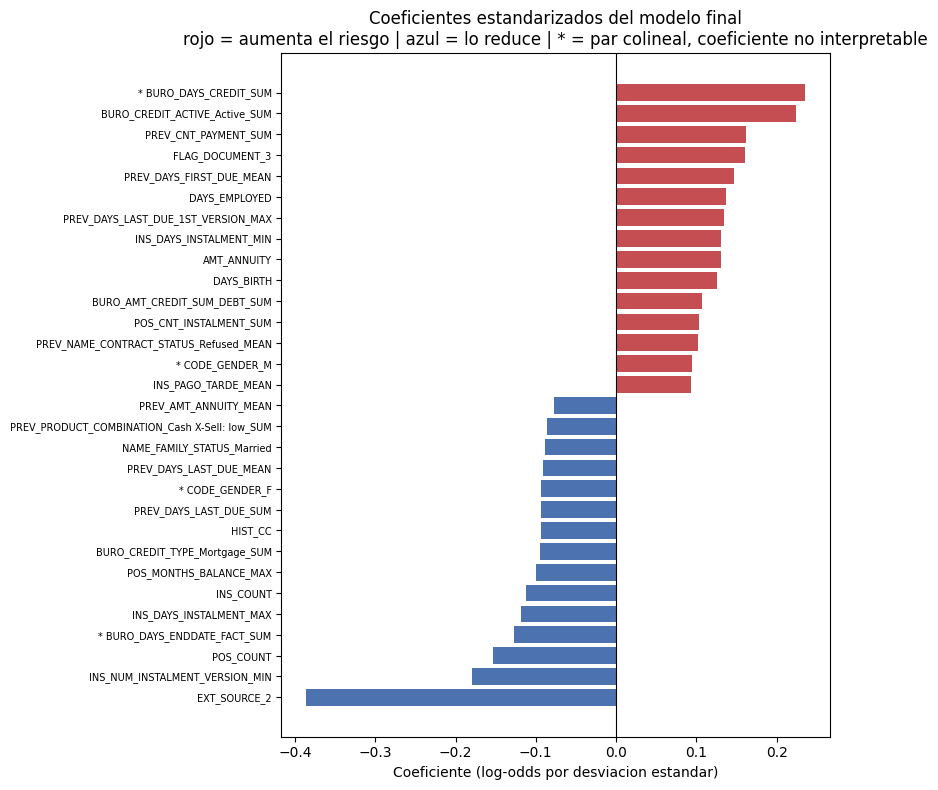


=== VARIABLES MAS INFLUYENTES ===
EXT_SOURCE_2                         -0.3857
BURO_DAYS_CREDIT_SUM                 +0.2355
BURO_CREDIT_ACTIVE_Active_SUM        +0.2243
INS_NUM_INSTALMENT_VERSION_MIN       -0.1793
PREV_CNT_PAYMENT_SUM                 +0.1625
FLAG_DOCUMENT_3                      +0.1611
POS_COUNT                            -0.1529
PREV_DAYS_FIRST_DUE_MEAN             +0.1471
DAYS_EMPLOYED                        +0.1368
PREV_DAYS_LAST_DUE_1ST_VERSION_MAX   +0.1339
INS_DAYS_INSTALMENT_MIN              +0.1308
AMT_ANNUITY                          +0.1307
BURO_DAYS_ENDDATE_FACT_SUM           -0.1275
DAYS_BIRTH                           +0.1261
INS_DAYS_INSTALMENT_MAX              -0.1183

Coeficientes exactamente nulos: 188 de 610


In [74]:
coef = pd.Series(MODELO_FINAL.named_steps['modelo'].coef_[0], index=NOMBRES)
top = coef.reindex(coef.abs().sort_values(ascending=False).index).head(30)

# --- diagnostico de colinealidad ANTES de interpretar nada
Z = pd.DataFrame(
    MODELO_FINAL.named_steps['preparacion'].transform(
        X_tr.sample(min(30_000, len(X_tr)), random_state=SEMILLA)),
    columns=NOMBRES)[top.index]
R = Z.corr().abs()
pares = [(a, b, R.loc[a, b], coef[a], coef[b])
         for i, a in enumerate(top.index) for b in top.index[i+1:]
         if R.loc[a, b] > 0.90]
del Z; gc.collect()

print('=== PARES COLINEALES ENTRE LAS 30 VARIABLES DE MAYOR COEFICIENTE ===')
if pares:
    COLINEALES = (pd.DataFrame(pares, columns=['Variable_A', 'Variable_B', '|r|',
                                               'coef_A', 'coef_B'])
                  .assign(Signo_opuesto=lambda d: np.sign(d['coef_A']) != np.sign(d['coef_B']))
                  .sort_values('|r|', ascending=False))
    print(COLINEALES.to_string(index=False, float_format=lambda v: f'{v:+.4f}'))
    n_op = int(COLINEALES['Signo_opuesto'].sum())
    print(f'\n{len(COLINEALES)} pares con |r| > 0.90, de los cuales {n_op} tienen '
          'signos opuestos.')
    print('En esos pares el coeficiente individual NO es el efecto de la variable: '
          'el modelo\nreparte una sola senal entre dos columnas casi identicas y la '
          'suma es lo unico\ninterpretable. Se marcan en el grafico.')
else:
    COLINEALES = pd.DataFrame()
    print('Ningun par supera |r| = 0.90 entre las 30 primeras.')

marcadas = set(COLINEALES[['Variable_A', 'Variable_B']].to_numpy().ravel()) if len(COLINEALES) else set()

t = pd.concat([coef.nsmallest(15), coef.nlargest(15)]).sort_values()
fig, ax = plt.subplots(figsize=(8.5, 8))
ax.barh(range(len(t)), t.values,
        color=np.where(t.values > 0, '#c44e52', '#4c72b0'))
ax.set_yticks(range(len(t)))
ax.set_yticklabels([f'{"* " if n in marcadas else ""}{n}' for n in t.index], fontsize=7)
ax.axvline(0, color='black', lw=.8)
ax.set(title='Coeficientes estandarizados del modelo final\n'
             'rojo = aumenta el riesgo | azul = lo reduce | * = par colineal, '
             'coeficiente no interpretable',
       xlabel='Coeficiente (log-odds por desviacion estandar)')
plt.tight_layout()
plt.savefig('coeficientes_logistica.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n=== VARIABLES MAS INFLUYENTES ===')
print(top.head(15).to_string(float_format=lambda v: f'{v:+.4f}'))
print(f'\nCoeficientes exactamente nulos: {int((coef == 0).sum())} de {len(coef)}')
RESULTADOS['colineales'] = COLINEALES

## 14. Persistencia del modelo

El ajuste no puede vivir solo en la memoria del kernel. Se guarda el pipeline completo
—preparación incluida, de modo que el objeto recargado acepta el `DataFrame` crudo sin
repetir ningún paso a mano— junto con el umbral adoptado y su criterio, las columnas
esperadas, la semilla, la versión de `scikit-learn` y las métricas de prueba.

La celda recarga el archivo y comprueba que reproduce las predicciones evaluadas. Un
artefacto que no se verifica no es un artefacto.

In [75]:
ARTEFACTO = {
    'pipeline'    : MODELO_FINAL,
    'umbral'      : U_FINAL,
    'criterio'    : CRITERIO_UMBRAL,
    'columnas'    : list(X_tr.columns),
    'cuantitativas': CUANTITATIVAS,
    'cualitativas': CUALITATIVAS,
    'semilla'     : SEMILLA,
    'metricas_prueba': {k: float(v) for k, v in m_te.items()},
    'sklearn'     : __import__('sklearn').__version__,
    'fecha'       : time.strftime('%Y-%m-%d %H:%M'),
}
joblib.dump(ARTEFACTO, 'modelo_logistico.joblib')
print('Guardado modelo_logistico.joblib')

# comprobacion de que el artefacto reproduce lo evaluado
rec = joblib.load('modelo_logistico.joblib')
p_rec = rec['pipeline'].predict_proba(X_te.head(1000))[:, 1]
print(f'Reproduce las predicciones: '
      f'{np.allclose(p_rec, P_TEST[:1000])}   umbral guardado {rec["umbral"]:.4f}')

Guardado modelo_logistico.joblib
Reproduce las predicciones: True   umbral guardado 0.5409


## 15. Resumen de la fase

In [76]:
print('=== RESUMEN DE LA FASE 4 ===\n')
print('1. Estabilidad (validacion cruzada, 5 pliegues sobre entrenamiento)')
print(RESULTADOS['cv'][['Configuracion', 'AUC_ROC_cv', 'sd_ROC', 'AUC_PR_cv', 'Brecha']]
      .to_string(index=False, float_format=lambda v: f'{v:.4f}'))

print('\n2. Regularizacion elegida por rejilla')
print(f'   {gs.best_params_}   AUC-ROC cv {gs.best_score_:.4f}')

print('\n3. Umbral')
print(f'   {U_FINAL:.4f} ({CRITERIO_UMBRAL}, tasa base {y_va.mean():.4f})')

print('\n4. Evaluacion final, conjunto de prueba')
m = RESULTADOS['prueba']
print(f'   AUC-ROC {m["auc_roc"]:.4f} | AUC-PR {m["auc_pr"]:.4f} '
      f'(azar {y_te.mean():.4f})')
print(f'   Precision {m["precision"]:.2%} | Recall {m["recall"]:.2%} | '
      f'F1 {m["f1"]:.2%} | Exactitud {m["exactitud"]:.2%}')
print(f'   Contra la linea base ingenua: AUC-ROC 0.5000, recall 0.00%, '
      f'exactitud {1-y_te.mean():.2%}')

_c = RESULTADOS['coste_prueba']
print(f'   Coste en prueba {_c["modelo"]:,} unidades frente a '
      f'{min(_c["aprobar_todos"], _c["rechazar_todos"]):,} de la mejor politica '
      'sin modelo')

print('\n5. Advertencias vigentes')
print(f'   Pares colineales entre los 30 mayores coeficientes: {len(RESULTADOS["colineales"])}')
print(f'   Brier del modelo final: {brier_score_loss(y_te, P_TEST):.4f} '
      '(ponderar descalibra)')
_no_conv = [k for k, v in CONVERGENCIA.items() if not v['convergio']]
print(f'   Ajustes que agotaron el tope de iteraciones: '
      f'{len(_no_conv)} de {len(CONVERGENCIA)}'
      + (f"  -> {', '.join(_no_conv)}" if _no_conv else ''))

=== RESUMEN DE LA FASE 4 ===

1. Estabilidad (validacion cruzada, 5 pliegues sobre entrenamiento)
              Configuracion  AUC_ROC_cv  sd_ROC  AUC_PR_cv  Brecha
logistica C=1, sin ponderar      0.7564  0.0036     0.2359  0.0108
logistica C=1, class_weight      0.7561  0.0039     0.2323  0.0126
      dummy (most_frequent)      0.5000  0.0000     0.0807  0.0000

2. Regularizacion elegida por rejilla
   {'modelo__C': 0.01, 'modelo__max_iter': 5000, 'modelo__penalty': 'l1', 'modelo__solver': 'saga'}   AUC-ROC cv 0.7576

3. Umbral
   0.5409 (coste FN=10:1, elegido sobre validacion, tasa base 0.0807)

4. Evaluacion final, conjunto de prueba
   AUC-ROC 0.7603 | AUC-PR 0.2421 (azar 0.0807)
   Precision 18.30% | Recall 62.32% | F1 28.29% | Exactitud 74.50%
   Contra la linea base ingenua: AUC-ROC 0.5000, recall 0.00%, exactitud 91.93%
   Coste en prueba 32,523 unidades frente a 49,650 de la mejor politica sin modelo

5. Advertencias vigentes
   Pares colineales entre los 30 mayores coeficie

## 16. Conclusiones

**El problema es de clasificación y la regresión logística es el modelo lineal que le
corresponde.** `TARGET` es binaria, la clase positiva representa 8.07% de la cartera y la
métrica es AUC-ROC, acompañada aquí de AUC-PR. La logística conserva la forma lineal de la
regresión —y con ella la interpretabilidad de los coeficientes y la regularización vista en
el material— pero modela el logaritmo de la razón de probabilidades en lugar de la media de
una variable continua.

**La exactitud no puede ser la métrica de este problema, y el `DummyClassifier` lo demuestra
antes que el modelo.** Un clasificador que responde siempre *cumple* acierta el 91.93% de las
veces sin detectar un solo incumplimiento: AUC-ROC 0.500, recall 0%. El primer ajuste
reprodujo casi exactamente ese comportamiento. La matriz de confusión convierte en evidencia
numérica lo que la Fase 1 había anticipado en prosa.

**El ordenamiento y el umbral son dos cosas distintas.** El AUC apenas cambió entre el modelo
ponderado y el que no lo estaba, mientras que sus matrices de confusión son opuestas —y la
validación cruzada de la sección 9 confirma que esa igualdad no es un accidente de la
partición, porque la diferencia queda por debajo del ruido entre pliegues. El modelo ordenaba
igual de bien en ambos casos; lo que cambiaba era dónde caía el corte. La consecuencia
práctica es que el umbral no es una propiedad del modelo sino una decisión de política de
riesgo, y el que se adopta aquí es el que minimiza el coste declarado —un incumplimiento no
detectado vale diez rechazos de buen cliente—, elegido sobre validación y vuelto a medir
sobre prueba contra aprobar a todos y rechazar a todos.

**Ninguna cifra de una sola partición es evidencia.** Es la corrección metodológica más
importante de esta versión. Cada configuración se evalúa sobre cinco pliegues estratificados
y se reporta con su desviación; la elección de `C` y de la penalización sale de una rejilla
recorrida por validación cruzada —$L^2$ con `lbfgs` y $L^1$ con `saga`, las dos familias en
la misma comparación—, no del valor por defecto; el umbral se elige sobre validación y se
reporta sobre prueba. La tabla de la sección 12 muestra cuánto optimismo introducía no
separar esos papeles.

**El cuaderno se lee en el orden en que está escrito.** Es la corrección que hace creíbles a
todas las demás. En la versión anterior la celda de validación cruzada convertía las tres
particiones a `float32`, y como es posterior a las secciones 7 y 8.1, las cifras de esas dos
secciones valían 0.743513 o 0.743597 de AUC según se hubiera ejecutado o no la sección 9. Un
cuaderno cuyo resultado depende del recorrido de las celdas no permite atribuir ninguna cifra
al código tal como está escrito. El tipo se fija ahora una sola vez, en la celda de
partición, antes del primer ajuste, y el capítulo se entrega ejecutado de principio a fin en
un kernel limpio.

**Los coeficientes describen al modelo antes que al fenómeno.** Bajo colinealidad severa
—documentada en la Fase 3 y medida de nuevo aquí sobre la matriz transformada— el efecto se
reparte de forma arbitraria entre columnas casi idénticas, y solo la suma del par es estable.
Los pares afectados quedan marcados en el gráfico en lugar de leerse como si fueran efectos
independientes.

**El desempeño obtenido es coherente con lo que el EDA hacía prever y marca el techo del
modelo lineal.** La Fase 1 estableció que ninguna variable supera $|r| = 0.16$ y que solo
catorce de 255 exceden 0.05: no hay predictor dominante y la capacidad discriminante se
construye por acumulación de señales débiles. Un modelo que combina linealmente esas señales
aprovecha lo que puede de ellas, pero tres hallazgos del propio EDA quedan fuera de su
alcance por construcción:

1. **Las interacciones no se descubren solas.** El producto `EXT_SOURCE_2 × EXT_SOURCE_3`
   alcanza −0.194 frente a −0.160 de la mejor variable individual. Ese término tuvo que
   construirse a mano con `PolynomialFeatures`; la logística no lo genera por sí misma.
2. **Las relaciones no monótonas no son representables.** La mora por número de fuentes de
   historial alcanza su máximo de 10.34% en los clientes con tres fuentes y desciende a ambos
   lados. Un término lineal es incapaz de reproducir esa forma.
3. **La colinealidad dificulta la lectura de los coeficientes**, según acaba de medirse.

**Lo que queda pendiente y no se hizo aquí.** Dos cosas, ambas señaladas en su sección —una
menos que en la versión anterior, porque la rama $L^1$ ya no se da por descartada "por coste"
sino que se ejecuta y compite en la rejilla de la sección 10—: las probabilidades del modelo
ponderado están descalibradas y su recalibración con `CalibratedClassifierCV` no se aborda; y
la construcción de variables de la Fase 3 se hizo mirando el objetivo sobre todas las filas,
de modo que la evaluación sigue siendo una estimación optimista frente a una validación
cruzada anidada de principio a fin.

**Hacia dónde sigue el trabajo.** Los tres límites del modelo lineal no son fallas del ajuste
sino propiedades de la frontera de decisión, y señalan en la misma dirección: modelos capaces
de capturar interacciones y relaciones no monótonas sin que se las especifique de antemano,
como los basados en árboles. La logística queda como línea base contra la cual medir esa
mejora, y cualquier ganancia posterior deberá justificarse frente a las cifras de la sección
12 —las de prueba, no las de validación— y sobre el mismo esquema de validación cruzada.

## 17. Traspaso al Entregable 3

Se guardan en `datos/` las tres particiones de la sección 4 (entrenamiento, validación y prueba), con
las 483 columnas que entregó el embudo de la Fase 3.5, el objetivo `TARGET` y el índice original de cada
fila (posición en `application_train.csv`, archivo ordenado por `SK_ID_CURR`).

En el Entregable 3:

* **desarrollo** = entrenamiento + validación (246,008 filas): sobre él corre la validación cruzada
  anidada de los 140 modelos;
* **prueba** = la misma prueba de esta línea base (61,503 filas): solo se usa al final, de modo que los
  nuevos modelos se comparan con la logística en igualdad de condiciones.

La celda verifica que el traspaso es fiel: al releerlo, el pipeline logístico guardado reproduce sus
predicciones de prueba.

In [77]:
import sys
from pathlib import Path
_RAIZ = next(p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "_config.yml").is_file() and (p / "src").is_dir())
if str(_RAIZ) not in sys.path:
    sys.path.insert(0, str(_RAIZ))
from src import datos as _datos

_meta = _datos.guardar_traspaso(X_tr, y_tr, X_va, y_va, X_te, y_te,
                                CUANTITATIVAS, CUALITATIVAS, semilla=SEMILLA)
print(f"Traspaso guardado en {_datos.config.DIR_DATOS.relative_to(_RAIZ)}")
print(f"  desarrollo: {_meta['filas_desarrollo']:,} filas | prueba: {_meta['filas_prueba']:,} filas | "
      f"columnas: {_meta['columnas']} ({len(_meta['cuantitativas'])} cuantitativas + "
      f"{len(_meta['cualitativas'])} cualitativas)")
print(f"  mora desarrollo {100 * _meta['tasa_mora_desarrollo']:.2f}% | "
      f"mora prueba {100 * _meta['tasa_mora_prueba']:.2f}%")

# --- verificacion (solo si la seccion 12 de la logistica ya se ejecuto en este kernel)
_conj = _datos.cargar_traspaso()
print(f"  filas de prueba identicas: {list(_conj.X_te.index) == list(X_te.index)}")
if "P_TEST" in globals() and os.path.isfile("modelo_logistico.joblib"):
    _art = joblib.load("modelo_logistico.joblib")
    _p = _art["pipeline"].predict_proba(_conj.X_te[_art["columnas"]])[:, 1]
    print(f"  el pipeline logistico reproduce P_TEST: {np.allclose(_p, P_TEST, atol=1e-6)} "
          f"(max |dif| = {np.abs(_p - P_TEST).max():.2e})")
    del _p
else:
    print("  (la logistica no se ejecuto en esta sesion: se omite la verificacion del pipeline)")
del _conj

Traspaso guardado en datos
  desarrollo: 246,008 filas | prueba: 61,503 filas | columnas: 483 (467 cuantitativas + 16 cualitativas)
  mora desarrollo 8.07% | mora prueba 8.07%


  filas de prueba identicas: True


  el pipeline logistico reproduce P_TEST: True (max |dif| = 0.00e+00)
